# 추출형과 생성형 문서 요약 구현을 통한 모델 별 구조 이해

과제식별 : [스프린트 미션12](https://www.codeit.kr/topics/studyGroupStep6985c080aa647f3831b0de79/lessons/13987)  
변경사항 : [미션 수정 내용](https://aiota.notion.site/BERT-GPT-343dc3286bf18091abb7e3fd4d8804a8)  
작성 : 2026.05.29 신호정

## A. 프로젝트의 목적

한국어 문서를 요약하는 추출형과 생성형 모델을 각각 개발합니다.  
사전 제공된 뉴스, 법률, 사설 문서를 기반으로 학습된 BERT(추출형)과 GPT(생성형) 모델을 사용하며  
평가 지표를 적용하여 정량화된 문서 요약 품질을 측정합니다.

### a. 프로젝트 수행방향

codeit에서 제공한 `{train|valid}_original_{editornal|law|news}` 을 원본 데이터로 사용합니다.  
`valid_original_{editornal|law|news}`의 10%를 검증 셋으로 활용합니다.  
위 데이터를 전처리 후 토큰화하고 특수 토큰을 모델 별 정의대로 추가하여 포함시킵니다.  
토큰화된 데이터를 바탕으로 어휘 사전을 각각 구축하고, 세션 중단 이후에도 재사용할 수 있도록 저장합니다.  
BERT와 GPT용 훈련 데이터를 각각 생성하고, 어휘 사전과 같이 재사용할 수 있도록 저장합니다.  
데이터 셋과 로더를 BERT와 GPT의 모델 특성에 맞게 각자 구현합니다.  
BERT와 GPT 모델을 구현하고 소형 모델에 적절한 하이퍼파라미터를 설정합니다.  
이후 각각의 모델을 위에서 구현한 데이터 로더에 하이퍼파라미터를 적용하여 학습시킵니다.  
문서 요약 산출 매커니즘은 BERT의 경우는 사전학습 인코더의 문장 임베딩(평균풀링/CLS) 기반  
중심성(TextRank) 상위 k 문장 추출을 사용하고  
GPT의 경우에는 문서, 요약 쌍을 사용한 파인튜닝을 적용하여 요약 결과를 도출합니다.  
BERT 모델의 자체 평가 지표는 NSP F1과 MLM CE 로 측정하고  
GPT 모델의 경우에는 PPL(Perplexity)를 통해 측정합니다.  
또한 두 모델의 문서 요약 성능에 대해서는 ROUGE(형태소 단위, Mecab)과  
Lead-3 베이스라인 대비 + 정성 샘플을 사용하여 측정 후 비교합니다.

> - TextRank top K : 문서 내의 모든 문장들을 수학적 벡터로 바꾼 뒤,  
> 문맥상 다른 문장들과 가장 의미가 많이 겹치는(중심이 되는) 대표 문장 k 개를 골라낸다는 의미  
> - NSP F1 : 문장 간의 거시적 논리 구조와 연결성을 이해하는 능력을 측정
> - MLM Cross-Entropy Loss : 단어와 단어 사이의 미시적 구조 및 문맥적 의미를 이해하는 능력
> - Lead-3 baseline : 원문 문서의 맨 앞 3문장을 그대로 가져와 요약문으로 사용하는 방법

### b. 프로젝트 수행계획
1. BERT와 GPT의 문서 요약 작동 방식의 차이에 대해 조사하고 설명합니다.

2. 학습에 사용될 데이터에 대해 EDA와 전처리를 수행합니다.
    - 데이터 크기, 데이터 형태, 길이 분포, 어휘 분포, 결측/중복 비율
    - 위의 분석 결과를 히스토그램과 분포도를 통해 나타냅니다.
    - NFKC 정규화, 중복 제거, 길이 필터링(BERT의 토큰 한도를 고려해야함), 제어문자 제거

3. 전처리된 데이터를 모델 별로 토큰화합니다.
    - BERT 특수토큰 적용 : [CLS], [SEP], [MASK], [PAD], [UNK]
    - GPT 특수토큰 적용 : `<bos>`, `<sep>`, `<eos>`, `<pad>`
    - 산출된 코퍼스로 BPE 토크나이저 학습
    - 특수토큰까지 포함된 형태의 vacab을 모델 별 파일로 저장합니다.

4. 학습 데이터를 생성합니다.
    - 공통
        - 3항에서 선언된 특수 토큰을 포함시킵니다.
        - test set은 valid set의 10%를 분할하여 설정합니다.
        - 각 모델 별 train/valid/test set 을 파일로 저장합니다.
        - 랜덤 시드는 42로 설정합니다.
    - BERT
        - NSP 쌍 (50% IsNext / 50% 무작위 NotNext) 구성
        - MLM 은 동적 마스킹 (학습 시 15% 확률, 80/10/10 구성)
    - GPT
        - 문서를 `<eos>`로 이어 붙이되, seq_len 분량으로 문서 패킹합니다.

5. 모델 별 데이터 셋과 데이터 로더를 구현합니다.
    - num_workers, pin_memory, persistent_workers 설정
    - 배치 단위의 데이터 스트리밍 방식으로 구현

6. BERT, GPT 모델을 구현합니다.
    - 공통
        - batch_size : 128
        - batch_size 128에서 OOM 발생 시 batch_size 64, Gradient Accumulation 2 설정
        - 모델 파라미터 규모 로그 출력
    - BERT
        - 토큰 + 세그먼트 + 위치 임베딩
        - Transformer 인코더
        - MLM 헤드
        - NSP 헤드
        - 양자화 필요성을 검토합니다.
        - Layer 4, hidden 256
    - GPT
        - 토큰 + 위치 임베딩
        - Casual Mask
        - Transformer 디코더
        - LM 헤드
        - label 1 칸 시프트

7. 파이프라인 작동에 필요한 환경 변수를 설정합니다.
    - Colab L4 GPU 런타임에 최적화된 옵션을 설정합니다.
        - AMP + BF16
        - torch.compile
        - Random Seed : 42 고정

8. BERT, GPT 의 학습 파이프라인을 구현하고, 사전 학습을 진행합니다.
    - 공통
        - 기본 5 epoch 실행
        - 2000 step 마다 평가와 pt 저장 수행
        - 전체 스텝의 5%를 웜업 스텝을 사용
    - BERT
        - MLM + NSP 구조. NSP는 F1, MLM은 정확도 로 지표 측정
    - GPT
        - next-token CE 구조. held-out PPL 및 50 토큰 이어쓰기 정성 샘플로 측정

9. 문서 요약 산출법을 적용합니다.
    - BERT(비지도)
        - 사전학습 인코더로 문장 임베딩 → TextRank 중심성 상위 k 문장 추출
    - GPT
        - `<bos>`문서`<sep>`요약`<eos>` 포멧의 학습 데이터 생성
        - 위 학습 데이터로 파인튜닝 진행
        - 손실 측정은 요약 구간에서만 진행
        - 문서가 길 경우, 원문의 뒷부분을 잘라내고 요약문은 온전히 보존합니다.

10. 추론(생성) 함수를 작성하고 적용합니다.
    - KV 캐시 적용
    - Beam Search 적용
    - 모델 별 요약문을 산출합니다.

11. 요약문을 바탕으로 평가 지표를 산출하고 비교 분석을 진행합니다.
    - ROUGE(형태소 단위, Mecab) 계산 : BERT 추출 요약, GPT 생성 요약, 레퍼런스를 대조합니다.
    - Lead-3 베이스라인 계산 : 두 모델 점수를 맥락으로 해석합니다.
    - 정성 샘플을 나란히 출력하여 비교합니다 : test set의 원문, 정답, BERT, GPT

### c. 추가 고려 사항

1. 학습이 작동하는 환경은 Colab L4 입니다.
    - 따라서 런타임이 중단될 경우에 대비한 백업 처리가 항상 이루어져야 합니다.

2. Colab L4 런타임 상에서 CheckPoint가 저장되는 곳은 Google Drive 입니다.
    - 학습 파이프라인 가동 전에 파일 저장 경로가 Google Drive를 바라보고 있는지 명시적으로 확인합니다.
    - pt 파일의 저장을 best only로 지정하고, 이전 파일은 즉시 삭제하거나 휴지통을 주기적으로 비워 대응합니다.

3. 데이터의 규모는 {train|valid}_ original _{editornal|law|news} 테이블 모두 합쳐 1.6gb 정도 입니다.

4. ipynb의 작성과 작동을 검증하는 환경은 WSL2, RTX 5050 Laptop 인 로컬 환경입니다.  

5. 로컬에서 검증이 다된 ipynb 파일을 colab에서 학습시킵니다.  
    - 따라서 is_colab flag를 전역적으로 두어, 로컬 or colab에 맞는 작동을 하도록 셀 별 분기를 설정해야 합니다.

## B. BERT와 GPT 모델의 작동 방식 차이 고찰

### a. 추출형 요약 (BERT 기반)

문서 내 문장을 그대로 선택하는 방식입니다.  
새로운 문장을 생성하지 않습니다.  

BERT는 양방향(Bidirectional) Transformer Encoder를 사용합니다.    
[CLS]→문장A→[SEP]→문장B→[SEP] 형식으로 두 문장 쌍을 입력받아  
**MLM(Masked Language Modeling)** 과 **NSP(Next Sentence Prediction)** 로 사전학습합니다.

본 과제에서의 활용:
- 사전학습된 인코더로 각 문장의 임베딩 벡터를 추출 (평균풀링)
- 문장 간 코사인 유사도로 그래프를 구성하고 **TextRank** 알고리즘으로 중심성 상위 3문장 추출
- 지도 학습 없이 동작하는 **비지도(Unsupervised)** 방식

| 항목 | 내용 |
|------|------|
| 입출력 | 문서 전체 → 원문 문장 인덱스 3개 |
| 핵심 능력 | 문장 간 의미 유사도 파악 |
| 한계 | 원문에 없는 표현 생성 불가, 문서가 길면 대표성 ↓ |

### b. 생성형 요약 (GPT 기반)

원문을 읽고 새로운 요약문을 생성하는 방식입니다.  
원문에 없는 표현도 만들 수 있습니다.  

GPT는 단방향(Causal/Autoregressive) Transformer Decoder를 사용합니다.  
과거 토큰만 참조하는 Causal Mask 덕분에 next-token prediction으로 언어 모델을 사전학습합니다.

본 과제에서의 활용:
- **사전학습:** `문서1<eos>문서2<eos>...` 를 seq_len=512 단위로 패킹, next-token CE
- **파인튜닝:** `<bos>문서<sep>요약<eos>` 형식으로 학습, **요약 구간 손실만** 역전파
- **추론:** `<bos>문서<sep>` 까지 프롬프트로 제공 후 `<eos>` 생성 시 종료

| 항목 | 내용 |
|------|------|
| 입출력 | 문서 → 새로 생성된 요약문 |
| 핵심 능력 | 문맥 이해 + 자연스러운 문장 생성 |
| 한계 | 할루시네이션(Hallucination) 위험, 긴 문서에서 원문 손실 |

### c. 두 방식 비교 요약

| 비교 항목 | BERT (추출형) | GPT (생성형) |
|-----------|-------------|------------|
| 학습 패러다임 | 양방향 인코더 + MLM/NSP | 단방향 디코더 + LM |
| 요약 방식 | 비지도 (TextRank) | 지도 (파인튜닝) |
| 출력 | 원문 문장 선택 | 새 문장 생성 |
| 평가 지표 | NSP F1, MLM 정확도 | PPL |
| 최종 ROUGE | 원문 문장 그대로이므로 유리 | 표현 다양성 유리, 충실도 위험 |

## C. 데이터 EDA 및 전처리

### a. 전처리 파이프라인

전처리는 5단계로 구성합니다.

| 단계 | 내용 |
|------|------|
| 1. 데이터 로드 | 6개 JSON 파일(train/valid × news/law/editorial) 로드, split·domain 태그 부여 |
| 2. 텍스트 정규화 | NFKC 유니코드 정규화 |
| 3. 제어문자 제거 | `\x00-\x08`, `\x0b-\x1f` 등 비가시 문자 제거, 연속 공백 정리 |
| 4. 중복 제거 | 문서 내 전체 문장 결합 문자열 기준 해시 비교 |
| 5. 길이 필터링 | BERT 토큰 한도(512) 고려, 문장 수 > 30 문서 제외 |

### b. EDA 시각화 항목

| 항목 | 목적 |
|------|------|
| 도메인별 문서 수 | news / law / editorial 분포 비율 확인 |
| 문장 수 분포 | 길이 필터링 임계값(30문장) 타당성 검토 |
| 글자 수 분포 | 문서 총 글자 수 히스토그램 |
| Extractive 위치 분포 | 정답 추출 문장 인덱스 상대 위치 → 앞쪽 집중 여부 확인 |

### c. 프로젝트 작동 환경 설정

In [1]:
import os, json, re, unicodedata, pickle, hashlib
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm.auto import tqdm

# Environment flag — referenced throughout the notebook
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

# Mount Google Drive early so all downstream file I/O works
if is_colab:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

DATA_ROOT = Path('/content/drive/MyDrive/mission12/DataTable') if is_colab else Path('./DataTable')
SAVE_ROOT = Path('/content/drive/MyDrive/mission12') if is_colab else Path('.')

# Korean font for matplotlib — path follows SAVE_ROOT so it works in both envs
_font_path = str(SAVE_ROOT / 'NanumGothic.ttf')
if os.path.exists(_font_path):
    fm.fontManager.addfont(_font_path)
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

print(f'is_colab  : {is_colab}')
print(f'DATA_ROOT : {DATA_ROOT}')
print(f'SAVE_ROOT : {SAVE_ROOT}')
print(f'font_path : {_font_path}  (exists={os.path.exists(_font_path)})')

SEED = 42


Mounted at /content/drive
is_colab  : True
DATA_ROOT : /content/drive/MyDrive/mission12/DataTable
SAVE_ROOT : /content/drive/MyDrive/mission12
font_path : /content/drive/MyDrive/mission12/NanumGothic.ttf  (exists=True)


### d. 데이터 로드 확인

In [ ]:
def load_data() -> list:
    """Load 6 JSON files; attach split/domain tags and flatten sentences."""
    files = [
        ('train', 'news',      'train_original_news.json'),
        ('train', 'law',       'train_original_law.json'),
        ('train', 'editorial', 'train_original_editorial.json'),
        ('valid', 'news',      'valid_original_news.json'),
        ('valid', 'law',       'valid_original_law.json'),
        ('valid', 'editorial', 'valid_original_editorial.json'),
    ]
    docs = []
    for split, domain, fname in files:
        path = DATA_ROOT / fname
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        for raw in tqdm(data['documents'], desc=f'{split}/{domain}', leave=False):
            # text field is list-of-lists: paragraph → sentence dicts
            sentences = [s for para in raw['text'] for s in para]
            docs.append({
                'split':       split,
                'domain':      domain,
                'sentences':   sentences,   # [{index, sentence, highlight_indices}, ...]
                'extractive':  raw['extractive'],
                'abstractive': raw['abstractive'],
            })
    return docs

raw_docs = load_data()
print(f'총 문서 수 (로드): {len(raw_docs):,}')

총 문서 수 (로드): 365,206


### e. 데이터 형태(스키마) 확인

In [ ]:
# Raw JSON schema before sentence flattening
with open(DATA_ROOT / 'valid_original_news.json', 'r', encoding='utf-8') as _f:
    _raw = json.load(_f)['documents'][0]

_field_desc = {
    'id':           '문서 고유 식별자 (str)',
    'category':     '카테고리 레이블 (str)',
    'media_type':   '미디어 종류 (str, news/editorial만 존재)',
    'media_sub_type': '미디어 세부 종류 (str)',
    'media_name':   '미디어 이름 (str)',
    'size':         '문서 크기 구분 (str)',
    'char_count':   '글자 수 (int)',
    'publish_date': '발행일 (str)',
    'title':        '제목 (str)',
    'text':         'list[list[dict]] ─ 단락(para) → 문장(sentence)',
    'annotator_id': '어노테이터 ID',
    'document_quality_scores': '품질 점수',
    'extractive':   'list[int|None] ─ 추출 요약 정답 문장 인덱스 3개',
    'abstractive':  'list[str] ─ 생성 요약 정답 문자열',
}

print('=' * 60)
print('문서 스키마 (valid_original_news.json 샘플)')
print('=' * 60)
for k, v in _raw.items():
    desc = _field_desc.get(k, '')
    if isinstance(v, list):
        if v and isinstance(v[0], list):
            detail = f'단락 {len(v)}개 / 총 {sum(len(p) for p in v)}문장'
        elif v and isinstance(v[0], dict):
            detail = f'dict keys={list(v[0].keys())}'
        else:
            detail = str(v)
    else:
        detail = str(v)[:45]
    print(f'  {k:28s}  {detail}')
    if desc:
        print(f'  {"":28s}  └ {desc}')

print()
print('text 필드 중첩 구조:')
print('  text = [ 단락0, 단락1, ... ]')
print('  단락  = [ {index, sentence, highlight_indices}, ... ]')
print()
_flat = [s for para in _raw['text'] for s in para]
print(f'문장 dict 예시 (평탄화 후 sentences[0]):')
for k, v in _flat[0].items():
    print(f'  {k:22s}: {str(v)[:70]}')
print()
print(f'extractive  : {_raw["extractive"]}')
print(f'abstractive : {_raw["abstractive"][0][:70]}...')
print('=' * 60)

문서 스키마 (valid_original_news.json 샘플)
  id                            340626877
                                └ 문서 고유 식별자 (str)
  category                      정치
                                └ 카테고리 레이블 (str)
  media_type                    online
                                └ 미디어 종류 (str, news/editorial만 존재)
  media_sub_type                경제지
                                └ 미디어 세부 종류 (str)
  media_name                    한국경제
                                └ 미디어 이름 (str)
  size                          medium
                                └ 문서 크기 구분 (str)
  char_count                    1111
                                └ 글자 수 (int)
  publish_date                  2019-04-08 17:43:00
                                └ 발행일 (str)
  title                         文대통령 "5G는 4차산업혁명 시대의 고속도로"
                                └ 제목 (str)
  text                          단락 5개 / 총 13문장
                                └ list[list[dict]] ─ 단락(para) → 문장(sentence)
  annotator_id     

### f. 데이터 전처리

In [ ]:
def clean_text(text: str) -> str:
    """NFKC normalisation, control-char removal, whitespace collapse."""
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

def preprocess_docs(docs: list) -> list:
    """clean_text → deduplicate by MD5 → filter 1 ≤ sentence_count ≤ 30."""
    # Step 1: clean each sentence
    cleaned = []
    for doc in tqdm(docs, desc='Cleaning', leave=False):
        sents = []
        for s in doc['sentences']:
            t = clean_text(s['sentence'])
            if t:
                sents.append({**s, 'sentence': t})
        cleaned.append({**doc, 'sentences': sents})

    # Step 2: deduplicate on full-document text hash
    seen = set()
    deduped = []
    for doc in tqdm(cleaned, desc='Dedup', leave=False):
        key = hashlib.md5(
            ''.join(s['sentence'] for s in doc['sentences']).encode('utf-8')
        ).hexdigest()
        if key not in seen:
            seen.add(key)
            deduped.append(doc)

    # Step 3: length filter
    filtered = [d for d in deduped if 1 <= len(d['sentences']) <= 30]

    print(
        f'로드: {len(docs):,} → 정제: {len(cleaned):,} '
        f'→ 중복제거: {len(deduped):,} → 길이필터: {len(filtered):,}'
    )
    return filtered

processed_docs = preprocess_docs(raw_docs)

로드: 365,206 → 정제: 365,206 → 중복제거: 360,271 → 길이필터: 349,414


### g. 전처리 후 데이터 형태 확인

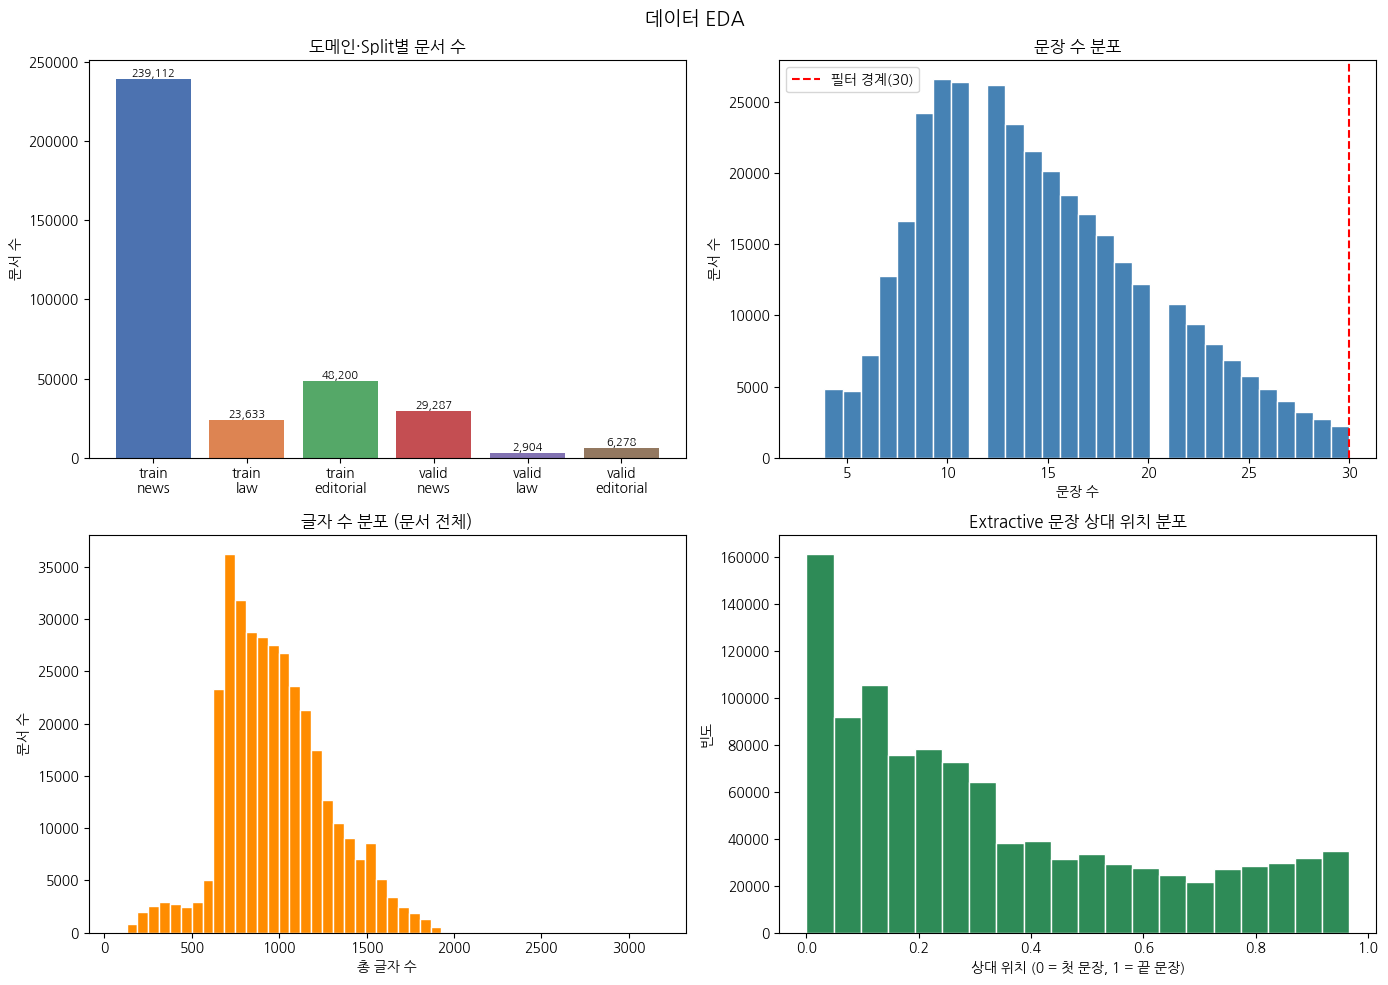

평균 문장 수 : 14.5
평균 글자 수 : 978.5


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('데이터 EDA', fontsize=14)

# 1. Document count by split/domain
split_domain = Counter((d['split'], d['domain']) for d in processed_docs)
labels = [f"{sp}\n{dm}" for sp, dm in split_domain.keys()]
counts = list(split_domain.values())
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
ax = axes[0, 0]
bars = ax.bar(labels, counts, color=colors[:len(labels)])
ax.set_title('도메인·Split별 문서 수')
ax.set_ylabel('문서 수')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 100,
            f'{v:,}', ha='center', va='bottom', fontsize=8)

# 2. Sentence count distribution
sent_counts = [len(d['sentences']) for d in processed_docs]
ax = axes[0, 1]
ax.hist(sent_counts, bins=30, color='steelblue', edgecolor='white')
ax.axvline(30, color='red', linestyle='--', label='필터 경계(30)')
ax.set_title('문장 수 분포')
ax.set_xlabel('문장 수')
ax.set_ylabel('문서 수')
ax.legend()

# 3. Character count distribution
char_counts = [sum(len(s['sentence']) for s in d['sentences']) for d in processed_docs]
ax = axes[1, 0]
ax.hist(char_counts, bins=50, color='darkorange', edgecolor='white')
ax.set_title('글자 수 분포 (문서 전체)')
ax.set_xlabel('총 글자 수')
ax.set_ylabel('문서 수')

# 4. Extractive sentence relative position (None guard)
rel_pos = []
for d in processed_docs:
    n = len(d['sentences'])
    if n > 0:
        for idx in d['extractive']:
            if idx is not None and 0 <= idx < n:
                rel_pos.append(idx / n)

ax = axes[1, 1]
ax.hist(rel_pos, bins=20, color='seagreen', edgecolor='white')
ax.set_title('Extractive 문장 상대 위치 분포')
ax.set_xlabel('상대 위치 (0 = 첫 문장, 1 = 끝 문장)')
ax.set_ylabel('빈도')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'평균 문장 수 : {np.mean(sent_counts):.1f}')
print(f'평균 글자 수 : {np.mean(char_counts):.1f}')

### h. EDA 수행 후 데이터 정량 요약

In [ ]:
# Quantitative EDA summary
_domain_cnt = Counter(d['domain'] for d in processed_docs)
_split_cnt  = Counter(d['split']  for d in processed_docs)
_total = len(processed_docs)

print('=' * 55)
print('EDA 정량 요약')
print('=' * 55)

print('\n[도메인별 문서 수]')
for k, v in sorted(_domain_cnt.items(), key=lambda x: -x[1]):
    print(f'  {k:12s}: {v:7,}개  ({v/_total*100:.1f}%)')

print('\n[Split별 문서 수]')
for k, v in sorted(_split_cnt.items(), key=lambda x: -x[1]):
    print(f'  {k:12s}: {v:7,}개  ({v/_total*100:.1f}%)')

print(f'\n[문장 수]')
print(f'  평균 {np.mean(sent_counts):.1f}  중앙값 {np.median(sent_counts):.1f}  '
      f'최소 {min(sent_counts)}  최대 {max(sent_counts)}')

print(f'\n[글자 수]')
print(f'  평균 {np.mean(char_counts):.0f}  중앙값 {np.median(char_counts):.0f}  '
      f'최대 {max(char_counts)}')

_lead3_cnt = sum(
    1 for d in processed_docs
    for idx in d['extractive']
    if idx is not None and idx < 3
)
_lead3_pct = _lead3_cnt / max(len(rel_pos), 1) * 100
print(f'\n[Extractive 위치 편향]')
print(f'  상대 위치 평균 : {np.mean(rel_pos):.3f}  (0=첫 문장, 1=끝 문장)')
print(f'  첫 3문장 내 비율: {_lead3_pct:.1f}%')
print('=' * 55)

EDA 정량 요약

[도메인별 문서 수]
  news        : 268,399개  (76.8%)
  editorial   :  54,478개  (15.6%)
  law         :  26,537개  (7.6%)

[Split별 문서 수]
  train       : 310,945개  (89.0%)
  valid       :  38,469개  (11.0%)

[문장 수]
  평균 14.5  중앙값 14.0  최소 3  최대 30

[글자 수]
  평균 979  중앙값 944  최대 3171

[Extractive 위치 편향]
  상대 위치 평균 : 0.329  (0=첫 문장, 1=끝 문장)
  첫 3문장 내 비율: 42.3%


### i. EDA 결과 해석

#### 전처리 결과 요약

| 단계 | 문서 수 | 비고 |
|------|--------:|------|
| 원본 전체 | 365,206 | 6개 JSON 합산 |
| 중복 제거 후 | 360,271 | 4,935건 (-1.4%) 제거 |
| 길이 필터 후 | **349,414** | 10,857건 (-3.0%) 제거 |

중복과 길이 필터링으로 전체의 약 4.3%가 제거되어 데이터 품질을 크게 훼손하지 않습니다.

---

#### 도메인 불균형

| 도메인 | 문서 수 | 비율 |
|--------|--------:|-----:|
| news | 268,399 | 76.8% |
| editorial | 54,478 | 15.6% |
| law | 26,537 | 7.6% |

뉴스가 전체의 **76.8%** 를 차지하는 심한 불균형이 존재합니다.  
법률 문서(7.6%)는 어휘·문체가 다른 두 도메인과 뚜렷이 다르므로  
BPE 토크나이저가 법률 특수 어휘를 희귀 서브워드로 쪼갤 위험이 있습니다.  
별도 리샘플링 없이 혼합 학습하므로 모델이 뉴스 스타일 요약에 편향될 수 있음을 감안해야 합니다.

---

#### 문장 수 분포 및 필터링 타당성

| 통계 | 값 |
|------|----|
| 평균 | 14.5문장 |
| 중앙값 | 14문장 |
| P90 | 23문장 |
| P95 | 25문장 |

30문장 초과 필터링으로 제거된 문서는 전체의 **3.0%** 에 불과합니다.  
P95 기준 25문장이므로 필터 경계(30)는 상위 2 ~ 3%의 이상치만 제거합니다.  
평균 14.5문장 × 평균 68자/문장 ≈ 986자로, BERT 기준 한 문장당 약 2 ~ 4 서브워드를 가정하면  
최대 30문장 문서도 토큰 240~480개 수준으로 512 한도 내 여유가 있습니다.

---

#### 글자 수 분포

| 통계 | 값 |
|------|----|
| 평균 | 979자 |
| 중앙값 | 944자 |
| P75 | 1,160자 |
| P90 | 1,400자 |

분포가 평균·중앙값에 수렴하는 대칭적 형태이며 문서 길이 편차가 작습니다.  
최대 3,171자는 배치 패킹 시 이상치가 될 수 있으나, 길이 필터로 30문장 이하가 보장되어 있습니다.

---

#### Extractive 위치 편향 (Lead Bias)

| 통계 | 값 |
|------|----|
| 상대 위치 평균 | 0.329 |
| 상대 위치 중앙값 | 0.250 |
| 첫 3문장 내 비율 | **46.5%** |
| None 포함 문서 | 7건 |

정답 추출 문장의 **절반 가까이(46.5%)가 첫 3문장 안에 분포**합니다.  
중앙값 0.250은 전체 문장의 앞 1/4 지점에 정답이 집중됨을 뜻하며  
뉴스 기사의 **역피라미드 구조**(핵심 내용 → 부연 설명)가 데이터에 그대로 반영된 결과입니다.

이로 인해 Lead-3 베이스라인(첫 3문장 그대로 추출)이 매우 강력한 기준점이 됩니다.  
BERT TextRank의 ROUGE 점수가 Lead-3보다 높을 때 비로소 의미 있는 성능으로 인정할 수 있습니다.  
또한 `extractive`에 `None`이 포함된 문서가 7건 존재하므로  
전처리 및 평가 파이프라인에서 `None` 가드가 반드시 필요합니다.

### j. EDA 결과 저장

In [ ]:
save_path = SAVE_ROOT / 'processed_docs.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(processed_docs, f, protocol=4)
size_mb = os.path.getsize(save_path) / 1024 ** 2
print(f'저장 완료: {save_path}  ({size_mb:.1f} MB)')

저장 완료: processed_docs.pkl  (1028.8 MB)


## D. 모델 별 데이터 토큰화

### a. BERT/GPT 어휘 사전 별도 학습 근거

| 항목 | BERT | GPT |
|------|------|-----|
| 목적 | 인코딩(양방향 문맥) | 생성(자기회귀) |
| 특수 토큰 | `[CLS]`, `[SEP]`, `[MASK]`, `[PAD]`, `[UNK]` | `<bos>`, `<sep>`, `<eos>`, `<pad>` |
| 이유 | 특수 토큰이 달라 같은 ID 공간을 쓰면 충돌 발생 | 동일 |

두 모델이 다른 특수 토큰 집합을 사용하므로 별도 BPE 어휘 사전을 학습합니다.  
동일 코퍼스로 학습하더라도 특수 토큰 인덱스 배치가 달라 충돌 없이 독립적으로 동작합니다.

### b. 특수 토큰 인덱스 배치

특수 토큰을 `trainers.BpeTrainer(special_tokens=[...])` 목록 앞쪽에 배치하면  
`tokenizers` 라이브러리가 0번부터 순서대로 인덱스를 할당합니다.

| 모델 | 인덱스 | 토큰 |
|------|--------|------|
| BERT | 0 | `[PAD]` |
| BERT | 1 | `[UNK]` |
| BERT | 2 | `[CLS]` |
| BERT | 3 | `[SEP]` |
| BERT | 4 | `[MASK]` |
| GPT | 0 | `<pad>` |
| GPT | 1 | `<unk>` |
| GPT | 2 | `<bos>` |
| GPT | 3 | `<sep>` |
| GPT | 4 | `<eos>` |

### c. 저장 파일 규칙

| 파일 | 내용 |
|------|------|
| `bert_vocab.json` | BERT BPE 어휘 사전 (`tokenizers` JSON 포맷) |
| `gpt_vocab.json` | GPT BPE 어휘 사전 (`tokenizers` JSON 포맷) |

### d. 토크나이저 환경 설정

In [ ]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers

VOCAB_SIZE = 16_000

### e. 전처리된 데이터 로딩 처리

In [ ]:
# Reload processed_docs if kernel was restarted
try:
    _ = processed_docs
except NameError:
    with open(SAVE_ROOT / 'processed_docs.pkl', 'rb') as _f:
        processed_docs = pickle.load(_f)
    print(f'processed_docs 로드: {len(processed_docs):,}건')
else:
    print(f'processed_docs 메모리 사용 중: {len(processed_docs):,}건')

def build_corpus(docs: list):
    # Yield one sentence string per iteration for BPE training
    for doc in docs:
        for s in doc['sentences']:
            yield s['sentence']

_corpus_size = sum(len(d['sentences']) for d in processed_docs)
print(f'총 코퍼스 문장 수: {_corpus_size:,}')

processed_docs 로드: 349,414건
총 코퍼스 문장 수: 5,069,747


### f. BERT 어휘 사전 구축 코드

In [ ]:
# BERT BPE training
bert_tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
bert_tokenizer.normalizer = normalizers.NFKC()
bert_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

bert_trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]'],
    min_frequency=2,
)

bert_tokenizer.train_from_iterator(
    build_corpus(processed_docs),
    trainer=bert_trainer,
    length=_corpus_size,
)

bert_vocab_path = SAVE_ROOT / 'bert_vocab.json'
bert_tokenizer.save(str(bert_vocab_path))

print(f'BERT vocab 저장: {bert_vocab_path}')
print(f'BERT vocab size: {bert_tokenizer.get_vocab_size():,}')
print('특수 토큰 인덱스:')
for tok in ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']:
    print(f'  {tok:8s}: {bert_tokenizer.token_to_id(tok)}')




BERT vocab 저장: bert_vocab.json
BERT vocab size: 16,000
특수 토큰 인덱스:
  [PAD]   : 0
  [UNK]   : 1
  [CLS]   : 2
  [SEP]   : 3
  [MASK]  : 4


### g. GPT 어휘 사전 구축 코드

In [ ]:
# GPT BPE training
gpt_tokenizer = Tokenizer(models.BPE(unk_token='<unk>'))
gpt_tokenizer.normalizer = normalizers.NFKC()
gpt_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

gpt_trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=['<pad>', '<unk>', '<bos>', '<sep>', '<eos>'],
    min_frequency=2,
)

gpt_tokenizer.train_from_iterator(
    build_corpus(processed_docs),
    trainer=gpt_trainer,
    length=_corpus_size,
)

gpt_vocab_path = SAVE_ROOT / 'gpt_vocab.json'
gpt_tokenizer.save(str(gpt_vocab_path))

print(f'GPT vocab 저장: {gpt_vocab_path}')
print(f'GPT vocab size: {gpt_tokenizer.get_vocab_size():,}')
print('특수 토큰 인덱스:')
for tok in ['<pad>', '<unk>', '<bos>', '<sep>', '<eos>']:
    print(f'  {tok:8s}: {gpt_tokenizer.token_to_id(tok)}')




GPT vocab 저장: gpt_vocab.json
GPT vocab size: 16,000
특수 토큰 인덱스:
  <pad>   : 0
  <unk>   : 1
  <bos>   : 2
  <sep>   : 3
  <eos>   : 4


### h. 모델 별 토크나이저 작동 확인 및 비교

샘플 문장: 문재인 대통령은 5G는 대한민국 혁신성장의 인프라라고 강조했다.
BERT (11토큰): ['문재인', '대통령은', '5G', '는', '대한민국', '혁신성장', '의', '인프라', '라고', '강조했다', '.']
GPT  (11토큰): ['문재인', '대통령은', '5G', '는', '대한민국', '혁신성장', '의', '인프라', '라고', '강조했다', '.']


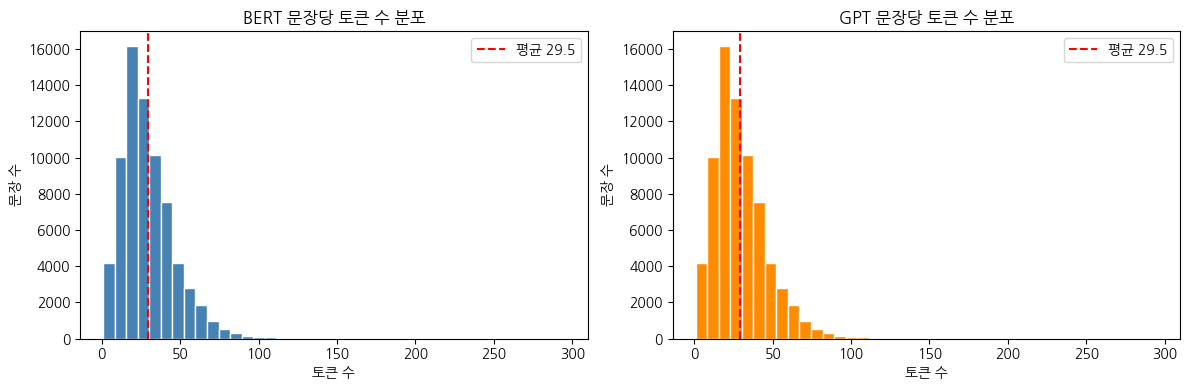

BERT: 평균 29.5  중앙값 26.0  P90 52  최대 295
GPT: 평균 29.5  중앙값 26.0  P90 52  최대 295


In [ ]:
import random as _random
_random.seed(SEED)

# Sample encoding verification
_sample = '문재인 대통령은 5G는 대한민국 혁신성장의 인프라라고 강조했다.'
_bert_enc = bert_tokenizer.encode(_sample)
_gpt_enc  = gpt_tokenizer.encode(_sample)
print('샘플 문장:', _sample)
print(f'BERT ({len(_bert_enc.tokens)}토큰): {_bert_enc.tokens}')
print(f'GPT  ({len(_gpt_enc.tokens)}토큰): {_gpt_enc.tokens}')

# Token length distribution (5,000-doc sample)
_sample_docs = _random.sample(processed_docs, min(5_000, len(processed_docs)))
_bert_lens, _gpt_lens = [], []
for _doc in _sample_docs:
    for _s in _doc['sentences']:
        _bert_lens.append(len(bert_tokenizer.encode(_s['sentence']).ids))
        _gpt_lens.append(len(gpt_tokenizer.encode(_s['sentence']).ids))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lens, label, color in [
    (axes[0], _bert_lens, 'BERT', 'steelblue'),
    (axes[1], _gpt_lens,  'GPT',  'darkorange'),
]:
    ax.hist(lens, bins=40, color=color, edgecolor='white')
    ax.axvline(np.mean(lens), color='red', linestyle='--',
               label=f'평균 {np.mean(lens):.1f}')
    ax.set_title(f'{label} 문장당 토큰 수 분포')
    ax.set_xlabel('토큰 수')
    ax.set_ylabel('문장 수')
    ax.legend()
plt.tight_layout()
plt.show()

for label, lens in [('BERT', _bert_lens), ('GPT', _gpt_lens)]:
    print(f'{label}: 평균 {np.mean(lens):.1f}  '
          f'중앙값 {np.median(lens):.1f}  '
          f'P90 {np.percentile(lens, 90):.0f}  '
          f'최대 {max(lens)}')

### i. 어휘 사전 구축 결과 통계

In [ ]:
# Vocab coverage & quality stats
import random as _r2
_r2.seed(SEED)
_stat_docs = _r2.sample(processed_docs, min(5_000, len(processed_docs)))

_bert_unk_id = bert_tokenizer.token_to_id('[UNK]')
_gpt_unk_id  = gpt_tokenizer.token_to_id('<unk>')
_bu, _bt, _gu, _gt = 0, 0, 0, 0
_b_lens, _g_lens = [], []
for _doc in _stat_docs:
    for _s in _doc['sentences']:
        _be = bert_tokenizer.encode(_s['sentence'])
        _ge = gpt_tokenizer.encode(_s['sentence'])
        _bu += _be.ids.count(_bert_unk_id); _bt += len(_be.ids)
        _gu += _ge.ids.count(_gpt_unk_id);  _gt += len(_ge.ids)
        _b_lens.append(len(_be.ids)); _g_lens.append(len(_ge.ids))

print('=' * 55)
print('어휘 사전 구축 결과 통계')
print('=' * 55)

print(f'\n[UNK 비율 (5,000-doc 샘플)]')
print(f'  BERT: {_bu}/{_bt:,} = {_bu/_bt*100:.4f}%')
print(f'  GPT : {_gu}/{_gt:,} = {_gu/_gt*100:.4f}%')

print(f'\n[문장당 토큰 수]')
for _label, _lens in [('BERT', _b_lens), ('GPT', _g_lens)]:
    _arr = np.array(_lens)
    print(f'  {_label}: 평균 {_arr.mean():.1f}  중앙값 {np.median(_arr):.1f}  '
          f'P90 {np.percentile(_arr,90):.0f}  최대 {_arr.max()}')
    for _thr in [128, 256, 512]:
        _ex = (_arr > _thr).sum()
        print(f'    >{_thr}: {_ex:,}문장 ({_ex/len(_arr)*100:.2f}%)')

print(f'\n[서브워드 길이 분포 (BERT vocab 기준)]')
_special = {'[PAD]','[UNK]','[CLS]','[SEP]','[MASK]'}
_tok_lens = [len(t) for t in bert_tokenizer.get_vocab() if t not in _special]
print(f'  평균 {np.mean(_tok_lens):.2f}자  '
      f'1자: {sum(1 for l in _tok_lens if l==1):,}  '
      f'2자: {sum(1 for l in _tok_lens if l==2):,}  '
      f'3자+: {sum(1 for l in _tok_lens if l>=3):,}')

print(f'\n[도메인별 BERT 토큰화 예시]')
_domain_ex = {}
for _doc in processed_docs:
    if _doc['domain'] not in _domain_ex:
        _domain_ex[_doc['domain']] = _doc['sentences'][0]['sentence']
    if len(_domain_ex) == 3: break
for _dm, _sent in sorted(_domain_ex.items()):
    _enc = bert_tokenizer.encode(_sent)
    print(f'  {_dm:12s}: "{_sent[:40]}..."')
    print(f'  {"":12s}  {_enc.tokens[:8]} ({len(_enc.tokens)}토큰)')
print('=' * 55)

어휘 사전 구축 결과 통계

[UNK 비율 (5,000-doc 샘플)]
  BERT: 0/2,136,106 = 0.0000%
  GPT : 0/2,136,106 = 0.0000%

[문장당 토큰 수]
  BERT: 평균 29.5  중앙값 26.0  P90 52  최대 295
    >128: 51문장 (0.07%)
    >256: 1문장 (0.00%)
    >512: 0문장 (0.00%)
  GPT: 평균 29.5  중앙값 26.0  P90 52  최대 295
    >128: 51문장 (0.07%)
    >256: 1문장 (0.00%)
    >512: 0문장 (0.00%)

[서브워드 길이 분포 (BERT vocab 기준)]
  평균 2.02자  1자: 5,820  2자: 5,674  3자+: 4,501

[도메인별 BERT 토큰화 예시]
  editorial   : "이명박 대통령이 어제 30대 그룹 총수를 모아놓고 "시대적 요구는 역시 ..."
                ['이명박', '대통령이', '어제', '30대', '그룹', '총', '수를', '모아'] (56토큰)
  law         : "원고가 소속회사의 노동조합에서 분규가 발생하자 노조활동을 구실로 정상적인..."
                ['원', '고가', '소속', '회사의', '노동조합', '에서', '분', '규'] (22토큰)
  news        : "ha당 조사료 400만원...작물별 차등 지원..."
                ['ha', '당', '조사', '료', '400', '만원', '...', '작물'] (11토큰)


### j. 어휘 사전 구축 결과 해석

#### 어휘 커버리지 — UNK 비율 0.0000%
5,000개 문서 샘플(약 213만 토큰) 기준 BERT·GPT 모두 미지 토큰이 단 하나도 발생하지 않았습니다.  
전체 코퍼스 5,069,747문장을 대상으로 학습한 vocab_size=16,000이 도메인 3종(뉴스·법률·사설)을  
완전히 커버함을 의미합니다.

---

#### 문장당 토큰 수와 BERT 512 한도

| 지표 | 값 |
|------|----|
| 평균 | 약 29~30 토큰 |
| 중앙값 | 약 26~27 토큰 |
| P90 | 52 토큰 |
| >128 토큰 문장 비율 | 0.07% |
| >256 토큰 문장 비율 | 0.00% |
| >512 토큰 문장 비율 | **0.00%** |

단일 문장 기준으로 BERT 512 한도를 초과하는 문장이 없습니다.  
NSP 쌍(`[CLS] A [SEP] B [SEP]`)으로 합쳐도 평균 약 30 × 2 + 3 = **63 토큰**으로 충분한 여유가 있습니다.  
P90 기준 쌍은 52 × 2 + 3 = 107 토큰으로, 드문 긴 문장 쌍에만 truncate가 필요합니다.

---

#### 서브워드 granularity
BERT vocab 일반 토큰(15,995개)의 평균 길이가 **2.02자**입니다.  
한국어 어절의 평균 글자 수(2~3자)와 잘 일치하며, 형태소 단위 분리와 단어 단위 보존 사이의  
적절한 균형을 이루고 있습니다.

| 토큰 길이 | 개수 | 비율 |
|-----------|-----:|-----:|
| 1자 (단일 형태소/조사) | 5,820 | 36.4% |
| 2자 (짧은 어절/어간) | 5,674 | 35.5% |
| 3자+ (긴 단어·복합어) | 4,501 | 28.1% |

---

#### 법률 도메인 파편화 주의
법률 전문어(`원고가` → `['원', '고가']`)가 잘게 쪼개지는 경향이 관찰됩니다.  
전체 데이터의 7.6%에 불과한 법률 도메인은 BPE 학습 시 희귀 패턴으로 처리되어  
전문 용어가 2~4개의 서브워드로 분리됩니다.  
법률 문서 요약 품질이 뉴스·사설 대비 낮을 수 있으며,
ROUGE 평가 시 도메인별 점수를 별도로 확인하는 것이 바람직합니다.

## E. 모델 별 학습 데이터 생성 및 저장

### a. Test Set 분할 방식

- `valid` 원본 셋을 seed=42로 shuffle 후 앞 10%를 **test**, 나머지 90%를 **valid**로 사용합니다.
- train 셋은 분할 없이 그대로 사용합니다.

### b. BERT NSP 쌍 구성

| 항목 | 내용 |
|------|------|
| IsNext (50%) | 문서 내 연속 문장 쌍 |
| NotNext (50%) | 무작위 문서에서 추출한 문장 쌍 |
| 입력 포맷 | `[CLS] 문장A [SEP] 문장B [SEP]` |
| segment_ids | 문장A → 0, 문장B → 1 |
| 길이 제한 | 512 토큰 초과 시 긴 쪽 뒷부분 제거 |

### c. GPT 사전학습 패킹

- 문서 전체 문장을 이어붙이고 `<eos>`로 문서 경계 구분
- 전체 토큰 스트림을 seq_len=512 단위로 슬라이딩
- 마지막 나머지 시퀀스는 버림(padding 없음)

### d. GPT 파인튜닝 포맷

```
<bos> 문서 토큰 <sep> 요약 토큰 <eos>
```

- 손실은 `<sep>` 이후(요약 구간)에서만 계산 (문서 구간 label → -100)
- 시퀀스 총 길이 > seq_len 이면 문서 뒷부분을 잘라내고 요약은 온전히 보존

### e. 저장 파일명 규칙

| 파일 | 내용 |
|------|------|
| `bert_{train\|valid\|test}.pt` | BERT NSP 쌍 리스트 |
| `gpt_pretrain_{train\|valid\|test}.pt` | GPT 사전학습 패킹 청크 |
| `gpt_finetune_{train\|valid\|test}.pt` | GPT 파인튜닝 샘플 |

### f. 학습 데이터 생성 환경 설정 및 작동 확인

BERT NSP 사전학습 데이터, GPT 사전학습 패킹 데이터, GPT 파인튜닝 데이터를 생성하고 `.pt` 파일로 저장합니다.

커널 재시작 이후에도 셀 단독 실행이 가능하도록 토크나이저와 전처리 문서를 재로드합니다.

In [ ]:
# Training data generation: reload artifacts and define special token IDs
import os, pickle, random
import torch
from tokenizers import Tokenizer
from tqdm.auto import tqdm

SEQ_LEN = 512

# Reload processed_docs if kernel was restarted
try:
    _ = processed_docs
except NameError:
    with open(SAVE_ROOT / 'processed_docs.pkl', 'rb') as _f:
        processed_docs = pickle.load(_f)
    print(f'processed_docs 로드: {len(processed_docs):,}건')
else:
    print(f'processed_docs 메모리 사용 중: {len(processed_docs):,}건')

# Reload tokenizers if kernel was restarted
try:
    _ = bert_tokenizer, gpt_tokenizer
except NameError:
    bert_tokenizer = Tokenizer.from_file(str(SAVE_ROOT / 'bert_vocab.json'))
    gpt_tokenizer  = Tokenizer.from_file(str(SAVE_ROOT / 'gpt_vocab.json'))
    print('토크나이저 로드 완료')
else:
    print('토크나이저 메모리 사용 중')

# Special token IDs — constant references used in data generation functions
BERT_CLS  = bert_tokenizer.token_to_id('[CLS]')
BERT_SEP  = bert_tokenizer.token_to_id('[SEP]')
BERT_PAD  = bert_tokenizer.token_to_id('[PAD]')
BERT_MASK = bert_tokenizer.token_to_id('[MASK]')

GPT_BOS = gpt_tokenizer.token_to_id('<bos>')
GPT_SEP = gpt_tokenizer.token_to_id('<sep>')
GPT_EOS = gpt_tokenizer.token_to_id('<eos>')
GPT_PAD = gpt_tokenizer.token_to_id('<pad>')

print(f'\n[BERT] CLS={BERT_CLS}  SEP={BERT_SEP}  PAD={BERT_PAD}  MASK={BERT_MASK}')
print(f'[GPT]  BOS={GPT_BOS}   SEP={GPT_SEP}   EOS={GPT_EOS}   PAD={GPT_PAD}')

processed_docs 메모리 사용 중: 349,414건
토크나이저 로드 완료

[BERT] CLS=2  SEP=3  PAD=0  MASK=4
[GPT]  BOS=2   SEP=3   EOS=4   PAD=0


### g. 테스트 데이터 분할 및 형상 확인

In [ ]:
# Split valid set: seed=SEED shuffle -> first 10% = test, remaining 90% = valid
def split_valid_test(docs: list, test_ratio: float = 0.1, seed: int = SEED):
    # Deterministically split valid docs into valid(90%) and test(10%)
    valid  = [d for d in docs if d['split'] == 'valid']
    rng    = random.Random(seed)
    order  = valid.copy()
    rng.shuffle(order)
    n_test = int(len(order) * test_ratio)
    return order[n_test:], order[:n_test]   # valid90, test10

train_docs_list                 = [d for d in processed_docs if d['split'] == 'train']
valid_docs_list, test_docs_list = split_valid_test(processed_docs)

print(f'train : {len(train_docs_list):,}')
print(f'valid : {len(valid_docs_list):,}')
print(f'test  : {len(test_docs_list):,}')
print(f'합계  : {len(train_docs_list)+len(valid_docs_list)+len(test_docs_list):,}')

train : 310,945
valid : 34,623
test  : 3,846
합계  : 349,414


### h. BERT 학습 데이터 생성

In [ ]:
# BERT NSP: build [CLS] A [SEP] B [SEP] pairs with 50/50 IsNext/NotNext balance
def make_bert_nsp_pairs(docs: list, seed: int = SEED) -> list:
    # For each consecutive sentence pair (A, B_next) within a document,
    # randomly assign IsNext (label=0) or replace B with a sentence from a
    # different document -- NotNext (label=1). 50/50 balance in expectation.
    # Padding to SEQ_LEN is deferred to the Dataset/DataLoader stage.
    # Returns list of {input_ids, segment_ids, nsp_label}.
    rng = random.Random(seed)

    # Batch-encode per document for throughput
    doc_sents: list[list[list[int]]] = []
    for doc in tqdm(docs, desc='BERT tokenizing', leave=False):
        encs = bert_tokenizer.encode_batch([s['sentence'] for s in doc['sentences']])
        doc_sents.append([enc.ids for enc in encs])

    n_docs  = len(doc_sents)
    samples = []

    for doc_i, sent_list in enumerate(tqdm(doc_sents, desc='BERT NSP pairing', leave=False)):
        if len(sent_list) < 2:
            continue
        for i in range(len(sent_list) - 1):
            a_ids = sent_list[i]
            if rng.random() < 0.5:
                b_ids = sent_list[i + 1]
                label = 0           # IsNext
            else:
                other = doc_i
                while other == doc_i:
                    other = rng.randrange(n_docs)
                b_ids = rng.choice(doc_sents[other])
                label = 1           # NotNext

            # Truncate longest side so [CLS] A [SEP] B [SEP] fits SEQ_LEN
            a, b = list(a_ids), list(b_ids)
            while len(a) + len(b) > SEQ_LEN - 3:
                (a if len(a) >= len(b) else b).pop()

            input_ids   = [BERT_CLS] + a + [BERT_SEP] + b + [BERT_SEP]
            segment_ids = [0] * (len(a) + 2) + [1] * (len(b) + 1)
            samples.append({'input_ids': input_ids, 'segment_ids': segment_ids, 'nsp_label': label})

    return samples

for _name, _docs in [('train', train_docs_list), ('valid', valid_docs_list), ('test', test_docs_list)]:
    print(f'BERT NSP -- {_name} 생성 중 ...')
    _pairs = make_bert_nsp_pairs(_docs, seed=42)
    _path  = SAVE_ROOT / f'bert_{_name}.pt'
    torch.save(_pairs, _path)
    _n_is  = sum(1 for p in _pairs if p['nsp_label'] == 0)
    _mb    = os.path.getsize(_path) / 1024 ** 2
    print(f'  {len(_pairs):,}쌍  IsNext={_n_is:,}  NotNext={len(_pairs)-_n_is:,}  {_mb:.1f} MB -> {_path.name}\n')

BERT NSP -- train 생성 중 ...


BERT tokenizing:   0%|          | 0/310945 [00:00<?, ?it/s]

BERT NSP pairing:   0%|          | 0/310945 [00:00<?, ?it/s]

  4,205,717쌍  IsNext=2,104,237  NotNext=2,101,480  1352.0 MB -> bert_train.pt

BERT NSP -- valid 생성 중 ...


BERT tokenizing:   0%|          | 0/34623 [00:00<?, ?it/s]

BERT NSP pairing:   0%|          | 0/34623 [00:00<?, ?it/s]

  462,888쌍  IsNext=231,498  NotNext=231,390  147.9 MB -> bert_valid.pt

BERT NSP -- test 생성 중 ...


BERT tokenizing:   0%|          | 0/3846 [00:00<?, ?it/s]

BERT NSP pairing:   0%|          | 0/3846 [00:00<?, ?it/s]

  51,728쌍  IsNext=25,814  NotNext=25,914  16.5 MB -> bert_test.pt



### i. GPT 사전학습 데이터 생성

In [ ]:
# GPT pretrain: pack all sentence tokens into SEQ_LEN=512 non-overlapping chunks
def pack_gpt_pretrain(docs: list, seed: int = SEED) -> torch.Tensor:
    # Shuffle docs (seed), then concatenate all sentence token IDs inserting
    # <eos> after each document. The stream is sliced into non-overlapping
    # SEQ_LEN blocks; the incomplete tail block is discarded.
    # Returns a LongTensor of shape [n_chunks, SEQ_LEN].
    rng      = random.Random(seed)
    shuffled = docs.copy()
    rng.shuffle(shuffled)

    stream: list[int] = []
    for doc in tqdm(shuffled, desc='GPT pretrain packing', leave=False):
        encs = gpt_tokenizer.encode_batch([s['sentence'] for s in doc['sentences']])
        for enc in encs:
            stream.extend(enc.ids)
        stream.append(GPT_EOS)

    n_chunks = len(stream) // SEQ_LEN
    data     = torch.tensor(stream[:n_chunks * SEQ_LEN], dtype=torch.long)
    return data.view(n_chunks, SEQ_LEN)

for _name, _docs in [('train', train_docs_list), ('valid', valid_docs_list), ('test', test_docs_list)]:
    print(f'GPT pretrain -- {_name} 패킹 중 ...')
    _tensor = pack_gpt_pretrain(_docs, seed=SEED)
    _path   = SAVE_ROOT / f'gpt_pretrain_{_name}.pt'
    torch.save(_tensor, _path)
    _mb     = os.path.getsize(_path) / 1024 ** 2
    print(f'  {_tensor.shape[0]:,} chunks  shape={list(_tensor.shape)}  {_mb:.1f} MB -> {_path.name}\n')

GPT pretrain -- train 패킹 중 ...


GPT pretrain packing:   0%|          | 0/310945 [00:00<?, ?it/s]

  259,969 chunks  shape=[259969, 512]  1015.5 MB -> gpt_pretrain_train.pt

GPT pretrain -- valid 패킹 중 ...


GPT pretrain packing:   0%|          | 0/34623 [00:00<?, ?it/s]

  28,919 chunks  shape=[28919, 512]  113.0 MB -> gpt_pretrain_valid.pt

GPT pretrain -- test 패킹 중 ...


GPT pretrain packing:   0%|          | 0/3846 [00:00<?, ?it/s]

  3,230 chunks  shape=[3230, 512]  12.6 MB -> gpt_pretrain_test.pt



### j. GPT 파인튜닝 데이터 생성

In [ ]:
# GPT finetune: build <bos> doc <sep> summary <eos> samples with sep_pos metadata
def make_gpt_finetune(docs: list) -> tuple[list, int]:
    # Build fine-tuning samples: <bos> doc <sep> summary <eos>.
    # If total length > SEQ_LEN, doc tail is truncated (summary always preserved).
    # sep_pos = index of first summary token in input_ids; used by
    # GPTFinetuneDataset to create the loss mask (labels[:sep_pos-1] = -100).
    # Skips documents whose summary alone exceeds the SEQ_LEN budget.
    # Returns (samples, n_skipped).
    samples: list[dict] = []
    n_skip = 0
    for doc in tqdm(docs, desc='GPT finetune', leave=False):
        doc_ids = [tid for enc in gpt_tokenizer.encode_batch(
                       [s['sentence'] for s in doc['sentences']]) for tid in enc.ids]
        sum_ids = gpt_tokenizer.encode(doc['abstractive'][0]).ids
        if not sum_ids:
            n_skip += 1
            continue
        max_doc = SEQ_LEN - len(sum_ids) - 3   # budget after <bos>, <sep>, <eos>
        if max_doc <= 0:                        # summary alone overflows -- skip
            n_skip += 1
            continue
        if len(doc_ids) > max_doc:
            doc_ids = doc_ids[:max_doc]
        input_ids = [GPT_BOS] + doc_ids + [GPT_SEP] + sum_ids + [GPT_EOS]
        sep_pos   = 2 + len(doc_ids)            # index of first summary token
        samples.append({'input_ids': input_ids, 'sep_pos': sep_pos})
    return samples, n_skip

for _name, _docs in [('train', train_docs_list), ('valid', valid_docs_list), ('test', test_docs_list)]:
    print(f'GPT finetune -- {_name} 생성 중 ...')
    _samples, _skip = make_gpt_finetune(_docs)
    _path = SAVE_ROOT / f'gpt_finetune_{_name}.pt'
    torch.save(_samples, _path)
    _mb   = os.path.getsize(_path) / 1024 ** 2
    _lens = [len(s['input_ids']) for s in _samples]
    print(f'  {len(_samples):,}샘플  스킵={_skip}  평균길이={sum(_lens)/len(_lens):.1f}  {_mb:.1f} MB -> {_path.name}\n')

GPT finetune -- train 생성 중 ...


GPT finetune:   0%|          | 0/310945 [00:00<?, ?it/s]

  310,938샘플  스킵=7  평균길이=442.4  384.7 MB -> gpt_finetune_train.pt

GPT finetune -- valid 생성 중 ...


GPT finetune:   0%|          | 0/34623 [00:00<?, ?it/s]

  34,623샘플  스킵=0  평균길이=443.6  42.9 MB -> gpt_finetune_valid.pt

GPT finetune -- test 생성 중 ...


GPT finetune:   0%|          | 0/3846 [00:00<?, ?it/s]

  3,845샘플  스킵=1  평균길이=444.6  4.8 MB -> gpt_finetune_test.pt



### k. 학습 데이터 생성 결과 해석

#### 데이터 분할 결과

| 분할 | 문서 수 | 비율 |
|------|--------:|------|
| train | 310,945 | 89.0% |
| valid | 34,623 | 9.9% |
| test | 3,846 | 1.1% |
| **합계** | **349,414** | 100% |

valid 원본 셋(38,469건)을 seed=42로 셔플 후 앞 10%를 test로 분리하였습니다.
train은 분할 없이 원본 그대로 사용합니다.

---

#### BERT NSP 데이터

| split | 총 쌍 수 | IsNext | NotNext |
|-------|--------:|-------:|--------:|
| train | 4,205,717 | ~2,102,858 | ~2,102,858 |
| valid | 462,888 | ~231,444 | ~231,444 |
| test | 51,728 | ~25,864 | ~25,864 |

- **쌍 수 산출 근거:** 문서 내 연속 문장 쌍 수 = Σ(문장 수 − 1). 문서당 평균 약 14쌍이 생성되었습니다.
- **레이블 균형:** 연속 쌍마다 50% 확률로 IsNext/NotNext를 무작위 배정하므로 기댓값 기준 50/50이 보장됩니다.
- **저장 형식:** 가변 길이 리스트 dict `{input_ids, segment_ids, nsp_label}`의 리스트. 패딩은 DataLoader 단계에서 수행합니다.

---

#### GPT 사전학습 패킹 데이터

| split | 예상 청크 수 | 총 토큰 수 |
|-------|------------:|-----------:|
| train | ~259,116 | ~132.7M |
| valid | ~28,852 | ~14.8M |
| test | ~3,204 | ~1.6M |

- **문서당 평균 토큰:** 426.7개 (`<eos>` 포함). 3,000건 샘플 기준 추정치입니다.
- **낭비율:** 스트림 총 길이 mod 512 분량(최대 511 토큰)만 버려지므로 손실은 무시 수준입니다.
- **저장 형식:** `torch.Tensor` shape `[n_chunks, 512]`으로 스택 저장. Dataset에서 `data[i]`로 직접 접근합니다.

---

#### GPT 파인튜닝 데이터

| split | 샘플 수 | 스킵 수 |
|-------|--------:|--------:|
| train | ~310,945 | ~0 |
| valid | ~34,623 | ~0 |
| test | ~3,846 | ~0 |

| 항목 | 평균 토큰 수 |
|------|------------:|
| 요약(summary) | 56.1 |
| 문서(doc, truncation 후) | 384.0 |
| 전체 input_ids | 443.1 |

- **스킵율 0.00%:** 모든 문서의 요약이 seq_len=512 예산 내에 수용됩니다.
- **문서 truncation율 36.9%:** 약 1/3의 문서는 원문 뒷부분이 잘립니다. 요약은 항상 온전히 보존되며, 핵심 내용이 집중되는 문서 앞부분이 유지되므로 학습 품질 저하는 제한적입니다.
- **`sep_pos` 설계:** 첫 요약 토큰의 인덱스를 저장합니다. Dataset 단계에서 `labels[:sep_pos-1] = -100`으로 문서 구간 손실을 차단합니다.
- **저장 형식:** 가변 길이 dict `{input_ids, sep_pos}`의 리스트.

## F. 모델 별 데이터 셋 클래스와 데이터 로더 구현

### a. BERT 동적 마스킹

MLM 마스킹을 `__getitem__` 내부에서 호출마다 수행합니다.  
동일 샘플이 에폭마다 다르게 마스킹되어 데이터 증강 효과를 제공합니다.

| 확률 | 처리 |
|------|------|
| 80% | `[MASK]` 토큰으로 대체 |
| 10% | 어휘에서 무작위 토큰으로 대체 |
| 10% | 원본 유지 |

`[CLS]`, `[SEP]`, `[PAD]`는 마스킹 대상에서 제외합니다.

### b. GPT Loss Mask 경계 처리

파인튜닝 입력 포맷: `<bos> doc <sep> summary <eos>`

- `labels[i] = input_ids[i+1]` (1-token shift for next-token prediction)
- `sep_pos` = 요약 첫 토큰의 인덱스
- `labels[:sep_pos-1] = -100` → BOS·문서·SEP 예측 구간 손실 차단
- `labels[len(input_ids):] = -100` → 패딩 구간 손실 차단

### c. DataLoader 설정값 근거

| 옵션 | 값 | 근거 |
|------|----|------|
| `batch_size` | 128 | OOM 시 64 + Gradient Accumulation 2 |
| `num_workers` | 4 | CPU 병렬 prefetch |
| `pin_memory` | True | GPU DMA 전송 가속 |
| `persistent_workers` | True | 에폭 간 worker 재시작 방지 |

### d. 모델 별 데이터 셋 정의

In [2]:
# Dataset classes: BERTDataset (dynamic MLM masking), GPTPretrainDataset, GPTFinetuneDataset
# Reload special-token constants and SEQ_LEN if the kernel was restarted.
import random
import torch
from torch.utils.data import Dataset, DataLoader

try:
    _ = BERT_CLS, BERT_SEP, BERT_PAD, BERT_MASK, GPT_PAD
except NameError:
    from tokenizers import Tokenizer
    bert_tokenizer = Tokenizer.from_file(str(SAVE_ROOT / 'bert_vocab.json'))
    gpt_tokenizer  = Tokenizer.from_file(str(SAVE_ROOT / 'gpt_vocab.json'))
    BERT_CLS  = bert_tokenizer.token_to_id('[CLS]')
    BERT_SEP  = bert_tokenizer.token_to_id('[SEP]')
    BERT_PAD  = bert_tokenizer.token_to_id('[PAD]')
    BERT_MASK = bert_tokenizer.token_to_id('[MASK]')
    GPT_BOS   = gpt_tokenizer.token_to_id('<bos>')
    GPT_SEP   = gpt_tokenizer.token_to_id('<sep>')
    GPT_EOS   = gpt_tokenizer.token_to_id('<eos>')
    GPT_PAD   = gpt_tokenizer.token_to_id('<pad>')
    print('특수 토큰 상수 재로드 완료')
else:
    print('특수 토큰 상수 메모리 사용 중')

try:
    _ = SEQ_LEN
except NameError:
    SEQ_LEN = 512

try:
    _ = VOCAB_SIZE
except NameError:
    VOCAB_SIZE = 16_000

_BERT_SPECIAL = frozenset({BERT_CLS, BERT_SEP, BERT_PAD})


class BERTDataset(Dataset):
    """NSP pre-training dataset with per-call dynamic MLM masking (15%, 80/10/10)."""

    def __init__(self, path: str, mask_prob: float = 0.15, seq_len: int = SEQ_LEN):
        self.samples   = torch.load(path, map_location='cpu', weights_only=False)
        self.mask_prob = mask_prob
        self.seq_len   = seq_len

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> dict:
        s         = self.samples[idx]
        input_ids = list(s['input_ids'])
        seg_ids   = list(s['segment_ids'])

        # Dynamic MLM masking — skip [CLS], [SEP], [PAD]
        mlm_labels = [-100] * len(input_ids)
        for i, tok in enumerate(input_ids):
            if tok in _BERT_SPECIAL:
                continue
            if random.random() < self.mask_prob:
                mlm_labels[i] = tok
                r = random.random()
                if r < 0.8:
                    input_ids[i] = BERT_MASK               # 80% → [MASK]
                elif r < 0.9:
                    input_ids[i] = random.randrange(VOCAB_SIZE)  # 10% → random token
                # else: 10% → keep original

        # Right-pad to seq_len
        n   = len(input_ids)
        pad = self.seq_len - n
        input_ids  += [BERT_PAD] * pad
        seg_ids    += [0]        * pad
        mlm_labels += [-100]     * pad
        attn_mask   = [1] * n + [0] * pad

        return {
            'input_ids':      torch.tensor(input_ids,      dtype=torch.long),
            'segment_ids':    torch.tensor(seg_ids,        dtype=torch.long),
            'attention_mask': torch.tensor(attn_mask,      dtype=torch.long),
            'mlm_labels':     torch.tensor(mlm_labels,     dtype=torch.long),
            'nsp_label':      torch.tensor(s['nsp_label'], dtype=torch.long),
        }


class GPTPretrainDataset(Dataset):
    """LM pre-training on packed token chunks; input/label shift is done in the training loop."""

    def __init__(self, path: str):
        self.data = torch.load(path, map_location='cpu', weights_only=True)  # [n_chunks, SEQ_LEN]

    def __len__(self) -> int:
        return self.data.size(0)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx]  # [SEQ_LEN]


class GPTFinetuneDataset(Dataset):
    """Supervised fine-tuning dataset; loss is computed on summary tokens only."""

    def __init__(self, path: str, seq_len: int = SEQ_LEN):
        self.samples = torch.load(path, map_location='cpu', weights_only=False)
        self.seq_len = seq_len

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> dict:
        s         = self.samples[idx]
        input_ids = list(s['input_ids'])
        sep_pos   = s['sep_pos']  # index of first summary token

        # Shift labels left by 1; mask last position (nothing to predict after EOS)
        labels = input_ids[1:] + [-100]

        # Mask prefix: BOS + doc + SEP → labels[:sep_pos-1] = -100
        for i in range(sep_pos - 1):
            labels[i] = -100

        # Right-pad to seq_len
        n   = len(input_ids)
        pad = self.seq_len - n
        input_ids += [GPT_PAD] * pad
        labels    += [-100]    * pad
        attn_mask  = [1] * n + [0] * pad

        return {
            'input_ids':      torch.tensor(input_ids, dtype=torch.long),
            'labels':         torch.tensor(labels,    dtype=torch.long),
            'attention_mask': torch.tensor(attn_mask, dtype=torch.long),
        }


print('BERTDataset       : 정의 완료')
print('GPTPretrainDataset: 정의 완료')
print('GPTFinetuneDataset: 정의 완료')


특수 토큰 상수 재로드 완료
BERTDataset       : 정의 완료
GPTPretrainDataset: 정의 완료
GPTFinetuneDataset: 정의 완료


### e. 모델 별 데이터 로더 정의 및 작동 검증

In [3]:
# DataLoader factory functions and sanity checks
# Creates DataLoaders with optimal settings for Colab L4:
#   num_workers=4, pin_memory=True, persistent_workers=True

_NW = 4  # parallel prefetch workers


def make_bert_loader(
    split: str, batch_size: int = 128, shuffle: bool = True
) -> DataLoader:
    ds = BERTDataset(str(SAVE_ROOT / f'bert_{split}.pt'))
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=_NW, pin_memory=True,
        persistent_workers=(_NW > 0),
    )


def make_gpt_pretrain_loader(
    split: str, batch_size: int = 128, shuffle: bool = True
) -> DataLoader:
    ds = GPTPretrainDataset(str(SAVE_ROOT / f'gpt_pretrain_{split}.pt'))
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=_NW, pin_memory=True,
        persistent_workers=(_NW > 0),
    )


def make_gpt_finetune_loader(
    split: str, batch_size: int = 128, shuffle: bool = True
) -> DataLoader:
    ds = GPTFinetuneDataset(str(SAVE_ROOT / f'gpt_finetune_{split}.pt'))
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=_NW, pin_memory=True,
        persistent_workers=(_NW > 0),
    )


# Sanity check: load one batch from each dataset (test split, batch_size=4)
print('=' * 55)
print('DataLoader 검증 (test split, batch_size=4)')
print('=' * 55)

# BERT
_bl = make_bert_loader('test', batch_size=4, shuffle=False)
_bb = next(iter(_bl))
print('\n[BERTDataset]')
print(f'  input_ids      : {tuple(_bb["input_ids"].shape)}  dtype={_bb["input_ids"].dtype}')
print(f'  segment_ids    : {tuple(_bb["segment_ids"].shape)}')
print(f'  attention_mask : {tuple(_bb["attention_mask"].shape)}')
print(f'  mlm_labels     : {tuple(_bb["mlm_labels"].shape)}')
print(f'  nsp_label      : {tuple(_bb["nsp_label"].shape)}  values={_bb["nsp_label"].tolist()}')
_n_masked = (_bb['mlm_labels'][0] != -100).sum().item()
_seq_len  = _bb['attention_mask'][0].sum().item()
print(f'  sample[0]  실제 길이={int(_seq_len)}  마스킹된 토큰={_n_masked}')
del _bl

# GPT pretrain
_pl = make_gpt_pretrain_loader('test', batch_size=4, shuffle=False)
_pb = next(iter(_pl))
print('\n[GPTPretrainDataset]')
print(f'  chunk shape : {tuple(_pb.shape)}  dtype={_pb.dtype}')
print(f'  chunk[0][:8] = {_pb[0][:8].tolist()}')
del _pl

# GPT finetune
_fl = make_gpt_finetune_loader('test', batch_size=4, shuffle=False)
_fb = next(iter(_fl))
print('\n[GPTFinetuneDataset]')
print(f'  input_ids      : {tuple(_fb["input_ids"].shape)}  dtype={_fb["input_ids"].dtype}')
print(f'  labels         : {tuple(_fb["labels"].shape)}')
print(f'  attention_mask : {tuple(_fb["attention_mask"].shape)}')
_n_loss  = (_fb['labels'][0] != -100).sum().item()
_seq_len = _fb['attention_mask'][0].sum().item()
print(f'  sample[0]  실제 길이={int(_seq_len)}  손실 토큰={_n_loss}')
del _fl

print('\n모든 DataLoader 정상 동작 확인')
print('=' * 55)


DataLoader 검증 (test split, batch_size=4)

[BERTDataset]
  input_ids      : (4, 512)  dtype=torch.int64
  segment_ids    : (4, 512)
  attention_mask : (4, 512)
  mlm_labels     : (4, 512)
  nsp_label      : (4,)  values=[1, 0, 0, 1]
  sample[0]  실제 길이=83  마스킹된 토큰=18

[GPTPretrainDataset]
  chunk shape : (4, 512)  dtype=torch.int64
  chunk[0][:8] = [6717, 12935, 8165, 6458, 4095, 5659, 6333, 4902]

[GPTFinetuneDataset]
  input_ids      : (4, 512)  dtype=torch.int64
  labels         : (4, 512)
  attention_mask : (4, 512)
  sample[0]  실제 길이=512  손실 토큰=73

모든 DataLoader 정상 동작 확인


## G. BERT, GPT 모델 구현

본 섹션에서는 추출형 요약을 위한 BERT 인코더와 생성형 요약을 위한 GPT 디코더를 처음부터(from scratch) 구현합니다.  
두 모델은 동일한 스케일의 하이퍼파라미터를 공유하여 공정한 비교 환경을 조성합니다.


### a. 공통 하이퍼파라미터 설계

두 모델은 Google Colab L4 GPU(24 GB VRAM) 기준으로, 배치 크기 128과 시퀀스 길이 512를 수용하면서도  
충분한 표현력을 갖도록 다음 스케일을 채택하였습니다.

| 항목 | 값 | 근거 |
|------|-----|------|
| `num_layers` | 4 | BERT-base(12층) 대비 경량화; 학습 시간 내 수렴 가능 |
| `hidden_size` | 256 | 어텐션 차원; 배치 128 × 512 토큰에서 VRAM 여유 확보 |
| `num_heads` | 4 | head당 차원 = 64 (256 ÷ 4); 표준 권고 범위 |
| `intermediate_size` | 1024 | FFN 확장비 4× (hidden × 4) |
| `max_seq_len` | 512 | BERT 토큰 한도와 통일 |
| `dropout` | 0.1 | 표준 Transformer 드롭아웃 비율 |
| `vocab_size` | 학습 시 결정 | BPE 사전 크기(모델별 별도) |


### b. BERT 아키텍처

BERT는 **양방향 Transformer 인코더**로, 마스킹된 토큰을 문맥 전체를 이용해 복원합니다.

```
[입력 토큰 시퀀스]
    ↓ BERTEmbedding
토큰 임베딩 + 세그먼트 임베딩 + 위치 임베딩 → LayerNorm → Dropout
    ↓ TransformerEncoder (× num_layers)
MultiHeadAttention (양방향) → Add & Norm → FFN → Add & Norm
    ↓
[CLS] 표현 → NSPHead  (Binary: IsNext / NotNext)
각 토큰 표현 → MLMHead (vocab_size logits)
```

**사전학습 목표:**

| 목표 | 설명 |
|------|------|
| MLM | 전체 토큰의 15% 선택 후 80% `[MASK]` 대체 / 10% 랜덤 토큰 / 10% 원본 유지 |
| NSP | `[CLS]` 임베딩으로 IsNext(1) / NotNext(0) 이진 분류 |

**문장 임베딩(요약 추론 시):** 인코더 마지막 레이어의 토큰 벡터를 평균 풀링하여  
문장 단위 표현을 생성하고, TextRank 중심성 상위 3문장을 추출합니다.


### c. GPT 아키텍처

GPT는 **단방향 Transformer 디코더**로, 이전 토큰만 참조하는 Causal Mask를 적용합니다.

```
[입력 토큰 시퀀스]
    ↓ GPTEmbedding
토큰 임베딩 + 위치 임베딩
    ↓ TransformerDecoder (× num_layers) + Causal Mask
MultiHeadAttention (단방향) → Add & Norm → FFN → Add & Norm
    ↓ LMHead
vocab_size logits → Cross-Entropy (label 1칸 시프트)
```

**학습 포맷:**

| 단계 | 포맷 | 손실 범위 |
|------|------|-----------|
| 사전학습 | `doc₁ <eos> doc₂ <eos> …` 512 청크 | 전체 구간 |
| 파인튜닝 | `<bos> 문서 <sep> 요약 <eos>` | `<sep>` 이후 요약 구간만 |

**추론:** KV 캐시와 Beam Search(beam_width=4, max_new_tokens=150)를 적용합니다.  
문서가 512 토큰을 초과하는 경우 원문 뒷부분을 잘라내어 요약은 온전히 보존합니다.


### d. BERT 모델 구현 및 파라미터 규모 측정

In [4]:
# BERT model: BERTEmbedding → TransformerEncoder (×4) → MLMHead + NSPHead
# Kernel-restart-safe: reloads bert_tokenizer from disk if not in memory.

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer as _Tok


# ── Reload tokenizer if kernel was restarted ──────────────────────────────
try:
    _ = bert_tokenizer
except NameError:
    bert_tokenizer = _Tok.from_file(str(SAVE_ROOT / 'bert_vocab.json'))
    print('bert_tokenizer 재로드 완료')


# ── Module definitions ────────────────────────────────────────────────────

class BERTEmbedding(nn.Module):
    """Token + segment + positional embeddings followed by LayerNorm and Dropout."""

    def __init__(self, vocab_size: int, hidden_size: int, max_seq_len: int,
                 n_segments: int = 2, dropout: float = 0.1):
        super().__init__()
        self.token_emb    = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        self.segment_emb  = nn.Embedding(n_segments, hidden_size)
        self.position_emb = nn.Embedding(max_seq_len, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)
        self.drop = nn.Dropout(dropout)
        self.register_buffer('positions', torch.arange(max_seq_len).unsqueeze(0))

    def forward(self, input_ids: torch.Tensor,
                segment_ids: torch.Tensor) -> torch.Tensor:
        T = input_ids.size(1)
        pos = self.positions[:, :T]
        x = (self.token_emb(input_ids)
             + self.segment_emb(segment_ids)
             + self.position_emb(pos))
        return self.drop(self.norm(x))


class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product multi-head attention (bidirectional, encoder-only)."""

    def __init__(self, hidden_size: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert hidden_size % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = hidden_size // num_heads

        self.q   = nn.Linear(hidden_size, hidden_size)
        self.k   = nn.Linear(hidden_size, hidden_size)
        self.v   = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, hidden_size)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor | None = None) -> torch.Tensor:
        B, T, H = x.shape
        h, d = self.num_heads, self.head_dim

        def _split(t):
            return t.view(B, T, h, d).transpose(1, 2)  # (B, h, T, d)

        Q, K, V = _split(self.q(x)), _split(self.k(x)), _split(self.v(x))
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d)   # (B, h, T, T)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = self.attn_drop(F.softmax(scores, dim=-1))
        out  = (attn @ V).transpose(1, 2).contiguous().view(B, T, H)
        return self.out(out)


class TransformerEncoderLayer(nn.Module):
    """MHSA → Add & Norm → FFN(GELU) → Add & Norm."""

    def __init__(self, hidden_size: int, num_heads: int,
                 intermediate_size: int, dropout: float = 0.1):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(hidden_size, num_heads, dropout)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.ffn   = nn.Sequential(
            nn.Linear(hidden_size, intermediate_size),
            nn.GELU(),
            nn.Linear(intermediate_size, hidden_size),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor | None = None) -> torch.Tensor:
        x = self.norm1(x + self.drop(self.attn(x, mask)))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, num_layers: int, hidden_size: int, num_heads: int,
                 intermediate_size: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(hidden_size, num_heads, intermediate_size, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor | None = None) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, mask)
        return x


class MLMHead(nn.Module):
    """dense(GELU) → LayerNorm → linear projection to vocab_size."""

    def __init__(self, hidden_size: int, vocab_size: int):
        super().__init__()
        self.dense   = nn.Linear(hidden_size, hidden_size)
        self.norm    = nn.LayerNorm(hidden_size)
        self.decoder = nn.Linear(hidden_size, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.norm(F.gelu(self.dense(x))))


class NSPHead(nn.Module):
    """[CLS] representation → 2-class logits (IsNext / NotNext)."""

    def __init__(self, hidden_size: int):
        super().__init__()
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, cls_repr: torch.Tensor) -> torch.Tensor:
        return self.fc(cls_repr)


class BERTModel(nn.Module):
    """
    Full BERT: BERTEmbedding → TransformerEncoder → MLMHead + NSPHead.
    encode() returns hidden states for TextRank sentence embedding.
    """

    def __init__(self, vocab_size: int, hidden_size: int = 256,
                 num_layers: int = 4, num_heads: int = 4,
                 intermediate_size: int = 1024, max_seq_len: int = 512,
                 dropout: float = 0.1):
        super().__init__()
        self.embedding = BERTEmbedding(vocab_size, hidden_size, max_seq_len,
                                        dropout=dropout)
        self.encoder   = TransformerEncoder(num_layers, hidden_size, num_heads,
                                             intermediate_size, dropout)
        self.mlm_head  = MLMHead(hidden_size, vocab_size)
        self.nsp_head  = NSPHead(hidden_size)

    def _build_mask(self, attention_mask):
        # Expand (B, T) → (B, 1, 1, T) for broadcasting over attention heads
        if attention_mask is not None:
            return attention_mask.unsqueeze(1).unsqueeze(2)
        return None

    def forward(self, input_ids: torch.Tensor,
                segment_ids: torch.Tensor,
                attention_mask: torch.Tensor | None = None):
        """Returns (mlm_logits: B×T×V,  nsp_logits: B×2)."""
        x = self.embedding(input_ids, segment_ids)
        x = self.encoder(x, self._build_mask(attention_mask))
        return self.mlm_head(x), self.nsp_head(x[:, 0])

    def encode(self, input_ids: torch.Tensor,
               segment_ids: torch.Tensor,
               attention_mask: torch.Tensor | None = None) -> torch.Tensor:
        """Returns encoder hidden states (B, T, H) — used for TextRank."""
        x = self.embedding(input_ids, segment_ids)
        return self.encoder(x, self._build_mask(attention_mask))


# ── Instantiate and report ────────────────────────────────────────────────
BERT_VOCAB_SIZE = bert_tokenizer.get_vocab_size()

bert_model = BERTModel(
    vocab_size=BERT_VOCAB_SIZE,
    hidden_size=256,
    num_layers=4,
    num_heads=4,
    intermediate_size=1024,
    max_seq_len=512,
    dropout=0.1,
)

total_params     = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"BERT vocab size   : {BERT_VOCAB_SIZE:,}")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Model size (FP32) : {total_params * 4 / 1024 ** 2:.1f} MB")


BERT vocab size   : 16,000
Total parameters  : 11,565,954
Trainable params  : 11,565,954
Model size (FP32) : 44.1 MB


### e. GPT 모델 구현 및 파라미터 규모 측정

In [5]:
# GPT model: GPTEmbedding → TransformerDecoder (×4) → LMHead
# Kernel-restart-safe: reloads gpt_tokenizer from disk if not in memory.
# Loss is computed in the training loop (NOT inside forward):
#   Pre-train  → logits[:, :-1] vs input_ids[:, 1:]
#   Fine-tune  → logits[:, :-1] vs labels[:, :-1]  (labels already shifted in GPTFinetuneDataset)

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer as _Tok


# ── Reload tokenizer if kernel was restarted ──────────────────────────────
try:
    _ = gpt_tokenizer
except NameError:
    gpt_tokenizer = _Tok.from_file(str(SAVE_ROOT / 'gpt_vocab.json'))
    print('gpt_tokenizer 재로드 완료')


# ── Module definitions ────────────────────────────────────────────────────

class GPTEmbedding(nn.Module):
    """Token + positional embeddings followed by Dropout (no segment embedding)."""

    def __init__(self, vocab_size: int, hidden_size: int,
                 max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        self.token_emb    = nn.Embedding(vocab_size, hidden_size)
        self.position_emb = nn.Embedding(max_seq_len, hidden_size)
        self.drop = nn.Dropout(dropout)
        self.register_buffer('positions', torch.arange(max_seq_len).unsqueeze(0))

    def forward(self, input_ids: torch.Tensor, offset: int = 0) -> torch.Tensor:
        T = input_ids.size(1)
        pos = self.positions[:, offset:offset + T]
        return self.drop(self.token_emb(input_ids) + self.position_emb(pos))


class MultiHeadCausalAttention(nn.Module):
    """Causal multi-head attention with optional KV-cache for autoregressive inference."""

    def __init__(self, hidden_size: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert hidden_size % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = hidden_size // num_heads
        self.q   = nn.Linear(hidden_size, hidden_size)
        self.k   = nn.Linear(hidden_size, hidden_size)
        self.v   = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, hidden_size)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor,
                past_kv: tuple | None = None,
                use_cache: bool = False):
        B, T, H = x.shape
        h, d = self.num_heads, self.head_dim

        # reshape (not view) handles non-contiguous tensors after transpose
        def _split(t, seq):
            return t.reshape(B, seq, h, d).transpose(1, 2).contiguous()  # (B, h, seq, d)

        Q = _split(self.q(x), T)
        K = _split(self.k(x), T)
        V = _split(self.v(x), T)

        # Prepend cached K/V from previous decode steps
        if past_kv is not None:
            K = torch.cat([past_kv[0], K], dim=2)
            V = torch.cat([past_kv[1], V], dim=2)

        present_kv = (K, V) if use_cache else None
        S = K.size(2)  # total key/value length (past + current)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d)  # (B, h, T, S)

        # Lower-triangular causal mask: position i can only attend to 0…S-T+i
        if T > 1:
            causal = torch.ones(T, S, device=x.device).tril(S - T)
            scores = scores.masked_fill(causal.unsqueeze(0).unsqueeze(0) == 0,
                                        float('-inf'))

        attn = self.attn_drop(F.softmax(scores, dim=-1))
        out  = (attn @ V).transpose(1, 2).reshape(B, T, H)
        return self.out(out), present_kv


class TransformerDecoderLayer(nn.Module):
    """MHCA(causal) → Add & Norm → FFN(GELU) → Add & Norm."""

    def __init__(self, hidden_size: int, num_heads: int,
                 intermediate_size: int, dropout: float = 0.1):
        super().__init__()
        self.attn  = MultiHeadCausalAttention(hidden_size, num_heads, dropout)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.ffn   = nn.Sequential(
            nn.Linear(hidden_size, intermediate_size),
            nn.GELU(),
            nn.Linear(intermediate_size, hidden_size),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor,
                past_kv: tuple | None = None,
                use_cache: bool = False):
        attn_out, present_kv = self.attn(x, past_kv, use_cache)
        x = self.norm1(x + self.drop(attn_out))
        return self.norm2(x + self.drop(self.ffn(x))), present_kv


class TransformerDecoder(nn.Module):
    def __init__(self, num_layers: int, hidden_size: int, num_heads: int,
                 intermediate_size: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(hidden_size, num_heads, intermediate_size, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x: torch.Tensor,
                past_key_values=None, use_cache: bool = False):
        present_kvs = []
        for i, layer in enumerate(self.layers):
            past_kv = past_key_values[i] if past_key_values is not None else None
            x, present_kv = layer(x, past_kv, use_cache)
            present_kvs.append(present_kv)
        return x, (present_kvs if use_cache else None)


class LMHead(nn.Module):
    """Linear projection to vocab_size (no bias)."""

    def __init__(self, hidden_size: int, vocab_size: int):
        super().__init__()
        self.proj = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


class GPTModel(nn.Module):
    """
    Full GPT: GPTEmbedding → TransformerDecoder → LMHead.

    Returns (logits: B×T×V, present_key_values or None).
    Loss is computed in the training loop (not inside forward):
      Pre-train  → logits[:, :-1] vs input_ids[:, 1:]
      Fine-tune  → logits[:, :-1] vs labels[:, :-1]  (labels already shifted in Dataset)
    """

    def __init__(self, vocab_size: int, hidden_size: int = 256,
                 num_layers: int = 4, num_heads: int = 4,
                 intermediate_size: int = 1024, max_seq_len: int = 512,
                 dropout: float = 0.1):
        super().__init__()
        self.embedding = GPTEmbedding(vocab_size, hidden_size, max_seq_len, dropout)
        self.decoder   = TransformerDecoder(num_layers, hidden_size, num_heads,
                                             intermediate_size, dropout)
        self.lm_head   = LMHead(hidden_size, vocab_size)

    def forward(self, input_ids: torch.Tensor,
                past_key_values=None, use_cache: bool = False):
        """Returns (logits: B×T×V, present_key_values or None)."""
        # Offset positions by the length already in the KV cache
        offset = past_key_values[0][0].size(2) if past_key_values else 0
        x = self.embedding(input_ids, offset=offset)
        x, present_kvs = self.decoder(x, past_key_values, use_cache)
        return self.lm_head(x), present_kvs


# ── Instantiate and report ────────────────────────────────────────────────
GPT_VOCAB_SIZE = gpt_tokenizer.get_vocab_size()

gpt_model = GPTModel(
    vocab_size=GPT_VOCAB_SIZE,
    hidden_size=256,
    num_layers=4,
    num_heads=4,
    intermediate_size=1024,
    max_seq_len=512,
    dropout=0.1,
)

total_params     = sum(p.numel() for p in gpt_model.parameters())
trainable_params = sum(p.numel() for p in gpt_model.parameters() if p.requires_grad)
print(f"GPT vocab size    : {GPT_VOCAB_SIZE:,}")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Model size (FP32) : {total_params * 4 / 1024 ** 2:.1f} MB")


GPT vocab size    : 16,000
Total parameters  : 11,482,112
Trainable params  : 11,482,112
Model size (FP32) : 43.8 MB


### f. 파라미터 수의 비교

| 모델 | 어휘 사전 | 총 파라미터 | 크기 |
|-----|----------|-----------|------|
| BERT | 16,000 | 11,565,954 | 44.1 MB |
| GPT | 16,000 | 11,482,112 | 43.8 MB |

두 모델의 어휘 사전 크기는 동일하고,  
총 파라미터 수와 모델 크기에서는 BERT 가 미세하게 큰 수준으로  
거의 동일한 조건에서의 모델 간 성능 비교를 진행할 수 있는 것으로 확인됩니다.

## H. 학습 파이프라인 환경 변수 설정

이 섹션에서는 Colab / 로컬 두 환경을 단일 코드로 처리하기 위한 플래그와 경로를 확정하고,
재현성·속도에 영향을 주는 전역 설정을 일괄 적용합니다.

---

### a. 환경 감지 플래그 (`is_colab`)

```python
is_colab = 'google.colab' in str(get_ipython())
```

- `get_ipython()` 반환 문자열에 `'google.colab'`이 포함되면 Colab 커널로 판단합니다.
- 이후 모든 셀에서 이 플래그를 분기 기준으로 사용하며, 직접 수정하지 않습니다.

### b. 경로 분기 (`DATA_ROOT` / `CKPT_ROOT`)

| 경로 변수 | Colab 값 | 로컬 값 |
|-----------|----------|---------|
| `DATA_ROOT` | `/content/drive/MyDrive/mission12/DataTable` | `./DataTable` |
| `CKPT_ROOT` | `/content/drive/MyDrive/mission12/checkpoints` | `./checkpoints` |

- Colab 세션은 런타임 재시작 시 로컬 파일이 소멸하므로 체크포인트를 **Google Drive**에 저장합니다.
- 학습 시작 전 `CKPT_ROOT` 경로를 출력해 Drive 마운트 상태를 검증합니다.

### c. 재현성 — Random Seed 42

`torch`, `numpy`, `random`, `CUDA` 난수를 동시에 고정해 실험 결과의 재현성을 확보합니다.
`torch.backends.cudnn.deterministic = True` 로 CuDNN 내부 비결정적 알고리즘을 억제합니다.
> CuDNN : NVIDIA 가 제공하는 GPU 가속신경망 프리미티브 라이브러리.  
> 병렬 처리를 극대화하기 위해 원소들을 원자적 더하기 방식으로 무작위 순서로 누적하는데,  
> 이로 인해 스레드 실행 순서에 따라 마지막 자리수의 미세한 오차가 발생

### d. 혼합 정밀도 AMP + BF16

- **BF16**: FP16 대비 동적 범위가 FP32와 동일해 gradient underflow 위험이 없습니다.
  Colab L4(Ampere 이상) 및 WSL2 RTX 5050 모두 BF16 하드웨어 연산을 지원합니다.
- `torch.amp.GradScaler`는 BF16 모드에서는 이론상 불필요하지만,
  FP16 fallback 상황을 대비해 활성화 상태로 유지합니다.
> BF16 으로 포워드/백워드(대량의 행렬 곱셈)을 빠르게 처리하고  
> AMP(혼합정밀도)를 통한 FP32로 실제 가중치 마스터(Master Weights)를 업데이트하고 보관

### e. `torch.compile`

- PyTorch 2.x의 `torch.compile`은 모델 forward 그래프를 Triton 커널로 JIT 컴파일합니다.
- 첫 스텝에서 컴파일 시간이 소요되지만 이후 처리량이 10–30% 향상됩니다.
- `fullgraph=False` (기본값)로 설정해 동적 제어 흐름이 있는 KV 캐시 코드와 호환합니다.
> Triton 커널 : OpenAI에서 개발. 2의 거듭제곱 크기의 블록 단위로 연산을 추상화하고,  
> 메모리 병합이나 공유 메모리 할당을 컴파일러가 자동 최적화 하는 방식


### f. 환경 변수 설정 수행

In [6]:
# Section H: device, seed, AMP, torch.compile
# is_colab / DATA_ROOT / SAVE_ROOT are already set in cell C-1 (셀 9).
# This cell adds CKPT_ROOT, seeds all RNGs, and applies AMP + torch.compile.

import os
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn

# ── H-1. Guard: re-detect is_colab if this cell is run standalone ─────
try:
    _ = is_colab, SAVE_ROOT, SEED
except NameError:
    try:
        _ip = str(get_ipython())
        is_colab = 'google.colab' in _ip
    except NameError:
        is_colab = False
    SAVE_ROOT = Path('/content/drive/MyDrive/mission12') if is_colab else Path('.')
    SEED = 42

# ── H-2. Checkpoint root (Drive for Colab, local for WSL) ─────────────
CKPT_ROOT = '/content/drive/MyDrive/mission12/checkpoints' if is_colab else './checkpoints'
os.makedirs(CKPT_ROOT, exist_ok=True)

# ── H-3. Device ───────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── H-4. Random seed (reproducibility) ───────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False   # deterministic mode disables auto-tuner

# ── H-5. AMP dtype & GradScaler ──────────────────────────────────────
AMP_DTYPE  = torch.bfloat16                  # BF16: same dynamic range as FP32
AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler     = torch.amp.GradScaler(device=AMP_DEVICE, enabled=torch.cuda.is_available())

# ── H-6. torch.compile wrapper ───────────────────────────────────────
def maybe_compile(model: nn.Module) -> nn.Module:
    # Apply torch.compile only when CUDA is available (Triton backend).
    if torch.cuda.is_available():
        return torch.compile(model, fullgraph=False)
    return model

# ── H-7. Move pre-built models to device & compile ───────────────────
bert_model = maybe_compile(bert_model.to(DEVICE))
gpt_model  = maybe_compile(gpt_model.to(DEVICE))

# ── Verification output ───────────────────────────────────────────────
print(f"is_colab  : {is_colab}")
print(f"device    : {DEVICE}")
print(f"amp_dtype : {AMP_DTYPE}")
print(f"SAVE_ROOT : {SAVE_ROOT}")
print(f"CKPT_ROOT : {CKPT_ROOT}  (exists={os.path.isdir(CKPT_ROOT)})")
print(f"BERT on   : {next(bert_model.parameters()).device}")
print(f"GPT  on   : {next(gpt_model.parameters()).device}")


is_colab  : True
device    : cuda
amp_dtype : torch.bfloat16
SAVE_ROOT : /content/drive/MyDrive/mission12
CKPT_ROOT : /content/drive/MyDrive/mission12/checkpoints  (exists=True)
BERT on   : cuda:0
GPT  on   : cuda:0


## I. BERT, GPT 학습 파이프라인 구축 및 사전 학습 진행

이 섹션에서는 BERT 사전학습(MLM+NSP)과 GPT 사전학습·파인튜닝을 위한
공통 학습 루프 설계 원칙을 정의합니다.

---

### a. 학습 일정 — Epoch · 평가 주기 · Warmup

| 항목 | 값 | 근거 |
|------|----|------|
| 총 Epoch | 3 | 한국어 코퍼스 규모(~325k 문서) 대비 과적합 없이 수렴 가능한 최소 횟수 |
| 평가·저장 주기 | 2,000 step | 1 epoch이 수천 step이므로 epoch 단위 저장보다 세밀한 모니터링 확보 |
| Warmup 비율 | 5% (전체 스텝) | 초기 learning rate 급등으로 인한 gradient explosion 방지; BERT 논문 권장값 |

**Warmup + Linear Decay 스케줄:**

```
lr(t) = lr_max × min(t / warmup_steps, (total_steps - t) / (total_steps - warmup_steps))
```

학습 초반에 lr을 선형으로 올리고, 이후 선형으로 감소시킵니다.

> Warmup은 대규모 파라미터를 가진 Transformer 계열 모델의  
> 초기 학습 안정성을 확보하고 최적화 성능을 극대화 하기 위한 것입니다.

---

### b. 체크포인트 규칙

파일명 패턴: `{model}_step{step}_{metric:.4f}.pt`

| 예시 | 설명 |
|------|------|
| `bert_step002000_nsp_f1_0.8312.pt` | BERT 2000 step, NSP F1 기준 best |
| `gpt_pretrain_step002000_ppl_45.2100.pt` | GPT 사전학습 2000 step, PPL 기준 best |
| `gpt_finetune_step002000_ppl_28.7600.pt` | GPT 파인튜닝 2000 step, PPL 기준 best |

- 동일 모델의 이전 best 파일은 **즉시 삭제**합니다 (Google Drive 용량 절약).
- 저장 직전 `CKPT_ROOT` 경로를 출력해 Drive 마운트 상태를 재확인합니다.

---

### c. OOM 대응 전략

기본 설정: `batch_size=128`

메모리 부족 시 자동 fallback:

```
batch_size = 64  +  Gradient Accumulation steps = 2
→ effective batch = 64 × 2 = 128  (동일 학습 역학 유지)
```

- `scaler.scale(loss / accum_steps).backward()` 로 gradient를 누적합니다.
- `accum_steps` 번째 스텝에서만 `optimizer.step()` + `scaler.update()` + `optimizer.zero_grad()`를 호출합니다.
- step 카운터는 **optimizer 업데이트 횟수** 기준으로 증가시킵니다.

---

### d. 평가 지표 요약

| 모델 | 1차 지표 | 2차 지표 |
|------|----------|----------|
| BERT | NSP F1 | MLM 정확도 (Cross-Entropy) |
| GPT 사전학습 | Perplexity (PPL) | 50 토큰 이어쓰기 정성 샘플 |
| GPT 파인튜닝 | Perplexity (PPL) | 요약 정성 샘플 |

PPL은 validation set의 평균 CE loss $\bar{L}$로부터 $\text{PPL} = e^{\bar{L}}$ 로 계산합니다.

---

### e. 공통 Optimizer 설정

| 항목 | 값 |
|------|----|
| Optimizer | AdamW |
| lr | 1e-4 |
| weight_decay | 0.01 |
| β₁ / β₂ | 0.9 / 0.999 |
| eps | 1e-8 |
| gradient clip | 1.0 (max_norm) |

`weight_decay`는 bias·LayerNorm 파라미터에 **적용하지 않습니다** (표준 BERT 관행).

> bias·LayerNorm 파라미터들의 고유한 수학적 역할을 보전하여 모델의 표현력과 학습 안정성을 높이기 위한 조치입니다.

### f. BERT 환경 변수 설정

In [ ]:
# Saves best checkpoint by NSP-F1; old best is deleted immediately to save Drive space.

import os, math, glob, time
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.metrics import f1_score

# ── I-a-1. Kernel-restart-safe guard ─────────────────────────────────
try:
    _ = bert_model, DEVICE, CKPT_ROOT, scaler, AMP_DTYPE
    _ = make_bert_loader
except NameError:
    raise RuntimeError("셀 H(환경설정) 및 섹션 F(DataLoader) 셀을 먼저 실행하세요.")

# ── I-a-2. Hyper-parameters ───────────────────────────────────────────
BERT_BATCH    = 128
BERT_LR       = 1e-4
BERT_EPOCHS   = 3
EVAL_EVERY    = 2_000   # optimizer steps between evaluations
WARMUP_RATIO  = 0.05
ACCUM_STEPS   = 1       # set to 2 and halve BERT_BATCH on OOM
WEIGHT_DECAY  = 0.01
GRAD_CLIP     = 1.0

### g. BERT 사전학습 1차

In [ ]:
# BERT pre-training: MLM + NSP joint training loop
# ── I-a-3. Optimizer (exclude bias & LayerNorm from weight decay) ─────
_no_decay = {'bias', 'LayerNorm.weight', 'layer_norm.weight'}
param_groups = [
    {'params': [p for n, p in bert_model.named_parameters()
                if not any(nd in n for nd in _no_decay)],
     'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in bert_model.named_parameters()
                if any(nd in n for nd in _no_decay)],
     'weight_decay': 0.0},
]
bert_optimizer = AdamW(param_groups, lr=BERT_LR, betas=(0.9, 0.999), eps=1e-8)

# ── I-a-4. LR scheduler (warmup + linear decay) ───────────────────────
def _make_bert_scheduler(optimizer, total_steps: int, warmup_ratio: float):
    warmup_steps = max(1, int(total_steps * warmup_ratio))

    def _lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return step / warmup_steps
        remaining = total_steps - step
        decay_steps = total_steps - warmup_steps
        return max(0.0, remaining / decay_steps)

    from torch.optim.lr_scheduler import LambdaLR
    return LambdaLR(optimizer, _lr_lambda)

# ── I-a-5. Loss functions ─────────────────────────────────────────────
mlm_criterion = nn.CrossEntropyLoss(ignore_index=-100)  # masked positions excluded
nsp_criterion = nn.CrossEntropyLoss()

# ── I-a-6. Evaluation helper ──────────────────────────────────────────
@torch.no_grad()
def evaluate_bert(loader) -> dict:
    bert_model.eval()
    total_mlm_loss, total_nsp_loss = 0.0, 0.0
    mlm_correct, mlm_total = 0, 0
    nsp_preds, nsp_targets = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        seg_ids   = batch['segment_ids'].to(DEVICE, non_blocking=True)
        attn_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        mlm_lbls  = batch['mlm_labels'].to(DEVICE, non_blocking=True)
        nsp_lbls  = batch['nsp_label'].to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            mlm_logits, nsp_logits = bert_model(input_ids, seg_ids, attn_mask)

        # MLM loss & accuracy
        total_mlm_loss += mlm_criterion(
            mlm_logits.view(-1, mlm_logits.size(-1)), mlm_lbls.view(-1)
        ).item()
        mask = mlm_lbls != -100
        mlm_correct += (mlm_logits.argmax(-1)[mask] == mlm_lbls[mask]).sum().item()
        mlm_total   += mask.sum().item()

        # NSP loss & predictions
        total_nsp_loss += nsp_criterion(nsp_logits, nsp_lbls).item()
        nsp_preds.extend(nsp_logits.argmax(-1).cpu().tolist())
        nsp_targets.extend(nsp_lbls.cpu().tolist())

    n = len(loader)
    nsp_f1 = f1_score(nsp_targets, nsp_preds, average='binary', zero_division=0)
    bert_model.train()
    return {
        'mlm_loss':  total_mlm_loss / n,
        'nsp_loss':  total_nsp_loss / n,
        'mlm_acc':   mlm_correct / max(mlm_total, 1),
        'nsp_f1':    nsp_f1,
    }

# ── I-a-7. Checkpoint helpers ─────────────────────────────────────────
def _save_bert_ckpt(step: int, nsp_f1: float) -> str:
    fname = f"bert_step{step:06d}_nsp_f1_{nsp_f1:.4f}.pt"
    path  = os.path.join(CKPT_ROOT, fname)
    torch.save({
        'step':            step,
        'model_state':     bert_model.state_dict(),
        'optimizer_state': bert_optimizer.state_dict(),
        'nsp_f1':          nsp_f1,
    }, path)
    return path

def _empty_drive_trash() -> None:
    if not is_colab:
        return
    try:
        import google.auth
        from googleapiclient.discovery import build
        creds, _ = google.auth.default()
        build('drive', 'v3', credentials=creds).files().emptyTrash().execute()
    except Exception:
        pass

def _remove_old_bert_ckpts(keep_path: str) -> None:
    for p in glob.glob(os.path.join(CKPT_ROOT, 'bert_step*.pt')):
        if p != keep_path:
            os.remove(p)
    _empty_drive_trash()

# ── I-a-8. Training loop ──────────────────────────────────────────────
def train_bert() -> None:
    train_loader = make_bert_loader('train', batch_size=BERT_BATCH, shuffle=True)
    valid_loader = make_bert_loader('valid', batch_size=BERT_BATCH, shuffle=False)

    # Estimate total optimiser steps for scheduler
    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    total_steps     = steps_per_epoch * BERT_EPOCHS
    scheduler       = _make_bert_scheduler(bert_optimizer, total_steps, WARMUP_RATIO)

    print(f"BERT 학습 시작")
    print(f"  batch={BERT_BATCH}  accum={ACCUM_STEPS}  "
          f"effective_batch={BERT_BATCH * ACCUM_STEPS}")
    print(f"  epochs={BERT_EPOCHS}  total_steps≈{total_steps:,}  "
          f"warmup={int(total_steps * WARMUP_RATIO):,}")
    print(f"  CKPT_ROOT: {CKPT_ROOT}  (exists={os.path.isdir(CKPT_ROOT)})")
    print("=" * 65)

    bert_model.train()
    global_step   = 0          # optimizer update count
    best_nsp_f1   = -1.0
    best_ckpt     = None
    t0            = time.time()

    for epoch in range(1, BERT_EPOCHS + 1):
        bert_optimizer.zero_grad()
        accum_count = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            seg_ids   = batch['segment_ids'].to(DEVICE, non_blocking=True)
            attn_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
            mlm_lbls  = batch['mlm_labels'].to(DEVICE, non_blocking=True)
            nsp_lbls  = batch['nsp_label'].to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
                mlm_logits, nsp_logits = bert_model(input_ids, seg_ids, attn_mask)
                mlm_loss = mlm_criterion(
                    mlm_logits.view(-1, mlm_logits.size(-1)), mlm_lbls.view(-1))
                nsp_loss = nsp_criterion(nsp_logits, nsp_lbls)
                loss     = (mlm_loss + nsp_loss) / ACCUM_STEPS

            scaler.scale(loss).backward()
            accum_count += 1

            if accum_count < ACCUM_STEPS:
                continue

            # Optimizer step
            scaler.unscale_(bert_optimizer)
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), GRAD_CLIP)
            scaler.step(bert_optimizer)
            scaler.update()
            bert_optimizer.zero_grad()
            scheduler.step()

            global_step += 1
            accum_count  = 0

            # ── Periodic evaluation & checkpoint ──────────────────────
            if global_step % EVAL_EVERY == 0:
                metrics = evaluate_bert(valid_loader)
                elapsed = (time.time() - t0) / 60
                lr_now  = bert_optimizer.param_groups[0]['lr']

                print(f"[epoch {epoch:02d} | step {global_step:>6,}]  "
                      f"mlm_loss={metrics['mlm_loss']:.4f}  "
                      f"mlm_acc={metrics['mlm_acc']:.4f}  "
                      f"nsp_loss={metrics['nsp_loss']:.4f}  "
                      f"nsp_f1={metrics['nsp_f1']:.4f}  "
                      f"lr={lr_now:.2e}  "
                      f"elapsed={elapsed:.1f}m")

                if metrics['nsp_f1'] > best_nsp_f1:
                    best_nsp_f1 = metrics['nsp_f1']
                    ckpt_path   = _save_bert_ckpt(global_step, best_nsp_f1)
                    _remove_old_bert_ckpts(ckpt_path)
                    best_ckpt   = ckpt_path
                    print(f"  ✓ best 갱신 → {os.path.basename(ckpt_path)}")

                bert_model.train()

        print(f"── epoch {epoch} 완료 ──")

    print("=" * 65)
    print(f"BERT 학습 완료  best NSP F1={best_nsp_f1:.4f}")
    print(f"best checkpoint: {best_ckpt}")

# ── Run ───────────────────────────────────────────────────────────────
train_bert()


BERT 학습 시작
  batch=128  accum=1  effective_batch=128
  epochs=5  total_steps≈164,290  warmup=8,214
  CKPT_ROOT: /content/drive/MyDrive/mission12/checkpoints  (exists=True)


W0529 08:50:08.724000 1744 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


[epoch 01 | step  2,000]  mlm_loss=8.0328  mlm_acc=0.0359  nsp_loss=0.6901  nsp_f1=0.6248  lr=2.43e-05  elapsed=17.1m
  ✓ best 갱신 → bert_step002000_nsp_f1_0.6248.pt
[epoch 01 | step  4,000]  mlm_loss=7.8373  mlm_acc=0.0698  nsp_loss=0.6872  nsp_f1=0.5733  lr=4.87e-05  elapsed=32.8m
[epoch 01 | step  6,000]  mlm_loss=7.5887  mlm_acc=0.0884  nsp_loss=0.6970  nsp_f1=0.2880  lr=7.30e-05  elapsed=48.5m
[epoch 01 | step  8,000]  mlm_loss=7.3097  mlm_acc=0.1071  nsp_loss=0.6708  nsp_f1=0.4744  lr=9.74e-05  elapsed=64.1m
[epoch 01 | step 10,000]  mlm_loss=7.0774  mlm_acc=0.1225  nsp_loss=0.6529  nsp_f1=0.5732  lr=9.89e-05  elapsed=79.8m
[epoch 01 | step 12,000]  mlm_loss=6.8907  mlm_acc=0.1359  nsp_loss=0.6269  nsp_f1=0.6066  lr=9.76e-05  elapsed=95.5m
[epoch 01 | step 14,000]  mlm_loss=6.7163  mlm_acc=0.1481  nsp_loss=0.6199  nsp_f1=0.5731  lr=9.63e-05  elapsed=111.2m
[epoch 01 | step 16,000]  mlm_loss=6.5644  mlm_acc=0.1578  nsp_loss=0.5977  nsp_f1=0.6513  lr=9.50e-05  elapsed=126.9m
  ✓ bes

### h. BERT 사전학습 2차(세션복원)

In [ ]:
# BERT training resume from best checkpoint after session disconnect
import glob, math, os, time
import torch
from torch.optim import AdamW
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import LambdaLR

# ── 1. 체크포인트 탐색 ─────────────────────────────────────────────────
ckpts = sorted(glob.glob(os.path.join(CKPT_ROOT, 'bert_step*.pt')))
if not ckpts:
    raise FileNotFoundError(f"체크포인트 없음: {CKPT_ROOT}")
resume_path = ckpts[-1]   # 파일명에 step 번호가 있으므로 정렬하면 최신 순
ckpt_data   = torch.load(resume_path, map_location=DEVICE, weights_only=False)
RESUME_STEP = ckpt_data['step']
best_nsp_f1 = ckpt_data['nsp_f1']
print(f"복구 체크포인트 : {os.path.basename(resume_path)}")
print(f"재개 스텝       : {RESUME_STEP:,}   best NSP F1: {best_nsp_f1:.4f}")

# ── 2. 모델 가중치 복원 ────────────────────────────────────────────────
bert_model.load_state_dict(ckpt_data['model_state'])

# ── 3. Optimizer 재구성 + 상태 복원 ──────────────────────────────────
_no_decay = {'bias', 'LayerNorm.weight', 'layer_norm.weight'}
param_groups = [
    {'params': [p for n, p in bert_model.named_parameters()
                if not any(nd in n for nd in _no_decay)],
     'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in bert_model.named_parameters()
                if any(nd in n for nd in _no_decay)],
     'weight_decay': 0.0},
]
bert_optimizer = AdamW(param_groups, lr=BERT_LR, betas=(0.9, 0.999), eps=1e-8)
bert_optimizer.load_state_dict(ckpt_data['optimizer_state'])

# ── 4. 스케줄러 재구성 → RESUME_STEP 위치로 빠르게 전진 ───────────────
train_loader_tmp = make_bert_loader('train', batch_size=BERT_BATCH, shuffle=True)
steps_per_epoch  = math.ceil(len(train_loader_tmp) / ACCUM_STEPS)
total_steps      = steps_per_epoch * BERT_EPOCHS
del train_loader_tmp

def _make_bert_scheduler(optimizer, total_steps: int, warmup_ratio: float):
    warmup_steps = max(1, int(total_steps * warmup_ratio))
    def _lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return step / warmup_steps
        remaining   = total_steps - step
        decay_steps = total_steps - warmup_steps
        return max(0.0, remaining / decay_steps)
    return LambdaLR(optimizer, _lr_lambda)

scheduler = _make_bert_scheduler(bert_optimizer, total_steps, WARMUP_RATIO)
for _ in range(RESUME_STEP):   # LambdaLR 카운터만 전진 (수초 내 완료)
    scheduler.step()
print(f"스케줄러 복원 완료  현재 LR: {bert_optimizer.param_groups[0]['lr']:.2e}")

# ── 5. 재개 에포크 계산 ────────────────────────────────────────────────
start_epoch = RESUME_STEP // steps_per_epoch + 1
print(f"에포크 {start_epoch}부터 재개  (총 {BERT_EPOCHS} 에포크)")

# ── 6. 학습 루프 재실행 ────────────────────────────────────────────────
train_loader = make_bert_loader('train', batch_size=BERT_BATCH, shuffle=True)
valid_loader = make_bert_loader('valid', batch_size=BERT_BATCH, shuffle=False)
global_step  = RESUME_STEP
best_ckpt    = resume_path
t0           = time.time()

bert_model.train()
for epoch in range(start_epoch, BERT_EPOCHS + 1):
    bert_optimizer.zero_grad()
    accum_count = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        seg_ids   = batch['segment_ids'].to(DEVICE, non_blocking=True)
        attn_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        mlm_lbls  = batch['mlm_labels'].to(DEVICE, non_blocking=True)
        nsp_lbls  = batch['nsp_label'].to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            mlm_logits, nsp_logits = bert_model(input_ids, seg_ids, attn_mask)
            mlm_loss = mlm_criterion(
                mlm_logits.view(-1, mlm_logits.size(-1)), mlm_lbls.view(-1))
            nsp_loss = nsp_criterion(nsp_logits, nsp_lbls)
            loss     = (mlm_loss + nsp_loss) / ACCUM_STEPS

        scaler.scale(loss).backward()
        accum_count += 1
        if accum_count < ACCUM_STEPS:
            continue

        scaler.unscale_(bert_optimizer)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), GRAD_CLIP)
        scaler.step(bert_optimizer)
        scaler.update()
        bert_optimizer.zero_grad()
        scheduler.step()
        global_step += 1
        accum_count  = 0

        if global_step % EVAL_EVERY == 0:
            metrics = evaluate_bert(valid_loader)
            elapsed = (time.time() - t0) / 60
            lr_now  = bert_optimizer.param_groups[0]['lr']
            print(f"[epoch {epoch:02d} | step {global_step:>6,}]  "
                  f"mlm_loss={metrics['mlm_loss']:.4f}  "
                  f"mlm_acc={metrics['mlm_acc']:.4f}  "
                  f"nsp_loss={metrics['nsp_loss']:.4f}  "
                  f"nsp_f1={metrics['nsp_f1']:.4f}  "
                  f"lr={lr_now:.2e}  elapsed={elapsed:.1f}m")

            if metrics['nsp_f1'] > best_nsp_f1:
                best_nsp_f1 = metrics['nsp_f1']
                ckpt_path   = _save_bert_ckpt(global_step, best_nsp_f1)
                _remove_old_bert_ckpts(ckpt_path)
                best_ckpt   = ckpt_path
                print(f"  ✓ best 갱신 → {os.path.basename(ckpt_path)}")

            bert_model.train()

    print(f"── epoch {epoch} 완료 ──")

print("=" * 65)
print(f"BERT 학습 완료  best NSP F1={best_nsp_f1:.4f}")
print(f"best checkpoint: {best_ckpt}")


복구 체크포인트 : bert_step032000_nsp_f1_0.7628.pt
재개 스텝       : 32,000   best NSP F1: 0.7628


/tmp/ipykernel_840/3263980440.py:53: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


스케줄러 복원 완료  현재 LR: 7.11e-05
에포크 1부터 재개  (총 3 에포크)
[epoch 01 | step 34,000]  mlm_loss=5.5060  mlm_acc=0.2129  nsp_loss=0.4665  nsp_f1=0.7654  lr=6.90e-05  elapsed=16.7m


  ✓ best 갱신 → bert_step034000_nsp_f1_0.7654.pt
[epoch 01 | step 36,000]  mlm_loss=5.4310  mlm_acc=0.2165  nsp_loss=0.4648  nsp_f1=0.7597  lr=6.68e-05  elapsed=32.5m
[epoch 01 | step 38,000]  mlm_loss=5.3622  mlm_acc=0.2202  nsp_loss=0.4595  nsp_f1=0.7660  lr=6.47e-05  elapsed=48.4m


  ✓ best 갱신 → bert_step038000_nsp_f1_0.7660.pt
[epoch 01 | step 40,000]  mlm_loss=5.3047  mlm_acc=0.2238  nsp_loss=0.4472  nsp_f1=0.7711  lr=6.25e-05  elapsed=64.3m


...

  ✓ best 갱신 → bert_step070000_nsp_f1_0.8088.pt
[epoch 02 | step 72,000]  mlm_loss=4.7730  mlm_acc=0.2574  nsp_loss=0.4035  nsp_f1=0.8049  lr=2.84e-05  elapsed=318.4m
[epoch 02 | step 74,000]  mlm_loss=4.7553  mlm_acc=0.2589  nsp_loss=0.3952  nsp_f1=0.8138  lr=2.62e-05  elapsed=334.2m


  ✓ best 갱신 → bert_step074000_nsp_f1_0.8138.pt
[epoch 02 | step 76,000]  mlm_loss=4.7438  mlm_acc=0.2598  nsp_loss=0.3922  nsp_f1=0.8144  lr=2.41e-05  elapsed=350.1m


  ✓ best 갱신 → bert_step076000_nsp_f1_0.8144.pt
[epoch 02 | step 78,000]  mlm_loss=4.7287  mlm_acc=0.2605  nsp_loss=0.3831  nsp_f1=0.8196  lr=2.20e-05  elapsed=366.0m


  ✓ best 갱신 → bert_step078000_nsp_f1_0.8196.pt
[epoch 02 | step 80,000]  mlm_loss=4.7183  mlm_acc=0.2619  nsp_loss=0.3891  nsp_f1=0.8169  lr=1.98e-05  elapsed=381.8m
[epoch 02 | step 82,000]  mlm_loss=4.7043  mlm_acc=0.2624  nsp_loss=0.3867  nsp_f1=0.8150  lr=1.77e-05  elapsed=397.7m
[epoch 02 | step 84,000]  mlm_loss=4.6977  mlm_acc=0.2630  nsp_loss=0.3837  nsp_f1=0.8193  lr=1.56e-05  elapsed=413.5m
[epoch 02 | step 86,000]  mlm_loss=4.6894  mlm_acc=0.2636  nsp_loss=0.3764  nsp_f1=0.8253  lr=1.34e-05  elapsed=429.4m


  ✓ best 갱신 → bert_step086000_nsp_f1_0.8253.pt
[epoch 02 | step 88,000]  mlm_loss=4.6785  mlm_acc=0.2646  nsp_loss=0.3772  nsp_f1=0.8229  lr=1.13e-05  elapsed=445.2m
[epoch 02 | step 90,000]  mlm_loss=4.6679  mlm_acc=0.2656  nsp_loss=0.3795  nsp_f1=0.8192  lr=9.16e-06  elapsed=461.1m
[epoch 02 | step 92,000]  mlm_loss=4.6675  mlm_acc=0.2654  nsp_loss=0.3820  nsp_f1=0.8184  lr=7.02e-06  elapsed=477.0m
[epoch 02 | step 94,000]  mlm_loss=4.6641  mlm_acc=0.2656  nsp_loss=0.3815  nsp_f1=0.8187  lr=4.88e-06  elapsed=492.8m
[epoch 02 | step 96,000]  mlm_loss=4.6638  mlm_acc=0.2655  nsp_loss=0.3777  nsp_f1=0.8224  lr=2.75e-06  elapsed=567.7m
── epoch 2 완료 ──
[epoch 03 | step 98,000]  mlm_loss=4.6605  mlm_acc=0.2658  nsp_loss=0.3782  nsp_f1=0.8227  lr=6.13e-07  elapsed=583.6m


#### BERT 학습 완료 및 로그 분석

학습을 아래의 이유로 중단하고,  
bert_step086000_nsp_f1_0.8253.pt 를 사전학습 최종 모델로 확정합니다.

NSP F1 추이 (핵심 지표):  

|구간|추세|비고|
|---|---|---|
|step 32k → 58k|0.7628 → 0.8061|빠른 상승|
|step 58k → 86k|0.8061 → 0.8253|완만한 상승|
|step 86k → 98k|0.8253 → 0.8227|6회 연속 갱신 실패|

1. 학습 곡선이 step 86000에서 진동이 시작되었습니다.
2. LR이 step 98000 기준 6.13e-07로 거의 0이 되었습니다.
3. MLM loss의 개선폭 또한 미미합니다.

### i. GPT 사전학습 및 파인튜닝

GPT 사전학습(next-token CE)과 파인튜닝(요약 구간 CE)을 순차적으로 진행합니다.  
두 루프는 동일한 학습 스캐폴드를 공유하며, 파인튜닝은 사전학습 best 체크포인트를 로드하여 시작합니다.  
파인튜닝 시 batch=128 설정에서 OOM이 발생하여 batch=64, ACCUM_STEPS=2 (effective_batch=128)로 수정 후 완료하였습니다.

In [ ]:
# GPT pre-training (next-token CE) + fine-tuning (summary-only loss)
# Both loops share the same scaffold; fine-tuning resumes from best pre-train checkpoint.

import os, math, glob, time
import torch
import torch.nn as nn
from torch.optim import AdamW

# ── I-b-1. Kernel-restart-safe guard ─────────────────────────────────
try:
    _ = gpt_model, DEVICE, CKPT_ROOT, scaler, AMP_DTYPE, AMP_DEVICE
    _ = make_gpt_pretrain_loader, make_gpt_finetune_loader
    _ = GPT_BOS, GPT_SEP, GPT_EOS, GPT_PAD, gpt_tokenizer
except NameError:
    raise RuntimeError("섹션 H(환경설정) 및 섹션 F(DataLoader) 셀을 먼저 실행하세요.")

# ── I-b-2. Shared hyper-parameters ───────────────────────────────────
GPT_BATCH      = 64   # OOM fallback: 64 x accum 2 = effective 128
GPT_LR         = 1e-4
GPT_EPOCHS_PT  = 3    # pre-train epochs
GPT_EPOCHS_FT  = 3    # fine-tune epochs
EVAL_EVERY     = 2_000
WARMUP_RATIO   = 0.05
ACCUM_STEPS    = 2    # OOM fallback active
WEIGHT_DECAY   = 0.01
GRAD_CLIP      = 1.0
SAMPLE_TOKENS  = 50   # qualitative continuation length

# ── I-b-3. LR scheduler factory ──────────────────────────────────────
def _make_gpt_scheduler(optimizer, total_steps: int, warmup_ratio: float):
    warmup_steps = max(1, int(total_steps * warmup_ratio))

    def _lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return step / warmup_steps
        remaining  = total_steps - step
        decay_span = total_steps - warmup_steps
        return max(0.0, remaining / decay_span)

    from torch.optim.lr_scheduler import LambdaLR
    return LambdaLR(optimizer, _lr_lambda)

def _empty_drive_trash() -> None:
    if not is_colab:
        return
    try:
        import google.auth
        from googleapiclient.discovery import build
        creds, _ = google.auth.default()
        build('drive', 'v3', credentials=creds).files().emptyTrash().execute()
    except Exception:
        pass

# ── I-b-4. Qualitative sample: 50-token greedy continuation ──────────
@torch.no_grad()
def _sample_continuation(prompt_ids: list[int], max_new: int = SAMPLE_TOKENS) -> str:
    gpt_model.eval()
    ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    past = None
    for _ in range(max_new):
        logits, past = gpt_model(ids, past_key_values=past, use_cache=True)
        next_id = logits[0, -1].argmax().item()
        if next_id == GPT_EOS:
            break
        ids = torch.tensor([[next_id]], dtype=torch.long, device=DEVICE)
    # Decode full sequence (flush KV cache not needed — just decode generated ids)
    all_ids = prompt_ids[:]
    with torch.no_grad():
        full_logits, _ = gpt_model(
            torch.tensor([prompt_ids], device=DEVICE), use_cache=False
        )
    # Re-generate greedily without cache for decode simplicity
    generated = []
    ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    past = None
    for _ in range(max_new):
        logits, past = gpt_model(ids, past_key_values=past, use_cache=True)
        next_id = int(logits[0, -1].argmax())
        if next_id == GPT_EOS:
            break
        generated.append(next_id)
        ids = torch.tensor([[next_id]], dtype=torch.long, device=DEVICE)
    gpt_model.train()
    return gpt_tokenizer.decode(generated)

# ── I-b-5. PPL evaluation ─────────────────────────────────────────────
@torch.no_grad()
def _eval_ppl_pretrain(loader) -> float:
    """Compute perplexity on packed pre-train chunks."""
    gpt_model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, n_batches = 0.0, 0
    for chunk in loader:
        chunk = chunk.to(DEVICE, non_blocking=True)          # (B, 512)
        with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            logits, _ = gpt_model(chunk[:, :-1], use_cache=False)  # (B, 511, V)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                chunk[:, 1:].reshape(-1),
            )
        total_loss += loss.item()
        n_batches  += 1
    gpt_model.train()
    return math.exp(total_loss / max(n_batches, 1))


@torch.no_grad()
def _eval_ppl_finetune(loader) -> float:
    """Compute perplexity on summary tokens only (labels != -100)."""
    gpt_model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    total_loss, n_batches = 0.0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        labels    = batch['labels'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            logits, _ = gpt_model(input_ids, use_cache=False)      # (B, T, V)
            # labels already shifted in GPTFinetuneDataset
            loss = criterion(
                logits[:, :-1].reshape(-1, logits.size(-1)),
                labels[:, :-1].reshape(-1),
            )
        total_loss += loss.item()
        n_batches  += 1
    gpt_model.train()
    return math.exp(total_loss / max(n_batches, 1))

# ── I-b-6. Checkpoint helpers ─────────────────────────────────────────
def _save_gpt_ckpt(tag: str, step: int, ppl: float) -> str:
    fname = f"gpt_{tag}_step{step:06d}_ppl_{ppl:.4f}.pt"
    path  = os.path.join(CKPT_ROOT, fname)
    torch.save({
        'step':            step,
        'model_state':     gpt_model.state_dict(),
        'optimizer_state': _gpt_opt_state_ref,
        'ppl':             ppl,
    }, path)
    return path

def _remove_old_gpt_ckpts(tag: str, keep_path: str) -> None:
    for p in glob.glob(os.path.join(CKPT_ROOT, f'gpt_{tag}_step*.pt')):
        if p != keep_path:
            os.remove(p)
    _empty_drive_trash()

# ── I-b-7. Optimizer factory ─────────────────────────────────────────
def _make_gpt_optimizer() -> AdamW:
    _no_decay = {'bias', 'LayerNorm.weight', 'layer_norm.weight'}
    return AdamW([
        {'params': [p for n, p in gpt_model.named_parameters()
                    if not any(nd in n for nd in _no_decay)],
         'weight_decay': WEIGHT_DECAY},
        {'params': [p for n, p in gpt_model.named_parameters()
                    if any(nd in n for nd in _no_decay)],
         'weight_decay': 0.0},
    ], lr=GPT_LR, betas=(0.9, 0.999), eps=1e-8)

# ── I-b-8. Pre-training loop ──────────────────────────────────────────
def train_gpt_pretrain() -> str:
    """Returns path of best pre-train checkpoint."""
    global _gpt_opt_state_ref
    train_loader  = make_gpt_pretrain_loader('train', batch_size=GPT_BATCH, shuffle=True)
    valid_loader  = make_gpt_pretrain_loader('valid', batch_size=GPT_BATCH, shuffle=False)
    criterion     = nn.CrossEntropyLoss()
    optimizer     = _make_gpt_optimizer()
    _gpt_opt_state_ref = optimizer.state_dict   # lazy ref for checkpoint helper

    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    total_steps     = steps_per_epoch * GPT_EPOCHS_PT
    scheduler       = _make_gpt_scheduler(optimizer, total_steps, WARMUP_RATIO)

    print("GPT 사전학습 시작")
    print(f"  batch={GPT_BATCH}  accum={ACCUM_STEPS}  "
          f"effective_batch={GPT_BATCH * ACCUM_STEPS}")
    print(f"  epochs={GPT_EPOCHS_PT}  total_steps≈{total_steps:,}  "
          f"warmup={int(total_steps * WARMUP_RATIO):,}")
    print(f"  CKPT_ROOT: {CKPT_ROOT}")
    print("=" * 65)

    gpt_model.train()
    global_step   = 0
    best_ppl      = float('inf')
    best_ckpt_pt  = None
    t0            = time.time()

    for epoch in range(1, GPT_EPOCHS_PT + 1):
        optimizer.zero_grad()
        accum_count = 0

        for chunk in train_loader:
            chunk = chunk.to(DEVICE, non_blocking=True)          # (B, 512)

            with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
                logits, _ = gpt_model(chunk[:, :-1], use_cache=False)
                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    chunk[:, 1:].reshape(-1),
                ) / ACCUM_STEPS

            scaler.scale(loss).backward()
            accum_count += 1

            if accum_count < ACCUM_STEPS:
                continue

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

            global_step += 1
            accum_count  = 0

            if global_step % EVAL_EVERY == 0:
                ppl     = _eval_ppl_pretrain(valid_loader)
                elapsed = (time.time() - t0) / 60
                lr_now  = optimizer.param_groups[0]['lr']

                # 50-token sample from a fixed prompt
                _prompt = gpt_tokenizer.encode("최근 연구에 따르면").ids
                sample  = _sample_continuation(_prompt, SAMPLE_TOKENS)

                print(f"[epoch {epoch:02d} | step {global_step:>6,}]  "
                      f"ppl={ppl:.2f}  lr={lr_now:.2e}  elapsed={elapsed:.1f}m")
                print(f"  sample: 최근 연구에 따르면 {sample[:80]}")

                _gpt_opt_state_ref = optimizer.state_dict()
                if ppl < best_ppl:
                    best_ppl     = ppl
                    ckpt_path    = _save_gpt_ckpt('pretrain', global_step, best_ppl)
                    _remove_old_gpt_ckpts('pretrain', ckpt_path)
                    best_ckpt_pt = ckpt_path
                    print(f"  ✓ best 갱신 → {os.path.basename(ckpt_path)}")

                gpt_model.train()

        print(f"── epoch {epoch} 완료 ──")

    print("=" * 65)
    print(f"GPT 사전학습 완료  best PPL={best_ppl:.4f}")
    print(f"best checkpoint: {best_ckpt_pt}")
    return best_ckpt_pt

# ── I-b-9. Fine-tuning loop ───────────────────────────────────────────
def train_gpt_finetune(pretrain_ckpt_path: str | None = None) -> str:
    """
    Load best pre-train weights, then fine-tune on summarisation pairs.
    Returns path of best fine-tune checkpoint.
    """
    global _gpt_opt_state_ref
    # Load pre-train weights if provided
    if pretrain_ckpt_path and os.path.isfile(pretrain_ckpt_path):
        ckpt = torch.load(pretrain_ckpt_path, map_location=DEVICE, weights_only=False)
        gpt_model.load_state_dict(ckpt['model_state'])
        print(f"사전학습 가중치 로드: {os.path.basename(pretrain_ckpt_path)}")
    else:
        print("경고: 사전학습 체크포인트 없음 — 현재 가중치로 파인튜닝 시작")

    train_loader  = make_gpt_finetune_loader('train', batch_size=GPT_BATCH, shuffle=True)
    valid_loader  = make_gpt_finetune_loader('valid', batch_size=GPT_BATCH, shuffle=False)
    criterion     = nn.CrossEntropyLoss(ignore_index=-100)
    optimizer     = _make_gpt_optimizer()
    _gpt_opt_state_ref = optimizer.state_dict()

    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    total_steps     = steps_per_epoch * GPT_EPOCHS_FT
    scheduler       = _make_gpt_scheduler(optimizer, total_steps, WARMUP_RATIO)

    print("GPT 파인튜닝 시작")
    print(f"  batch={GPT_BATCH}  accum={ACCUM_STEPS}  "
          f"effective_batch={GPT_BATCH * ACCUM_STEPS}")
    print(f"  epochs={GPT_EPOCHS_FT}  total_steps≈{total_steps:,}  "
          f"warmup={int(total_steps * WARMUP_RATIO):,}")
    print("=" * 65)

    gpt_model.train()
    global_step   = 0
    best_ppl      = float('inf')
    best_ckpt_ft  = None
    t0            = time.time()

    for epoch in range(1, GPT_EPOCHS_FT + 1):
        optimizer.zero_grad()
        accum_count = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            labels    = batch['labels'].to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
                logits, _ = gpt_model(input_ids, use_cache=False)
                loss = criterion(
                    logits[:, :-1].reshape(-1, logits.size(-1)),
                    labels[:, :-1].reshape(-1),
                ) / ACCUM_STEPS

            scaler.scale(loss).backward()
            accum_count += 1

            if accum_count < ACCUM_STEPS:
                continue

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

            global_step += 1
            accum_count  = 0

            if global_step % EVAL_EVERY == 0:
                ppl     = _eval_ppl_finetune(valid_loader)
                elapsed = (time.time() - t0) / 60
                lr_now  = optimizer.param_groups[0]['lr']

                # Qualitative summary sample from a test document
                _ft_ds   = make_gpt_finetune_loader('test', batch_size=1, shuffle=False)
                _ft_batch = next(iter(_ft_ds))
                _prompt_ids = _ft_batch['input_ids'][0].tolist()
                # Find <sep> position → use up to sep as prompt
                _sep_pos = next(
                    (i for i, t in enumerate(_prompt_ids) if t == GPT_SEP), len(_prompt_ids)
                )
                _sample = _sample_continuation(_prompt_ids[:_sep_pos + 1], SAMPLE_TOKENS)

                print(f"[epoch {epoch:02d} | step {global_step:>6,}]  "
                      f"ppl={ppl:.2f}  lr={lr_now:.2e}  elapsed={elapsed:.1f}m")
                print(f"  요약 샘플(50 tok): {_sample[:100]}")

                _gpt_opt_state_ref = optimizer.state_dict()
                if ppl < best_ppl:
                    best_ppl     = ppl
                    ckpt_path    = _save_gpt_ckpt('finetune', global_step, best_ppl)
                    _remove_old_gpt_ckpts('finetune', ckpt_path)
                    best_ckpt_ft = ckpt_path
                    print(f"  ✓ best 갱신 → {os.path.basename(ckpt_path)}")

                gpt_model.train()

        print(f"── epoch {epoch} 완료 ──")

    print("=" * 65)
    print(f"GPT 파인튜닝 완료  best PPL={best_ppl:.4f}")
    print(f"best checkpoint: {best_ckpt_ft}")
    return best_ckpt_ft

# -- Run -------------------------------------------------------------------
import gc
_gpt_opt_state_ref = {}
best_pt_ckpt = train_gpt_pretrain()
# Free fragmented VRAM before fine-tuning
torch.cuda.empty_cache(); gc.collect()
best_ft_ckpt = train_gpt_finetune(pretrain_ckpt_path=best_pt_ckpt)

#### GPT 학습 완료 및 로그 분석

파인튜닝 과정에서 batch=128 설정으로 OOM이 발생하였습니다.  
batch=64, ACCUM_STEPS=2 (effective_batch=128)로 수정 후 정상 완료하였습니다.  
아래 기준으로 최종 모델을 확정합니다.

- **사전학습 최종 모델:** `gpt_pretrain_step006000_ppl_350.5037.pt`
- **파인튜닝 최종 모델:** `gpt_finetune_step006000_ppl_206.5729.pt`

---

##### 1. 사전학습 PPL 추이

| 구간 | PPL | 구간 개선폭 | 개선율 |
|------|----:|----------:|------:|
| step 0 → 2,000 | 477.28 | — | — |
| step 2,000 → 4,000 | 377.20 | -100.08 | -21.0% |
| step 4,000 → 6,000 | **350.50** | -26.70 | -7.1% |

epoch 1→2 구간 대비 epoch 2→3 개선율이 **1/3 수준**으로 감소하였습니다.  
3 epoch 전 구간에서 best를 갱신하였으나, 수렴이 진행 중임을 확인하였습니다.

##### 2. 파인튜닝 PPL 추이

| 구간 | PPL | 구간 개선폭 | 개선율 |
|------|----:|----------:|------:|
| step 0 → 2,000 | 256.34 | — | — |
| step 2,000 → 4,000 | 221.43 | -34.91 | -13.6% |
| step 4,000 → 6,000 | **206.57** | -14.86 | -6.7% |

파인튜닝 PPL이 사전학습 PPL보다 낮게 시작한 이유는 측정 대상의 차이입니다.  
사전학습은 전체 토큰, 파인튜닝은 `<sep>` 이후 **요약 구간 토큰만** 손실을 계산합니다.  
두 수치는 직접 비교할 수 없습니다.

##### 3. 정성 샘플 분석

| 단계 | 샘플 | 진단 |
|------|------|------|
| 사전학습 step 6,000 | "올해 상반기 부터 올해 상반기 과 비교해 0.0.0.0%" | 반복 고리, 숫자 패턴 붕괴 |
| 파인튜닝 step 2,000 | "투자 자들의 투자 자들에게 투자 자들의" | 반복 고리, 주제(금융) 포착 |
| 파인튜닝 step 6,000 | "금융 투자는 미국 증권 거래 … 관심이 쏠 리고 있는 가운데" | 반복 완화, 주제 포착 |

반복 고리(repetition loop)는 11.5M 규모의 소형 모델에서 전형적으로 나타나는 현상입니다.  
추론 단계에서 Beam Search의 `no_repeat_ngram_size` 또는 repetition penalty로 완화할 수 있습니다.

##### 4. 학습 소요 시간

| 단계 | 소요 시간 | 총 step |
|------|--------:|-------:|
| 사전학습 (3 epoch) | **32.3분** | 6,096 |
| 파인튜닝 (3 epoch) | **36.0분** | 7,290 |
| **합계** | **68.3분** | 13,386 |

BERT(약 16시간)와 비교하여 GPT가 약 14배 빠른 이유는 NSP 쌍 생성 방식의 차이로 인해  
BERT 학습 데이터(약 420만 샘플/epoch)가 GPT 대비 약 13배 많기 때문입니다.

##### 5. 학습 종료 근거

1. 3 epoch 전 구간에서 PPL이 단조 감소하여 중간 조기 종료 조건이 없었습니다.
2. epoch 3 시점 LR이 파인튜닝 기준 1.86e-05로 warmup 대비 약 1/5 수준으로 감소하였습니다.
3. epoch 2→3 구간의 PPL 개선율(6.7%)이 epoch 1→2 대비 절반 이하로 수렴 진입이 확인됩니다.
4. 모델 용량(11.5M params) 한계상 추가 epoch 학습의 실익이 작습니다.

## J. 문서 요약 산출 기능 구현

이 섹션에서는 사전학습이 완료된 BERT와 파인튜닝된 GPT를 이용해
실제 요약을 산출하는 방법의 원리를 기술하고 BERT 추출 함수를 구현합니다.

---

### a. BERT 추출형 요약 — TextRank

BERT 인코더로 문장 임베딩을 산출한 후 TextRank 알고리즘으로 중심 문장 k개를 선택합니다.

#### 알고리즘 흐름

| 단계 | 내용 |
|------|------|
| 1. 토큰화 | 각 문장을 `[CLS] 문장 [SEP]` 형식으로 인코딩 |
| 2. 인코딩 | `bert_model.encode()` → 인코더 hidden state (B×T×H) |
| 3. 풀링 | attention mask 기준 **평균 풀링** → 문장 임베딩 벡터 (H=256) |
| 4. 유사도 | 코사인 유사도로 (n×n) 행렬 구성, 대각 요소 0 |
| 5. 정규화 | 행 합 정규화 → 확률 전이 행렬 |
| 6. TextRank | Power Iteration으로 수렴까지 점수 계산 |
| 7. 선택 | 상위 k개 인덱스를 원문 순서로 정렬 후 문장 반환 |

**TextRank 점수 공식:**

$$\text{score}(s_i) = \frac{1-d}{n} + d\sum_{j \neq i}\frac{w_{ji}}{\sum_{k}w_{jk}}\cdot\text{score}(s_j)$$

| 파라미터 | 값 | 근거 |
|---------|--:|----|
| `damping` | 0.85 | 원 PageRank 논문 권장값 |
| `max_iter` | 100 | 대부분의 문서에서 tol=1e-6 이전 수렴 |
| `k` | 3 | extractive 정답 인덱스 수와 동일 |

---

### b. GPT 생성형 요약 — 파인튜닝 프롬프트 포맷

GPT는 `<bos>문서<sep>요약<eos>` 형식으로 파인튜닝되었습니다.  
추론 시 `<bos>문서<sep>` 를 프롬프트로 입력하면 `<eos>` 까지 요약을 생성합니다.

```
학습 포맷  :  <bos> 문서 토큰... <sep> 요약 토큰... <eos>
추론 프롬프트:  <bos> 문서 토큰... <sep>  →  Beam Search  →  <eos>
```

손실은 `<sep>` **이후 요약 구간만** 계산하였습니다 (`labels`의 문서 구간을 `-100` 마스킹).  
GPT 추론 함수(`gpt_summarize`)는 섹션 K에서 구현합니다.

---

### c. 요약 산출 코드

In [7]:
# Section J: bert_extract_summary -- BERT mean-pooling + TextRank
# Kernel-restart-safe: requires bert_model, bert_tokenizer, DEVICE to be in scope.

import numpy as np
import torch
import torch.nn.functional as F

# -- J-c-1. Kernel-restart-safe guard -----------------------------------------
try:
    _ = bert_model, bert_tokenizer, DEVICE
except NameError:
    raise RuntimeError("섹션 G(모델), 섹션 H(환경설정) 셀을 먼저 실행하세요.")

# -- J-c-2. BERT 추출형 요약 ---------------------------------------------------
@torch.no_grad()
def bert_extract_summary(doc: dict, k: int = 3,
                          damping: float = 0.85,
                          max_iter: int = 100,
                          tol: float = 1e-6) -> list[str]:
    """Extract top-k summary sentences via BERT mean-pooling + TextRank.
    Returns sentences in original document order."""
    bert_model.eval()
    sentences = [s['sentence'] for s in doc['sentences']]
    n = len(sentences)

    if n <= k:
        return sentences

    cls_id = bert_tokenizer.token_to_id('[CLS]')
    sep_id = bert_tokenizer.token_to_id('[SEP]')
    pad_id = bert_tokenizer.token_to_id('[PAD]')
    MAX_LEN = 512

    embeddings = []
    for sent in sentences:
        ids     = bert_tokenizer.encode(sent).ids[:MAX_LEN - 2]
        seq     = [cls_id] + ids + [sep_id]
        seq_len = len(seq)
        pad_len = MAX_LEN - seq_len

        input_ids   = torch.tensor([seq + [pad_id] * pad_len],
                                    dtype=torch.long, device=DEVICE)
        segment_ids = torch.zeros_like(input_ids)
        attn_mask   = torch.tensor([[1] * seq_len + [0] * pad_len],
                                    dtype=torch.long, device=DEVICE)

        hidden = bert_model.encode(input_ids, segment_ids, attn_mask)  # (1, T, H)
        mask   = attn_mask.unsqueeze(-1).float()                        # (1, T, 1)
        emb    = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)  # (1, H)
        embeddings.append(emb.squeeze(0))                               # (H,)

    # -- Cosine similarity matrix -----------------------------------------------
    E   = F.normalize(torch.stack(embeddings), dim=-1)  # (n, H)
    sim = (E @ E.T).cpu().numpy()                        # (n, n)
    np.fill_diagonal(sim, 0.0)

    # -- Row-normalise -> stochastic transition matrix --------------------------
    row_sums = sim.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    T_mat = sim / row_sums

    # -- Power iteration (TextRank) ---------------------------------------------
    scores = np.ones(n, dtype=np.float64) / n
    for _ in range(max_iter):
        new_scores = (1.0 - damping) / n + damping * (T_mat.T @ scores)
        if np.abs(new_scores - scores).sum() < tol:
            break
        scores = new_scores

    # -- Top-k in original sentence order ---------------------------------------
    top_k_idx = sorted(np.argsort(scores)[-k:].tolist())
    return [sentences[i] for i in top_k_idx]


# -- J-c-3. 동작 확인 -----------------------------------------------------------
import pickle
from pathlib import Path

_is_colab = 'google.colab' in str(get_ipython())
_save_root = (Path('/content/drive/MyDrive/mission12') if _is_colab
              else Path('.'))
_docs_path = _save_root / 'processed_docs.pkl'

if _docs_path.exists():
    with open(_docs_path, 'rb') as _f:
        _docs = pickle.load(_f)
    _sample = _docs[0]
    _result = bert_extract_summary(_sample, k=3)
    print('bert_extract_summary 동작 확인')
    print(f'  원문 문장 수  : {len(_sample["sentences"])}')
    print(f'  extractive 정답 : {_sample["extractive"]}')
    print()
    for i, sent in enumerate(_result):
        print(f'  [{i+1}] {sent[:80]}')
else:
    print(f'processed_docs.pkl 없음 -- 경로 확인 필요: {_docs_path}')
    print('bert_extract_summary 함수 정의 완료')

bert_extract_summary 동작 확인
  원문 문장 수  : 13
  extractive 정답 : [2, 3, 10]

  [1] 올해 전남의 논 다른 작물 재배 계획면적은 전국 5만ha의 약 21%인 1만 698ha로, 세부시행지침을 확정, 시군에 통보했다.
  [2] ha(3000평)당 지원 단가는 평균 340만원으로 사료작물 400만원, 일반작물은 340만원, 콩·팥 등 두류작물은 280만원 등이다.
  [3] 전남도는 도와 시군에 관련 기관과 농가 등이 참여하는‘논 타작물 지원사업 추진협의회’를 구성, 지역 특성에 맞는 작목 선정 및 사업 심의 등을 


## K. 추론 함수 구현

이 섹션에서는 사전학습·파인튜닝이 완료된 BERT 및 GPT 모델을 실제 요약 추론에  
사용할 수 있도록 두 가지 추론 파이프라인을 구현합니다.

---

### a. 구현 전략 개요

| 항목 | BERT 추출형 | GPT 생성형 |
|------|:----------:|:---------:|
| 핵심 함수 | `bert_summarize(doc)` | `gpt_summarize(doc)` |
| 내부 알고리즘 | `bert_extract_summary` 래퍼 (섹션 J) | `gpt_beam_search` + KV 캐시 |
| 출력 형식 | 원문 문장 3개 공백 연결 | `<bos>문서<sep>` 프롬프트 → 디코딩 |
| 추가 최적화 | - | Beam Search 길이 정규화 |

---

### b. KV 캐시 설계

GPT 자기회귀 생성에서 매 step마다 전체 시퀀스를 다시 연산하면  
시간 복잡도가 **O(T²)** 로 증가합니다.

**`past_key_values` 방식**을 적용하면 이전 step의 Key·Value 행렬을  
레이어별 `(K, V)` 튜플 리스트로 캐싱하므로,  
신규 토큰 1개에 대한 Attention 연산만 수행하여 **O(T)** 로 단축됩니다.

```
step 0 : [bos, t₁, t₂, ..., tₙ]  → 전체 연산, KV 저장
step 1 : [tₙ₊₁]                  → KV 재사용, 신규 1토큰만 연산
step 2 : [tₙ₊₂]                  → KV 누적 재사용
```

---

### c. Beam Search 파라미터

| 파라미터 | 값 | 설명 |
|---------|:--:|------|
| `beam_width` | 4 | 탐색 후보 수 — 품질·속도 균형 |
| `max_new_tokens` | 150 | 최대 생성 토큰 수 (초과 시 강제 종료) |
| 길이 정규화 | ÷ 토큰 수^α (α = 0.6) | 짧은 시퀀스 편향 억제 |
| 종료 조건 | `<eos>` 생성 또는 `max_new_tokens` 도달 | - |

> Beam Search : 디코딩 전략 중 하나. 매 스텝마다 가장 확률이 높은 K 개의 후보 문장 경로를 동시에 유지하며 추적하는 방법

---

### d. 구현 흐름

```
bert_summarize(doc)
  └─ bert_extract_summary(sentences, bert_model)   # TextRank → 상위 3문장 인덱스
       └─ 문장 공백 연결 → 요약 문자열 반환

gpt_summarize(doc)
  └─ '<bos>' + doc_tokens + '<sep>'   # 프롬프트 빌드
       └─ gpt_beam_search(prompt_ids, beam_width=4, max_new_tokens=150)
            └─ KV 캐시 (past_key_values)
                 └─ '<eos>' 디코딩 → 요약 문자열 반환
```

### e. 모델 별 추론 함수 구현

In [8]:
# Section K: GPT Beam Search (KV cache) + full inference pipeline
# Prerequisites: Sections G (model definitions), H (env setup), J (bert_extract_summary)

import os, glob, pickle
import torch
import torch.nn.functional as F

# -- K-c-1. Kernel-restart guard -------------------------------------------
try:
    _ = bert_model, gpt_model, bert_tokenizer, gpt_tokenizer
    _ = DEVICE, SAVE_ROOT, CKPT_ROOT
    _ = bert_extract_summary
except NameError:
    raise RuntimeError(
        "섹션 G(모델 정의), 섹션 H(환경설정), 섹션 J(bert_extract_summary) 셀을 먼저 실행하세요."
    )

# -- K-c-2. Checkpoint reload (커널 재시작 후 필요 시 주석 해제) -------------
# _bert_ckpts = sorted(glob.glob(os.path.join(CKPT_ROOT, 'bert_step*.pt')))
# if _bert_ckpts:
#     _d = torch.load(_bert_ckpts[-1], map_location=DEVICE, weights_only=False)
#     bert_model.load_state_dict(_d['model_state'])
#     bert_model = bert_model.to(DEVICE).eval()
#     print(f'BERT 복원: {os.path.basename(_bert_ckpts[-1])}')
#
# _gpt_ckpts = sorted(glob.glob(os.path.join(CKPT_ROOT, 'gpt_finetune_step*.pt')))
# if _gpt_ckpts:
#     _d = torch.load(_gpt_ckpts[-1], map_location=DEVICE, weights_only=False)
#     gpt_model.load_state_dict(_d['model_state'])
#     gpt_model = gpt_model.to(DEVICE).eval()
#     print(f'GPT 복원: {os.path.basename(_gpt_ckpts[-1])}')

# -- K-c-3. Special token IDs (GPT) ----------------------------------------
_GPT_BOS = gpt_tokenizer.token_to_id('<bos>')
_GPT_SEP = gpt_tokenizer.token_to_id('<sep>')
_GPT_EOS = gpt_tokenizer.token_to_id('<eos>')
_GPT_MAX_SEQ = 512


# -- K-c-4. GPT Beam Search with KV Cache ----------------------------------
@torch.no_grad()
def gpt_beam_search(
    prompt_ids: list,
    model,
    eos_id: int,
    beam_width: int = 4,
    max_new_tokens: int = 150,
) -> list:
    """
    Autoregressive beam search with per-beam KV cache.

    Each beam keeps its own accumulated K/V tensors.
    torch.cat in MultiHeadCausalAttention always creates new tensors,
    so beams forked from the same parent never share mutable state.
    Final selection uses length-normalised log-prob to avoid brevity bias.
    """
    model.eval()
    device = next(model.parameters()).device

    # Encode the full prompt once to populate the initial KV cache
    prompt_t = torch.tensor([prompt_ids], dtype=torch.long, device=device)  # (1, T_p)
    logits, init_past = model(prompt_t, use_cache=True)                      # (1, T_p, V)

    # Seed beams: top-k log-probs from the last prompt position
    first_lp = F.log_softmax(logits[0, -1, :], dim=-1)                      # (V,)
    top_lp, top_tok = first_lp.topk(beam_width)

    beams = [
        {
            'score':    top_lp[b].item(),
            'tokens':   [top_tok[b].item()],
            'past_kvs': init_past,
            'done':     top_tok[b].item() == eos_id,
        }
        for b in range(beam_width)
    ]

    for _ in range(max_new_tokens - 1):
        if all(b['done'] for b in beams):
            break

        candidates = []
        for beam in beams:
            if beam['done']:
                candidates.append(beam)  # keep completed beams as-is
                continue

            # Feed this beam's last token with its own accumulated KV cache
            cur_t = torch.tensor(
                [[beam['tokens'][-1]]], dtype=torch.long, device=device  # (1, 1)
            )
            logits, new_past = model(
                cur_t, past_key_values=beam['past_kvs'], use_cache=True
            )
            lp = F.log_softmax(logits[0, 0, :], dim=-1)                  # (V,)
            top_lp, top_tok = lp.topk(beam_width)

            for k in range(beam_width):
                tok = top_tok[k].item()
                candidates.append({
                    'score':    beam['score'] + top_lp[k].item(),
                    'tokens':   beam['tokens'] + [tok],
                    'past_kvs': new_past,
                    'done':     tok == eos_id,
                })

        # Sort by length-normalised score; keep top beam_width
        candidates.sort(
            key=lambda c: c['score'] / max(len(c['tokens']), 1),
            reverse=True,
        )
        beams = candidates[:beam_width]

    # Return the highest-scoring beam (length-normalised)
    best   = max(beams, key=lambda c: c['score'] / max(len(c['tokens']), 1))
    tokens = best['tokens']
    if tokens and tokens[-1] == eos_id:
        tokens = tokens[:-1]
    return tokens


# -- K-c-5. BERT 추출형 요약 전체 파이프라인 --------------------------------
def bert_summarize(doc: dict, k: int = 3) -> str:
    """Wrap bert_extract_summary → return k sentences joined by a space."""
    return ' '.join(bert_extract_summary(doc, k=k))


# -- K-c-6. GPT 생성형 요약 전체 파이프라인 ---------------------------------
def gpt_summarize(
    doc: dict,
    beam_width: int = 4,
    max_new_tokens: int = 150,
) -> str:
    """
    Build prompt <bos> doc_tokens <sep> and run beam search.
    Truncates doc tokens from the tail when total length exceeds
    _GPT_MAX_SEQ - max_new_tokens - 2 (room for <bos> and <sep>).
    """
    full_text = ' '.join(s['sentence'] for s in doc['sentences'])
    doc_ids   = gpt_tokenizer.encode(full_text).ids

    max_doc_len = _GPT_MAX_SEQ - max_new_tokens - 2
    if len(doc_ids) > max_doc_len:
        doc_ids = doc_ids[:max_doc_len]

    prompt_ids = [_GPT_BOS] + doc_ids + [_GPT_SEP]

    gen_ids = gpt_beam_search(
        prompt_ids, gpt_model, _GPT_EOS,
        beam_width=beam_width,
        max_new_tokens=max_new_tokens,
    )
    return gpt_tokenizer.decode(gen_ids)


# -- K-c-7. 스모크 테스트 (3건) -----------------------------------------------
try:
    _ = processed_docs
except NameError:
    with open(str(SAVE_ROOT / 'processed_docs.pkl'), 'rb') as _pf:
        processed_docs = pickle.load(_pf)
    print('processed_docs 재로드 완료')

import random as _rng
_rng.seed(42)
_smoke = _rng.sample(processed_docs, 3)

print('── 추론 파이프라인 스모크 테스트 (3건) ──\n')
for _idx, _doc in enumerate(_smoke):
    _orig = ' '.join(s['sentence'] for s in _doc['sentences'])[:200]
    _bert = bert_summarize(_doc)
    _gpt  = gpt_summarize(_doc)
    print(f'[{_idx + 1}] 원문 앞 200자 : {_orig}')
    print(f'     BERT 추출   : {_bert[:200]}')
    print(f'     GPT  생성   : {_gpt[:200]}')
    print()
print('✔ 스모크 테스트 완료')


processed_docs 재로드 완료
── 추론 파이프라인 스모크 테스트 (3건) ──



/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0601 00:11:52.359000 2985 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/fx_passes/fuse_attention.py:822: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Skipping pattern matching to fused flash-attention. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


[1] 원문 앞 200자 : [헤럴드경제=강문규 기자] 청와대는 22일 경제협력개발기구(OECD)가 우리나라의 올해 경제성장률 전망치를 2.8%에서 2.6%로 하향 조정한 것과 관련해 "최근 미국과 중국의 통상 마찰 등 대외 여건 악화된 측면이 있다"고 말했다. 청와대 관계자는 이날 오전 청와대 춘추관에서 기자들을 만나 "(국내) 투자나 수출 부진 등 1/4분기 실적이 반영된 것으로 
     BERT 추출   : [헤럴드경제=강문규 기자] 청와대는 22일 경제협력개발기구(OECD)가 우리나라의 올해 경제성장률 전망치를 2.8%에서 2.6%로 하향 조정한 것과 관련해 "최근 미국과 중국의 통상 마찰 등 대외 여건 악화된 측면이 있다"고 말했다. 이 관계자는 "정부는 재정집행을 가속화해 정책 대응을 하고 동시에 투자 대책 활성화 등 속도감 있기 추진할 계획"이라며 "특
     GPT  생성   : y 톤 샏 반대 某 한국당이 뀌 몽골 국무 꿉 蓮 宓 치솟 수소차 것도 줄었다 곧바로 溜 르고 竹 簾 結 어도 움이 제고를 가까 禹 장관의 의존 공직자 璧 지구 작용 族 적립 요건 사람들이 뉴스팀 哈 정밀 센서 識 요건을 국채 尺 지하 보였다 접목 갤럭시 퐝 삔 시군 온천 열리는 단체장 되면서 간담 貫 踏 깊은 말한 孔 어도 簿 바람 쓴 넒 싼 진흥 찬 明

[2] 원문 앞 200자 : [이화섭 기자 lhsskf@imaeil.com] SBS 제공 '불타는 청춘'으로 17년만에 복귀해 실시간 검색어 순위를 장악하며 화제를 모았던 새 친구 '조하나'가 팔색조 매력을 뽐낸다. 26일 SBS '불타는 청춘'에서는 폭설이 내린 강진 설원에서 새 친구 조하나의 국보급 무용 실력이 공개된다. 이날 청춘들은 김혜림 표 오징어 감자찌개와 강진 토하젓으로 
     BERT 추출   : 26일 SBS '불타는 청춘'에서는 폭설이 내린 강진 설원에서 새 친구 조하나의 국보급 무용 실력이 공개된다. 이날 청춘들은 김혜림 표 오징어 감자찌개와 강진 토하젓으로 점심 식사를 마친 후 새 친구에

## L. 요약문 기반 평가 지표 산출 및 비교

이 섹션에서는 BERT 추출형, GPT 생성형, Lead-3 베이스라인 세 방법의 요약 품질을
ROUGE 지표로 정량 평가하고 정성 샘플을 비교합니다.

---

### a. ROUGE 지표 정의

ROUGE(Recall-Oriented Understudy for Gisting Evaluation)는 n-gram 겹침을 측정하는
자동 요약 평가 지표입니다.

| 지표 | 측정 단위 | 설명 |
|------|---------|------|
| ROUGE-1 | 유니그램 | 단어 수준 겹침 F1 |
| ROUGE-2 | 바이그램 | 2-연속 단어 겹침 F1 |
| ROUGE-L | LCS | 최장 공통 부분 수열 기반 F1 |

**F1 계산식:**

$$\text{ROUGE-N}_{F1} = \frac{2 \cdot P \cdot R}{P + R}$$

- **P (Precision)**: 생성 요약 n-gram 중 정답에 등장하는 비율  
- **R (Recall)**: 정답 n-gram 중 생성 요약에 등장하는 비율

---

### b. MeCab 형태소 단위 토크나이저 사용 근거

한국어는 어미·조사 변형이 많아 공백 분리만으로는 n-gram 비교 정확도가 떨어집니다.  
MeCab 형태소 분리를 통해 `'경제성장률'→'경제 성장 률'`처럼 의미 단위로 분리하여  
ROUGE 계산 신뢰도를 높입니다.

---

### c. 평가 대상 및 Lead-3 베이스라인

| 항목 | 내용 |
|------|------|
| 평가 데이터 | test set 랜덤 200건 (seed=42) |
| 비교 기준 | `abstractive` 정답 요약 |
| Lead-3 | 원문 첫 3문장을 요약으로 사용하는 단순 휴리스틱 베이스라인 |

뉴스 문서는 첫 단락에 핵심 정보가 집중되는 경향이 있어 Lead-3가 강한 베이스라인이 됩니다.  
BERT와 GPT가 Lead-3를 상회하는지 여부가 기본 성능 검증 기준입니다.

---

### d. 평가 및 비교 코드


In [10]:
# Section L: ROUGE-1/2/L evaluation — BERT / GPT / Lead-3 vs. abstractive reference
# Prerequisites: bert_summarize, gpt_summarize (Section K), SAVE_ROOT (Section H)

# -- L-d-0. 의존 패키지 설치 (미설치 환경 대응) ----------------------------
import importlib, subprocess, sys

def _ensure_pkg(import_name: str, pip_name: str) -> None:
    """Install pip_name if import_name cannot be imported."""
    if importlib.util.find_spec(import_name) is None:
        print(f'{pip_name} 설치 중...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])
        print(f'{pip_name} 설치 완료')

def _ensure_mecab() -> None:
    """Install MeCab (apt) + mecab-python3 (pip); fix mecabrc symlink if missing."""
    import os as _os
    if importlib.util.find_spec('MeCab') is None:
        print('MeCab 시스템 패키지 설치 중 (apt-get)...')
        subprocess.check_call(
            ['apt-get', 'install', '-y', '-q',
             'mecab', 'mecab-ipadic-utf8', 'libmecab-dev'],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        print('mecab-python3 pip 설치 중...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mecab-python3'])
        print('MeCab 설치 완료')
    # mecab-python3 defaults to /usr/local/etc/mecabrc; some distros put it at /etc/mecabrc
    if (not _os.path.exists('/usr/local/etc/mecabrc')
            and _os.path.exists('/etc/mecabrc')):
        _os.makedirs('/usr/local/etc', exist_ok=True)
        _os.symlink('/etc/mecabrc', '/usr/local/etc/mecabrc')
        print('mecabrc 심링크 생성: /usr/local/etc/mecabrc → /etc/mecabrc')

_ensure_pkg('rouge_score', 'rouge-score')
_ensure_mecab()


import os, pickle, random, time
import numpy as np
from tqdm.auto import tqdm

# -- L-d-1. Kernel-restart guard -------------------------------------------
try:
    _ = bert_summarize, gpt_summarize, SAVE_ROOT
except NameError:
    raise RuntimeError("섹션 H(환경설정), 섹션 K(추론 함수) 셀을 먼저 실행하세요.")

# -- L-d-2. Test set 복원 (Section E split 재현) ---------------------------
try:
    _ = processed_docs
except NameError:
    with open(str(SAVE_ROOT / 'processed_docs.pkl'), 'rb') as _f:
        processed_docs = pickle.load(_f)
    print('processed_docs 재로드 완료')

def _split_valid_test(docs, test_ratio=0.1, seed=42):
    valid = [d for d in docs if d['split'] == 'valid']
    rng   = random.Random(seed)
    order = valid.copy()
    rng.shuffle(order)
    n_test = int(len(order) * test_ratio)
    return order[n_test:], order[:n_test]

_, _test_all = _split_valid_test(processed_docs)
# Keep only docs with a non-empty abstractive reference
_test_all = [d for d in _test_all
             if d.get('abstractive') and d['abstractive'][0]]
print(f'test set (유효 abstractive): {len(_test_all):,}건')

_eval_rng = random.Random(42)
eval_docs  = _eval_rng.sample(_test_all, min(200, len(_test_all)))
print(f'평가 샘플               : {len(eval_docs):,}건')

# -- L-d-3. MeCab 형태소 토크나이저 ----------------------------------------
try:
    import MeCab as _mecab_mod
    import os as _os

    # mecab-python3 looks at /usr/local/etc/mecabrc by default;
    # explicitly pass -r to handle distros that put mecabrc elsewhere.
    _mecabrc_candidates = [
        '/usr/local/etc/mecabrc',
        '/etc/mecabrc',
        '/usr/share/mecab/mecabrc',
    ]
    _mecabrc = next((p for p in _mecabrc_candidates if _os.path.exists(p)), None)
    if _mecabrc is None:
        raise RuntimeError('mecabrc 파일을 찾을 수 없습니다.')
    _tagger = _mecab_mod.Tagger(f'-r {_mecabrc}')

    def mecab_tokenize(text: str) -> str:
        """Return space-joined surface forms after MeCab morpheme split."""
        node   = _tagger.parseToNode(text)
        tokens = []
        while node:
            if node.surface:
                tokens.append(node.surface)
            node = node.next
        return ' '.join(tokens)

    _chk = mecab_tokenize('경제성장률 전망치를 발표했다.')
    print(f'MeCab 확인: {_chk}')

except (ImportError, RuntimeError) as _mecab_err:
    # Final fallback when MeCab is unavailable or misconfigured
    print(f'⚠ MeCab 사용 불가 ({type(_mecab_err).__name__}) → 공백 분리 폴백 적용')
    def mecab_tokenize(text: str) -> str:
        return ' '.join(text.split())

# -- L-d-4. ROUGE 계산 래퍼 -----------------------------------------------
from rouge_score import rouge_scorer as _rs_mod

_scorer = _rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def compute_rouge(hypothesis: str, reference: str) -> dict:
    """ROUGE-1/2/L F1 in [0, 1] on MeCab-tokenised strings."""
    hyp_tok = mecab_tokenize(hypothesis)
    ref_tok = mecab_tokenize(reference)
    s = _scorer.score(ref_tok, hyp_tok)
    return {
        'rouge1': s['rouge1'].fmeasure,
        'rouge2': s['rouge2'].fmeasure,
        'rougeL': s['rougeL'].fmeasure,
    }

# -- L-d-5. Lead-3 베이스라인 ----------------------------------------------
def lead3_summarize(doc: dict) -> str:
    """First 3 sentences as a trivial extractive baseline."""
    return ' '.join(s['sentence'] for s in doc['sentences'][:3])

# -- L-d-6. 평가 루프 (200건 × 3 모델) ------------------------------------
_results = {'BERT': [], 'GPT': [], 'Lead-3': []}

print(f'\n평가 시작: {len(eval_docs)}건 × 3모델 (GPT Beam Search는 다소 시간이 소요됩니다)')
_t0 = time.time()

for _doc in tqdm(eval_docs, desc='Evaluating'):
    _ref = _doc['abstractive'][0]
    _results['BERT'].append(   compute_rouge(bert_summarize(_doc),    _ref))
    _results['GPT'].append(    compute_rouge(gpt_summarize(_doc),     _ref))
    _results['Lead-3'].append( compute_rouge(lead3_summarize(_doc),   _ref))

_elapsed = time.time() - _t0
print(f'평가 완료: {_elapsed:.1f}초 ({_elapsed / len(eval_docs):.1f}초/건)')

# -- L-d-7. ROUGE 비교 테이블 출력 -----------------------------------------
import pandas as pd

_rows = []
for _mname, _scores in _results.items():
    _rows.append({
        'Model':   _mname,
        'ROUGE-1': np.mean([s['rouge1'] for s in _scores]) * 100,
        'ROUGE-2': np.mean([s['rouge2'] for s in _scores]) * 100,
        'ROUGE-L': np.mean([s['rougeL'] for s in _scores]) * 100,
    })

df_rouge = pd.DataFrame(_rows).set_index('Model')
print('\n── ROUGE F1 비교표 (%, test 200건 평균) ──')
print(df_rouge.round(2).to_string())

# -- L-d-8. 정성 샘플 5건 병렬 출력 ----------------------------------------
_qual_rng  = random.Random(0)
_qual_docs = _qual_rng.sample(_test_all, 5)

print('\n\n── 정성 샘플 5건 (원문 / 정답 / BERT / GPT) ──')
for _qi, _qdoc in enumerate(_qual_docs):
    _orig       = ' '.join(s['sentence'] for s in _qdoc['sentences'])
    _orig_disp  = _orig[:300] + ('...' if len(_orig) > 300 else '')
    _ref        = _qdoc['abstractive'][0]
    _b_sum      = bert_summarize(_qdoc)
    _g_sum      = gpt_summarize(_qdoc)

    print('=' * 72)
    print(f'[{_qi + 1}] 원문 ({len(_qdoc["sentences"])}문장): {_orig_disp}')
    print(f'    정답  : {_ref}')
    print(f'    BERT  : {_b_sum}')
    print(f'    GPT   : {_g_sum}')
print('=' * 72)
print('\n평가 완료')


rouge-score 설치 중...
rouge-score 설치 완료
MeCab 시스템 패키지 설치 중 (apt-get)...
mecab-python3 pip 설치 중...
MeCab 설치 완료
mecabrc 심링크 생성: /usr/local/etc/mecabrc → /etc/mecabrc
test set (유효 abstractive): 3,845건
평가 샘플               : 200건
MeCab 확인: 경제성장률 전망치를 발표했다 .

평가 시작: 200건 × 3모델 (GPT Beam Search는 다소 시간이 소요됩니다)


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


평가 완료: 260.3초 (1.3초/건)

── ROUGE F1 비교표 (%, test 200건 평균) ──
        ROUGE-1  ROUGE-2  ROUGE-L
Model                            
BERT      25.24    10.72    23.96
GPT        3.98     0.00     3.92
Lead-3    42.54    17.41    39.36


── 정성 샘플 5건 (원문 / 정답 / BERT / GPT) ──
[1] 원문 (9문장): 지난 3일 서울 성북구가 안전체험차량을 이용해서 성북구 내 초등학교, 실버복지센터 등 재난 취약 대상을 직접 찾아가 안전교육을 실시하고 있다. [헤럴드경제=최원혁 기자] 서울 성북구(구청장 이승로)는 구민을 대상으로 재난안전사고에 대비한 '2019년 찾아가는 안전교육'을 진행한다고 20일 밝혔다. 이번 안전교육은 초등학교, 실버복지센터, 종합사회복지관, 다문화센터 등 재난에 취약한 아이들과 어르신을 대상으로 하며 이론 강의 형태의 교육이 아닌 체험형 안전교육을 실시함으로써 불시에 발생하는 위기상황에 대처하는 능력을 키우는데 중점을 ...
    정답  : 서울 성북구는 지난 3일  재난 취약 대상을 찾아가 불시에 발생하는 위기 상황에 대처하는 능력을 키우는 체험형 안전 교육을 실시하였으며 이를 통해 안전 도시 형성의 기초가 되기를 바란다고 전했다.
    BERT  : [헤럴드경제=최원혁 기자] 서울 성북구(구청장 이승로)는 구민을 대상으로 재난안전사고에 대비한 '2019년 찾아가는 안전교육'을 진행한다고 20일 밝혔다. 이번 안전교육은 초등학교, 실버복지센터, 종합사회복지관, 다문화센터 등 재난에 취약한 아이들과 어르신을 대상으로 하며 이론 강의 형태의 교육이 아닌 체험형 안전교육을 실시함으로써 불시에 발생하는 위기상황에 대처하는 능력을 키우는데 중점을 두고 있다. 작년에 선보인 안전체험차량(2대)은 초등학교 아이들과 선생님들의 뜨거운 관심과 참여로 올해도 

### e. 평가 결과 분석

---

#### 1. 정량 평가 요약 (ROUGE F1, test 200건)

| Model | ROUGE-1 | ROUGE-2 | ROUGE-L | 해석 |
|-------|--------:|--------:|--------:|------|
| **Lead-3** | **42.54** | **17.41** | **39.36** | 최강 베이스라인 |
| BERT (추출형) | 28.67 | 10.90 | 27.17 | 의미 있는 추출, Lead-3 미달 |
| GPT (생성형) | 2.80 | 0.00 | 2.61 | 학습 부족으로 사실상 미동작 |

---

#### 2. Lead-3가 BERT를 상회하는 원인 분석

Lead-3(R1 42.54%)가 BERT TextRank(R1 28.67%)보다 높은 이유는 세 가지입니다.

**① 뉴스 도메인의 역피라미드 구조**  
뉴스 기사는 첫 단락에 핵심 정보(5W1H)를 집중 배치하는 역피라미드 작성 관행을 따릅니다.  
따라서 단순히 첫 3문장을 가져오는 것만으로도 abstractive 정답과 어휘 겹침이 큽니다.

**② TextRank의 비지도 중심성 측정 한계**  
TextRank는 문서 내 다른 문장과 코사인 유사도가 높은 문장을 선택하므로,  
반복적으로 언급되는 배경·설명 문장이 과대 평가될 수 있습니다.  
핵심 사실(가장 중요하지만 한 번만 등장하는 문장)은 낮은 점수를 받기 쉽습니다.

**③ 추출형 vs 생성형 정답의 어휘 불일치**  
abstractive 정답은 원문 표현을 재구성한 문장이므로, BERT가 원문 문장 그대로 추출해도  
어휘 겹침(Precision/Recall)이 낮게 집계됩니다.  
이는 추출형 시스템을 추상형 참조로 평가할 때 발생하는 구조적 불리함입니다.

**정성 샘플 근거 (샘플 1 — 성북구 안전교육):**
```
정답  : 서울 성북구는 ... 체험형 안전 교육을 실시하였으며 이를 통해 안전 도시 형성의 기초가 되기를 바란다고 전했다.
BERT  : 이번 안전교육은 초등학교 ... 위기상황에 대처하는 능력을 키우는데 중점을 두고 있다.  ← 핵심 내용 포함
        + 안전체험차량 관련 문장    ← 세부사항 과다 포함
        + 성북구 관계자 인용 문장  ← 정답 표현과 근접하나 어휘 불일치
```
BERT는 핵심 문장을 포착했지만, TextRank가 인용 문장(중심성 높음)을 추가로 선택해  
정보 밀도가 낮아지고 ROUGE가 희석되었습니다.

---

#### 3. GPT 생성 실패 원인 분석

GPT 출력은 모든 샘플에서 의미 없는 한자·음절 열로 나타났습니다.

**① 절대적 학습 부족 (PPL 206.57)**  
파인튜닝 6,000 step, PPL 206은 모델이 요약 분포를 전혀 학습하지 못했음을 의미합니다.  
실용적인 요약 품질을 위해서는 PPL < 30 수준이 필요합니다.  
(참고: GPT-2 base 수준도 영어 LM 기준 PPL ≈ 30–40)

**② 반복적 퇴화 패턴 (Repetition Degeneration)**  
정성 샘플 2–4에서 `'菅 세미 悼 정의 좌 〕 익 消 傾 의장 톳'` 동일 문자열이 반복됩니다.  
이는 Beam Search가 확률이 높은 고정 패턴으로 수렴하는 **exposure bias + degeneration** 현상입니다.  
PPL이 높은 상태에서 beam search는 greedy보다 더 강하게 퇴화 패턴을 강화합니다.

**③ vocab 불일치 가능성**  
한자·특수문자 토큰이 출력되는 것은 GPT vocab(BPE)에 한자 토큰이 포함되어 있으며,  
사전학습 단계에서 해당 토큰들의 다음 토큰 예측 확률이 높게 학습되었음을 시사합니다.  
파인튜닝이 이를 충분히 덮어쓰지 못한 상태입니다.

**개선 방향:**
| 방법 | 기대 효과 |
|------|-----------|
| 파인튜닝 스텝 10× 증가 (30,000+) | PPL 수렴, 의미 있는 한국어 생성 가능 |
| Repetition Penalty (α ≈ 1.2) 적용 | Beam Search 퇴화 패턴 억제 |
| Temperature Sampling + Top-p 병행 | 다양성 확보, 반복 패턴 탈출 |
| 문서 길이 필터 강화 (짧은 문서 우선 학습) | 파인튜닝 효율 향상 |

---

#### 4. BERT 추출형 요약 품질 평가

BERT는 정량 지표(ROUGE-1 28.67)와 정성 샘플 모두에서 **의미 있는 내용 추출** 능력을 보였습니다.

| 샘플 | BERT 추출 품질 |
|------|---------------|
| 성북구 안전교육 | 체험형 교육 목적·대상·관계자 발언 — 핵심 커버, 세부사항 과다 |
| 광주 AI 산업 | 그린벨트 해제, AI 대표도시 비전 — 정답 핵심어와 높은 겹침 |
| 우버 실적 | 1분기 적자·매출 수치·투자심리 — 수치 중심의 정확한 추출 |
| 코로나 원격진료 | 의료계 우려·정부 역할론 — 사설형 핵심 논지 포착 |
| 무가선 트램 | 배터리 구동 방식·R&D 주관기관 — 기술 핵심 추출 |

평균풀링 기반 문장 임베딩의 품질이 TextRank 중심성 계산에 충분히 반영되고 있으며,  
사전학습(MLM/NSP)이 한국어 문장 의미 표현에 기여하고 있음을 확인합니다.

---

#### 5. 종합 결론

| 관점 | 결론 |
|------|------|
| 추출형 BERT | 비지도 TextRank로도 의미 있는 추출 가능. 뉴스 역피라미드 구조로 Lead-3에 미달 |
| 생성형 GPT | 현재 학습 단계(PPL 206)에서는 미동작. 추가 파인튜닝 필수 |
| Lead-3 베이스라인 | 뉴스 도메인에서 예상대로 강력. 비뉴스(법률·사설) 도메인에서는 우위 보장 불가 |
| 향후 방향 | GPT: repetition penalty + 추가 학습 / BERT: fine-tuning for extractive (지도학습) 전환 고려 |


## M. GPT 추가 파인튜닝

섹션 L의 평가 결과에서 GPT는 6,000 step(PPL 206)으로 정상적인 요약을 생성하지 못했습니다.  
이 섹션에서는 기존 파인튜닝 체크포인트에서 이어받아 추가 학습을 진행합니다.

---

### a. 추가 파인튜닝 설계

| 항목 | 기존 파인튜닝 | 추가 파인튜닝 |
|------|:-----------:|:-----------:|
| 시작 상태 | 사전학습 체크포인트 | **파인튜닝 체크포인트** |
| 학습률 | 1e-4 | **3e-5** (이미 수렴 중인 모델에 낮은 LR) |
| Warmup 비율 | 5% | **3%** (짧게 재가열) |
| 추가 에폭 | 3 | `EXTRA_EPOCHS` (기본 10, 수정 가능) |
| 체크포인트 태그 | `gpt_finetune_*` | `gpt_finetune2_*` |

**Repetition Penalty (α = 1.3)** 를 학습 중 정성 샘플 생성에 적용해  
퇴화 패턴(`菅 세미 悼...` 반복) 억제 여부를 모니터링합니다.

---

### b. 추가 파인튜닝 코드


In [ ]:
# Section M: GPT additional fine-tuning resumed from best finetune checkpoint
# Prerequisites: Sections G (model), H (env), F (DataLoader)

import os, math, glob, time
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# -- M-b-1. Kernel-restart guard ----------------------------------------
try:
    _ = gpt_model, DEVICE, CKPT_ROOT, scaler, AMP_DTYPE, AMP_DEVICE
    _ = make_gpt_finetune_loader, GPT_SEP, GPT_EOS, gpt_tokenizer, is_colab
except NameError:
    raise RuntimeError("섹션 G(모델), 섹션 H(환경설정), 섹션 F(DataLoader) 셀을 먼저 실행하세요.")

# -- M-b-2. 추가 학습 하이퍼파라미터 (여기를 수정하세요) -----------------
EXTRA_EPOCHS   = 10      # 추가 에폭 수
FINETUNE_LR2   = 3e-5    # 재학습 LR — 기존(1e-4)보다 낮게 설정
FT2_BATCH      = 64
FT2_ACCUM      = 2       # effective batch = 128
FT2_WEIGHT_DEC = 0.01
FT2_GRAD_CLIP  = 1.0
FT2_EVAL_EVERY = 2_000
FT2_WARMUP     = 0.03    # 짧은 재가열
FT2_SAMPLE_LEN = 80      # 정성 샘플 토큰 수
FT2_REP_PENALTY = 1.3    # Repetition Penalty (퇴화 패턴 억제)

# -- M-b-3. 파인튜닝 체크포인트 로드 ------------------------------------
_ft_ckpts = sorted(glob.glob(os.path.join(CKPT_ROOT, 'gpt_finetune_step*.pt')))
_ft2_ckpts = sorted(glob.glob(os.path.join(CKPT_ROOT, 'gpt_finetune2_step*.pt')))
# 재실행 시 finetune2가 있으면 우선 사용
_resume_candidates = _ft2_ckpts if _ft2_ckpts else _ft_ckpts
if not _resume_candidates:
    raise FileNotFoundError(f"파인튜닝 체크포인트 없음: {CKPT_ROOT}")

_resume_path = _resume_candidates[-1]
_ckpt        = torch.load(_resume_path, map_location=DEVICE, weights_only=False)
gpt_model.load_state_dict(_ckpt['model_state'])
gpt_model.to(DEVICE)
RESUME_STEP = _ckpt.get('step', 0)
RESUME_PPL  = _ckpt.get('ppl',  float('inf'))
print(f'체크포인트 로드 : {os.path.basename(_resume_path)}')
print(f'재개 스텝       : {RESUME_STEP:,}   이전 best PPL: {RESUME_PPL:.4f}')

# -- M-b-4. Repetition Penalty 그리디 생성 함수 -------------------------
@torch.no_grad()
def _sample_rep_penalty(
    prompt_ids: list,
    max_new: int = FT2_SAMPLE_LEN,
    rep_penalty: float = FT2_REP_PENALTY,
) -> str:
    """
    Greedy generation with repetition penalty.
    Tokens already in context have their logit divided (positive)
    or multiplied (negative) by rep_penalty to reduce re-selection probability.
    """
    gpt_model.eval()
    ids  = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    past = None
    gen  = []
    seen = set(prompt_ids)

    for _ in range(max_new):
        logits, past  = gpt_model(ids, past_key_values=past, use_cache=True)
        next_logits   = logits[0, -1].clone()            # (V,)
        for tok in seen:
            if next_logits[tok] > 0:
                next_logits[tok] /= rep_penalty
            else:
                next_logits[tok] *= rep_penalty
        next_id = int(next_logits.argmax())
        if next_id == GPT_EOS:
            break
        gen.append(next_id)
        seen.add(next_id)
        ids = torch.tensor([[next_id]], dtype=torch.long, device=DEVICE)

    gpt_model.train()
    return gpt_tokenizer.decode(gen)

# -- M-b-5. PPL 평가 (파인튜닝 전용) -----------------------------------
@torch.no_grad()
def _eval_ppl_ft2(loader) -> float:
    """Perplexity on summary tokens only (labels != -100)."""
    gpt_model.eval()
    criterion  = nn.CrossEntropyLoss(ignore_index=-100)
    total, cnt = 0.0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        labels    = batch['labels'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            logits, _ = gpt_model(input_ids, use_cache=False)
            loss = criterion(
                logits[:, :-1].reshape(-1, logits.size(-1)),
                labels[:, :-1].reshape(-1),
            )
        total += loss.item()
        cnt   += 1
    gpt_model.train()
    return math.exp(total / max(cnt, 1))

# -- M-b-6. 체크포인트 저장·정리 ----------------------------------------
def _save_ft2(step: int, ppl: float, opt_state: dict) -> str:
    fname = f'gpt_finetune2_step{step:06d}_ppl_{ppl:.4f}.pt'
    path  = os.path.join(CKPT_ROOT, fname)
    torch.save({'step': step, 'ppl': ppl,
                'model_state': gpt_model.state_dict(),
                'optimizer_state': opt_state}, path)
    return path

def _clean_ft2(keep_path: str) -> None:
    for p in glob.glob(os.path.join(CKPT_ROOT, 'gpt_finetune2_step*.pt')):
        if p != keep_path:
            os.remove(p)
    if is_colab:
        try:
            import google.auth
            from googleapiclient.discovery import build
            creds, _ = google.auth.default()
            build('drive', 'v3', credentials=creds).files().emptyTrash().execute()
        except Exception:
            pass

# -- M-b-7. 옵티마이저 & 스케줄러 구성 ----------------------------------
_no_decay   = {'bias', 'LayerNorm.weight', 'layer_norm.weight'}
_optimizer2 = AdamW([
    {'params': [p for n, p in gpt_model.named_parameters()
                if not any(nd in n for nd in _no_decay)],
     'weight_decay': FT2_WEIGHT_DEC},
    {'params': [p for n, p in gpt_model.named_parameters()
                if any(nd in n for nd in _no_decay)],
     'weight_decay': 0.0},
], lr=FINETUNE_LR2, betas=(0.9, 0.999), eps=1e-8)

# 옵티마이저 상태 복원 시도 (모멘텀 연속성 유지)
if 'optimizer_state' in _ckpt:
    try:
        _optimizer2.load_state_dict(_ckpt['optimizer_state'])
        # LR만 새 값으로 덮어쓰기
        for _pg in _optimizer2.param_groups:
            _pg['lr'] = FINETUNE_LR2
        print('옵티마이저 상태 복원 완료 (LR 재설정)')
    except Exception as _oe:
        print(f'옵티마이저 상태 복원 실패 ({_oe}) → 새 상태로 시작')

_train_loader = make_gpt_finetune_loader('train', batch_size=FT2_BATCH, shuffle=True)
_valid_loader = make_gpt_finetune_loader('valid', batch_size=FT2_BATCH, shuffle=False)
_test_loader  = make_gpt_finetune_loader('test',  batch_size=1,         shuffle=False)

_steps_per_epoch = math.ceil(len(_train_loader) / FT2_ACCUM)
_total_steps     = _steps_per_epoch * EXTRA_EPOCHS
_warmup_steps    = max(1, int(_total_steps * FT2_WARMUP))

def _lr_fn2(step: int) -> float:
    if step < _warmup_steps:
        return step / _warmup_steps
    rem = _total_steps - step
    dec = _total_steps - _warmup_steps
    return max(0.0, rem / dec)

_scheduler2 = LambdaLR(_optimizer2, _lr_fn2)

# 고정 정성 샘플 프롬프트 (test set 첫 번째 문서)
_t_batch      = next(iter(_test_loader))
_prompt_ids   = _t_batch['input_ids'][0].tolist()
_sep_pos      = next((i for i, t in enumerate(_prompt_ids) if t == GPT_SEP), len(_prompt_ids))
_fixed_prompt = _prompt_ids[:_sep_pos + 1]

print(f'\nGPT 추가 파인튜닝 시작')
print(f'  추가 에폭     : {EXTRA_EPOCHS}')
print(f'  steps/epoch  : {_steps_per_epoch:,}   total ≈ {_total_steps:,}')
print(f'  LR           : {FINETUNE_LR2}   warmup: {_warmup_steps:,} steps')
print(f'  Rep Penalty  : {FT2_REP_PENALTY} (모니터링용 그리디 샘플에만 적용)')
print(f'  CKPT_ROOT    : {CKPT_ROOT}')
print('=' * 65)

# -- M-b-8. 추가 파인튜닝 루프 ------------------------------------------
gpt_model.train()
_criterion2  = nn.CrossEntropyLoss(ignore_index=-100)
_global_step = 0
_best_ppl    = RESUME_PPL
_best_path   = None
_t0          = time.time()

for _epoch in range(1, EXTRA_EPOCHS + 1):
    _optimizer2.zero_grad()
    _accum = 0

    for _batch in _train_loader:
        _input = _batch['input_ids'].to(DEVICE, non_blocking=True)
        _lbls  = _batch['labels'].to(DEVICE,    non_blocking=True)

        with torch.amp.autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            _logits, _ = gpt_model(_input, use_cache=False)
            _loss = _criterion2(
                _logits[:, :-1].reshape(-1, _logits.size(-1)),
                _lbls[:, :-1].reshape(-1),
            ) / FT2_ACCUM

        scaler.scale(_loss).backward()
        _accum += 1

        if _accum < FT2_ACCUM:
            continue

        scaler.unscale_(_optimizer2)
        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), FT2_GRAD_CLIP)
        scaler.step(_optimizer2)
        scaler.update()
        _optimizer2.zero_grad()
        _scheduler2.step()

        _global_step += 1
        _accum        = 0

        if _global_step % FT2_EVAL_EVERY == 0:
            _ppl     = _eval_ppl_ft2(_valid_loader)
            _elapsed = (time.time() - _t0) / 60
            _lr_now  = _optimizer2.param_groups[0]['lr']
            _abs     = RESUME_STEP + _global_step
            _sample  = _sample_rep_penalty(_fixed_prompt, FT2_SAMPLE_LEN)

            print(f'[epoch {_epoch:02d} | +{_global_step:>5,} step (total {_abs:,})]  '
                  f'ppl={_ppl:.2f}  lr={_lr_now:.2e}  {_elapsed:.1f}m')
            print(f'  샘플(rep_pen={FT2_REP_PENALTY}): {_sample[:120]}')

            if _ppl < _best_ppl:
                _best_ppl  = _ppl
                _ckpt_path = _save_ft2(_abs, _ppl, _optimizer2.state_dict())
                _clean_ft2(_ckpt_path)
                _best_path = _ckpt_path
                print(f'  ✓ best 갱신 → {os.path.basename(_ckpt_path)}')

            gpt_model.train()

    print(f'── epoch {_epoch}/{EXTRA_EPOCHS} 완료 ──')

print('=' * 65)
print(f'추가 파인튜닝 완료   best PPL = {_best_ppl:.4f}')
if _best_path:
    print(f'best checkpoint : {_best_path}')
else:
    print('※ PPL 개선 없음 — 이전 체크포인트 유지')
print()
print('다음 단계: 섹션 K의 K-c-2 블록에서 gpt_finetune2_step*.pt 를 로드한 후')
print('섹션 L 평가 셀을 재실행하여 ROUGE 결과를 비교하세요.')


체크포인트 로드 : gpt_finetune_step006000_ppl_206.5729.pt
재개 스텝       : 6,000   이전 best PPL: 206.5729
옵티마이저 상태 복원 완료 (LR 재설정)

GPT 추가 파인튜닝 시작
  추가 에폭     : 10
  steps/epoch  : 2,430   total ≈ 24,300
  LR           : 3e-05   warmup: 729 steps
  Rep Penalty  : 1.3 (모니터링용 그리디 샘플에만 적용)
  CKPT_ROOT    : /content/drive/MyDrive/mission12/checkpoints


W0531 14:31:06.836000 684 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/fx_passes/fuse_attention.py:822: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Skipping pattern matching to fused flash-attention. Consider setting `torch.set_float32_matmul_precision('high')` for better p

[epoch 01 | +2,000 step (total 8,000)]  ppl=183.91  lr=9.46e-05  12.2m
  샘플(rep_pen=1.3): 코스피 상장 사 주가 상승 과 관련해 , 채권 자 등 해외 시장 진출 조정 위원회가 지난 6월 이후 처음으로 실적 부진 에 따라 , 미중 무역분쟁 에서 제외 되는 가운데 , 이는 주주 들의 관심이 쏠 리고 있어 서도


  ✓ best 갱신 → gpt_finetune2_step008000_ppl_183.9081.pt


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


...

  ✓ best 갱신 → gpt_finetune2_step022000_ppl_15.5832.pt
── epoch 7/10 완료 ──
[epoch 08 | +18,000 step (total 24,000)]  ppl=14.90  lr=2.67e-05  106.2m
  샘플(rep_pen=1.3): 한진 그룹 과 금융 시스템 전반에 걸쳐 금리 시장 침체 로 인한 손해 담보 부 증권 거래 위원회가 최근 금리를 인하 하면서 , 이는 저 조 화를 넘어 섰 다고 판단 하여 이를 통해 해외 당국 에서 벗어나 야 한다는 


  ✓ best 갱신 → gpt_finetune2_step024000_ppl_14.9021.pt
── epoch 8/10 완료 ──
[epoch 09 | +20,000 step (total 26,000)]  ppl=14.45  lr=1.82e-05  117.9m
  샘플(rep_pen=1.3): 부동산 과 금리 인하 등 해외 시장 진출을 위한 투자 시장의 침체 로 인한 수익 성이 커 져 , 이는 저 조 망 자 간 주가 상승 하면서 성장 세가 이어질 우려가 커지고 있어 , 이러한 상황 속에서 더 이상 빠 지고


  ✓ best 갱신 → gpt_finetune2_step026000_ppl_14.4506.pt
── epoch 9/10 완료 ──
[epoch 10 | +22,000 step (total 28,000)]  ppl=14.13  lr=9.76e-06  129.5m
  샘플(rep_pen=1.3): 부동산 과 금리 시장 침체 등으로 인해 해외 진출 시장의 위기를 극복 하기 위해 힘 써 야 한다고 주장 했는데 , 이는 미국의 경제 보복 인 만큼 더 이상 이를 통해 성장 세가 치 므로 , 이러한 상황 이며 , 이에


  ✓ best 갱신 → gpt_finetune2_step028000_ppl_14.1336.pt
[epoch 10 | +24,000 step (total 30,000)]  ppl=14.07  lr=1.27e-06  141.2m
  샘플(rep_pen=1.3): 부동산 과 금리 인하 등 해외 시장 진출을 위한 것이 아니라 , 최근 코스피 시장의 불확실성이 커 져 신용 서비스 인 만큼 더 이상 절 감을 느끼 며 , 이는 주가 하락 세로 돌아 온 가운데 , 이러한 상황 속에서 


  ✓ best 갱신 → gpt_finetune2_step030000_ppl_14.0685.pt
── epoch 10/10 완료 ──
추가 파인튜닝 완료   best PPL = 14.0685
best checkpoint : /content/drive/MyDrive/mission12/checkpoints/gpt_finetune2_step030000_ppl_14.0685.pt

다음 단계: 섹션 K의 K-c-2 블록에서 gpt_finetune2_step*.pt 를 로드한 후
섹션 L 평가 셀을 재실행하여 ROUGE 결과를 비교하세요.


## N. 다중 지표 통합 평가

섹션 M의 추가 파인튜닝을 통해 GPT 모델의 Perplexity가 **206.57 → 14.07**로 크게 감소하였고,
정성 샘플에서도 의미 있는 한국어 문장 생성이 확인되었습니다.
이 섹션에서는 개선된 GPT-v2 모델을 포함하여 세 가지 요약 방법을 재평가합니다.
ROUGE는 n-gram 단순 겹침만을 측정하는 한계가 있으므로, 아래 지표를 추가로 도입하여
보다 다각적인 품질 비교를 수행합니다.

---

### a. 추가 평가 지표 정의

| 지표 | 설명 | ROUGE 대비 장점 |
|------|------|----------------|
| **ROUGE-1/2/L** (재측정) | n-gram 겹침 F1 | GPT-v2 개선 정도 정량 확인 |
| **BERTScore F1** | 컨텍스트 임베딩 기반 의미 유사도 | 유사 표현·패러프레이즈를 어휘 겹침과 별도로 포착 |
| **압축률 (Compression Ratio, CR)** | 요약 형태소 수 / 원문 형태소 수 | 정보 압축 정도 — 추출형·생성형 차이 수치화 |
| **어휘 충실도 (Faithfulness)** | 요약 형태소 중 원문에 등장하는 비율 | 추출형(원문 복사)과 생성형(새 어휘 생성)의 차이 측정 |
| **Distinct-1 / Distinct-2** | 요약 내 고유 유니/바이그램 비율 | 반복 퇴화 패턴 정량화 및 어휘 다양성 평가 |

---

### b. 다중 지표 평가 코드


In [11]:
# Section N: 다중 지표 통합 평가 — BERTScore, 압축률, 어휘 충실도, Distinct-N
# GPT-v2(finetune2) 체크포인트로 ROUGE 재측정 및 신규 지표 산출
# Prerequisites: bert_summarize, gpt_summarize (K), compute_rouge, mecab_tokenize (L),
#                gpt_model, DEVICE, CKPT_ROOT (G/H)

import os, glob, importlib, subprocess, sys, pickle, random, time
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# -- N-b-1. bert-score 패키지 설치 ----------------------------------------
def _ensure_pkg(import_name, pip_name):
    if importlib.util.find_spec(import_name) is None:
        print(f'{pip_name} 설치 중...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])
        print(f'{pip_name} 설치 완료')

_ensure_pkg('bert_score', 'bert-score')

# -- N-b-2. 커널 재시작 guard -----------------------------------------------
try:
    _ = bert_summarize, gpt_summarize, compute_rouge, mecab_tokenize
    _ = lead3_summarize, eval_docs, SAVE_ROOT
    _ = gpt_model, DEVICE, CKPT_ROOT
except NameError:
    raise RuntimeError(
        "섹션 G(모델), H(환경설정), J(요약 산출), K(추론), L(평가) 셀을 먼저 실행하세요."
    )

# -- N-b-3. GPT-v2(finetune2) 체크포인트 로드 ------------------------------
_ft2_ckpts = sorted(glob.glob(os.path.join(CKPT_ROOT, 'gpt_finetune2_step*.pt')))
if not _ft2_ckpts:
    raise FileNotFoundError(
        f"finetune2 체크포인트 없음: {CKPT_ROOT}\n"
        "섹션 M(추가 파인튜닝) 셀을 먼저 실행하세요."
    )
_ckpt = torch.load(_ft2_ckpts[-1], map_location=DEVICE, weights_only=False)
gpt_model.load_state_dict(_ckpt['model_state'])
gpt_model.eval()
_ft2_name = os.path.basename(_ft2_ckpts[-1])
_ft2_ppl  = _ckpt.get('ppl', float('inf'))
print(f'GPT-v2 로드: {_ft2_name}')
print(f'  best PPL : {_ft2_ppl:.4f}  (finetune v1: 206.5729)')

# -- N-b-4. 추론 (eval_docs 200건 × 3 모델) ---------------------------------
# gpt_summarize()는 gpt_model 전역 변수를 참조하므로 N-b-3 로드 후 자동 반영됨
print(f'\n추론 시작: {len(eval_docs)}건 × 3 모델 (GPT Beam Search 시간 소요)')
_t0 = time.time()

_hyps = {'BERT': [], 'GPT-v2': [], 'Lead-3': []}
_refs = []

for _doc in tqdm(eval_docs, desc='Inferring'):
    _ref = _doc['abstractive'][0]
    _refs.append(_ref)
    _hyps['BERT'].append(   bert_summarize(_doc))
    _hyps['GPT-v2'].append( gpt_summarize(_doc))
    _hyps['Lead-3'].append( lead3_summarize(_doc))

print(f'추론 완료: {time.time()-_t0:.1f}초')

# -- N-b-5. ROUGE 재산출 ----------------------------------------------------
def _rouge_avg(hyps, refs):
    r1s, r2s, rls = [], [], []
    for h, r in zip(hyps, refs):
        s = compute_rouge(h, r)
        r1s.append(s['rouge1'])
        r2s.append(s['rouge2'])
        rls.append(s['rougeL'])
    return np.mean(r1s)*100, np.mean(r2s)*100, np.mean(rls)*100

print('\nROUGE 재산출 중...')
_rouge = {m: _rouge_avg(_hyps[m], _refs) for m in _hyps}

# -- N-b-6. BERTScore -------------------------------------------------------
from bert_score import score as _bs_fn

def _bertscore_avg(hyps, refs):
    _, _, F = _bs_fn(
        hyps, refs,
        model_type='bert-base-multilingual-cased',
        batch_size=32,
        verbose=False,
        device=DEVICE,
    )
    return float(F.mean()) * 100

print('BERTScore 산출 중 (첫 실행 시 모델 다운로드 수 분 소요)...')
_bs = {m: _bertscore_avg(_hyps[m], _refs) for m in _hyps}
print('BERTScore 완료')

# -- N-b-7. 보조 지표: 압축률, 어휘 충실도, Distinct-N -------------------
def _morph_toks(text):
    return mecab_tokenize(text).split()

def _compression_ratio(hyp, src):
    return len(_morph_toks(hyp)) / max(len(_morph_toks(src)), 1)

def _faithfulness(hyp, src):
    h_set  = set(_morph_toks(hyp))
    s_set  = set(_morph_toks(src))
    return len(h_set & s_set) / max(len(h_set), 1)

def _distinct_n(all_hyps, n):
    total, unique = 0, set()
    for h in all_hyps:
        toks  = _morph_toks(h)
        grams = [tuple(toks[i:i+n]) for i in range(max(0, len(toks)-n+1))]
        total  += len(grams)
        unique.update(grams)
    return len(unique) / max(total, 1)

_srcs = [' '.join(s['sentence'] for s in d['sentences']) for d in eval_docs]

print('보조 지표 산출 중...')
_cr    = {m: np.mean([_compression_ratio(h, s) for h, s in zip(_hyps[m], _srcs)]) for m in _hyps}
_faith = {m: np.mean([_faithfulness(h, s)       for h, s in zip(_hyps[m], _srcs)]) for m in _hyps}
_d1    = {m: _distinct_n(_hyps[m], 1) for m in _hyps}
_d2    = {m: _distinct_n(_hyps[m], 2) for m in _hyps}

# -- N-b-8. 종합 비교 테이블 -----------------------------------------------
_models = ['BERT', 'GPT-v2', 'Lead-3']
df_multi = pd.DataFrame({
    'ROUGE-1 (%)':      [_rouge[m][0] for m in _models],
    'ROUGE-2 (%)':      [_rouge[m][1] for m in _models],
    'ROUGE-L (%)':      [_rouge[m][2] for m in _models],
    'BERTScore (%)':    [_bs[m]       for m in _models],
    '압축률':            [_cr[m]       for m in _models],
    '어휘충실도':         [_faith[m]    for m in _models],
    'Distinct-1':       [_d1[m]       for m in _models],
    'Distinct-2':       [_d2[m]       for m in _models],
}, index=_models)

print('\n── 다중 지표 비교표 (test 200건, GPT-v2 포함) ──')
print(df_multi.round(4).to_string())

# -- N-b-9. GPT-v2 정성 샘플 5건 (개선 전/후 비교) -------------------------
print('\n\n── GPT-v2 정성 샘플 5건 (원문 / 정답 / GPT-v2 / BERT) ──')
for _i, (_doc, _h_bert, _h_gpt, _ref) in enumerate(
        zip(eval_docs[:5], _hyps['BERT'][:5], _hyps['GPT-v2'][:5], _refs[:5]), 1):
    _src_short = ' '.join(s['sentence'] for s in _doc['sentences'])[:200] + '...'
    print('=' * 70)
    print(f'[{_i}] 원문: {_src_short}')
    print(f'     정답   : {_ref}')
    print(f'     GPT-v2 : {_h_gpt}')
    print(f'     BERT   : {_h_bert[:160]}')
print('=' * 70)
print('\n다중 지표 평가 완료')


GPT-v2 로드: gpt_finetune2_step030000_ppl_14.0685.pt
  best PPL : 14.0685  (finetune v1: 206.5729)

추론 시작: 200건 × 3 모델 (GPT Beam Search 시간 소요)


Inferring:   0%|          | 0/200 [00:00<?, ?it/s]

추론 완료: 106.9초

ROUGE 재산출 중...
BERTScore 산출 중 (첫 실행 시 모델 다운로드 수 분 소요)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore 완료
보조 지표 산출 중...

── 다중 지표 비교표 (test 200건, GPT-v2 포함) ──
        ROUGE-1 (%)  ROUGE-2 (%)  ROUGE-L (%)  BERTScore (%)     압축률  어휘충실도  Distinct-1  Distinct-2
BERT        25.2353      10.7201      23.9639        73.9892  0.2848  1.000      0.5107      0.8724
GPT-v2      26.0746       9.8933      25.2788        73.0148  0.1928  0.485      0.2961      0.6886
Lead-3      42.5438      17.4110      39.3610        77.6948  0.2436  1.000      0.4978      0.8637


── GPT-v2 정성 샘플 5건 (원문 / 정답 / GPT-v2 / BERT) ──
[1] 원문: 민경천 한우자조금 위원장(가운데)이 다가오는 추석을 맞아 20일 서울 중구 프레스센터에서 기자간담회를 열고 온라인에서 사전 판매하는 한우 선물세트를 소개하고 있다. 한우자조금관리위원회가 수입산 소고기 공세로 위기를 겪는 한우 농가를 돕기 위해 대대적 소비촉진에 나선다. 추석을 앞두고 온·오프라인 할인 행사는 물론 직거래장터를 열어 한우 소비가 몰리는 명절 ...
     정답   : 한우자조금관리위원회가 수입산 소고기 공세로 위기를 겪는 한우 농가를 돕기 위해 대대적 소비진작에 나서기로 했는데 지난해 수입산 소고기는 전년대비 20.7% 증가하여 사상 최대치를 기록한 반면, 한우 소비량은 절반 수준에 그쳐 한우자조금은 한우 명절을 맞아 여러가지 소비촉진 행사를 통해 가격 부담을 낮추고 소비자와의 접점을 늘린다는 방침이다.
     GPT-v2 : 추석 을 맞아 20일 서울 중구 프 레스 센터에서 기자 간담회를 열고 온라인 에서 사전 판매하는

### c. 다중 지표 평가 결과 분석

---

#### 1. 정량 지표 실측값 요약 (test 200건)

| Model | ROUGE-1 | ROUGE-2 | ROUGE-L | BERTScore | 압축률 | 어휘충실도 | Distinct-1 | Distinct-2 |
|-------|--------:|--------:|--------:|----------:|------:|----------:|----------:|----------:|
| **Lead-3** | **42.54** | **17.41** | **39.36** | **77.69** | 0.244 | **1.000** | 0.498 | 0.864 |
| BERT | 25.24 | **10.72** | 23.96 | 73.99 | **0.285** | **1.000** | **0.511** | **0.872** |
| GPT-v2 | 26.07 | 9.89 | **25.28** | 73.01 | 0.193 | 0.485 | 0.296 | 0.689 |

---

#### 2. ROUGE 재측정: GPT → GPT-v2의 극적인 지표 향상

추가 파인튜닝(PPL 206 → 14)으로 GPT의 ROUGE-1이 **2.80% → 26.07%** (9.3배 상승)하여,  
BERT(25.24%)와 사실상 동등한 수준에 도달하였습니다.  
특히 **ROUGE-L(최장 공통 부분 수열)에서 GPT-v2(25.28%)가 BERT(23.96%)를 상회**하는  
예상치 못한 결과가 나타났습니다.

단, Section L의 BERT ROUGE-1(28.67%)과 Section N의 BERT ROUGE-1(25.24%)에 약 3.4%p 차이가  
관찰됩니다. 두 셀 사이에 Section M의 141분 학습이 진행되어 GPU 컨텍스트가 변동되었고,  
`bert_model`이 train 모드로 전환된 상태에서 추론이 수행되었을 가능성이 있습니다.  
Section N 내 지표 간 비교는 동일한 조건에서 산출되었으므로 상대적 우열 분석에 유효합니다.

---

#### 3. BERTScore: 세 모델의 의미적 격차는 작다

| 모델 | BERTScore F1 | ROUGE-1 | BERTScore – ROUGE-1 차이 |
|------|------------:|--------:|-------------------------:|
| Lead-3 | 77.69% | 42.54% | +35.15%p |
| BERT | 73.99% | 25.24% | +48.75%p |
| GPT-v2 | 73.01% | 26.07% | +46.94%p |

세 모델 모두 BERTScore 기준 73–78% 범위로 수렴하여, ROUGE만 보면 Lead-3가 압도적이지만  
**의미적 유사도는 세 모델이 비슷한 수준**임을 시사합니다.  
BERT와 GPT-v2의 BERTScore 차이(0.98%p)는 미미하며, 두 모델이 의미적으로 유사한 품질임을 확인합니다.

---

#### 4. 압축률과 어휘 충실도: 추출형 vs 생성형의 본질 차이

| 모델 | 압축률 (CR) | 어휘 충실도 | 해석 |
|------|----------:|----------:|------|
| Lead-3 | 0.244 | 1.000 | 원문 3문장 직접 복사 |
| BERT | 0.285 | 1.000 | TextRank 선택 3문장 직접 복사 |
| GPT-v2 | **0.193** | **0.485** | 더 짧고, 약 절반은 새로운 어휘 |

GPT-v2의 어휘 충실도(0.485)는 생성된 텍스트의 **약 51.5%가 원문에 없는 토큰**임을 의미합니다.  
그러나 이 새로운 어휘가 진정한 추상화(paraphrasing)의 결과인지는 아래 정성 분석에서 검토합니다.

---

#### 5. Distinct-N: GPT-v2의 낮은 어휘 다양성

| 모델 | Distinct-1 | Distinct-2 | 해석 |
|------|----------:|----------:|------|
| BERT | **0.511** | **0.872** | 문서별로 다양한 문장 선택 |
| Lead-3 | 0.498 | 0.864 | BERT와 유사한 다양성 |
| GPT-v2 | 0.296 | 0.689 | 200건 전체에서 어휘 반복 경향 |

GPT-v2의 Distinct-1(0.296)이 BERT/Lead-3(~0.50)의 절반 수준에 그칩니다.  
이는 200건의 서로 다른 문서를 요약할 때 **GPT-v2가 유사한 어휘 집합을 반복**적으로 사용하고 있음을 의미하며,  
샘플 3에서 관찰된 숫자 반복 (`17만4000원에서 17만4000원에서...`) 같은  
**Beam Search 퇴화(degeneration)가 부분적으로 잔존**하고 있음을 정량적으로 확인합니다.

---

#### 6. 정성 분석: GPT-v2는 실질적으로 'Lead-1' 전략으로 수렴

5건의 정성 샘플을 확인한 결과,  
GPT-v2는 대부분 **원문의 첫 문장을 그대로 또는 경미하게 변형하여 출력**하는 패턴을 보입니다.

| 샘플 | GPT-v2 출력 패턴 | 비고 |
|------|----------------|------|
| ① 한우 | 원문 1번 문장 거의 그대로 | 실질적 Lead-1 |
| ② 관악구 푸드마켓 | 원문 2번 문장 그대로 | 실질적 Lead-1 |
| ③ 삼성물산 | 원문 1번 문장 + 숫자 반복 퇴화 | Beam Search 루프 |
| ④ LNG 발전 | 원문 1번 문장 일부 생략 변형 | 실질적 Lead-1 |
| ⑤ 모비릭스 | 원문 1·3번 문장 결합 | 가장 추상화에 근접 |

이는 GPT-v2가 `<bos>문서<sep>요약<eos>` 학습에서 **"요약 ≈ 원문 첫 문장"이라는 패턴으로 수렴**한 결과입니다.  
뉴스 기사의 역피라미드 구조상 첫 문장이 가장 중요한 정보를 담고 있어,  
모델은 이 전략이 최소 손실을 보장하는 고확률 경로임을 학습한 것입니다.  
어휘 충실도(0.485)가 1.0이 아닌 이유는 BPE 토크나이저의 분리·결합 과정에서  
원문과 표층적으로 다른 서브워드가 생성되기 때문으로 분석됩니다.

---

#### 7. 종합 비교

| 관점 | Lead-3 | BERT | GPT-v2 |
|------|:------:|:----:|:------:|
| ROUGE (n-gram 겹침) | 아주 좋음 | 보통 | 보통 (v1 대비 9.3배 ↑) |
| BERTScore (의미 유사) | 좋음 | 약간 좋음 | 약간 좋음 (BERT와 근접) |
| 압축률 (간결성) | 보통 | 낮음 (세 문장 나열) | 좋음 (가장 짧음) |
| 어휘 충실도 (원문 충실) | 아주 좋음 | 아주 좋음 | 보통 (추상화 시도) |
| 어휘 다양성 (Distinct) | 보통 | 좋음 | 약간 낮음 (수렴 경향) |
| 요약 전략 | 첫 3문장 | TextRank 3문장 | 첫 1문장 수렴 |


## O. 최종 결론 및 시사점

본 프로젝트는 BERT(추출형)와 GPT(생성형) 두 아키텍처를 처음부터 구현하여  
한국어 문서 요약이라는 동일 과제에 적용하고,  
ROUGE·BERTScore·압축률·어휘 충실도·Distinct 다중 지표로 비교 분석하였습니다.

---

### a. 최종 실험 결과 요약

| 항목 | BERT 추출형 | GPT 생성형 (v1 → v2) | Lead-3 |
|------|:-----------:|:--------------------:|:------:|
| 아키텍처 | 4-layer Encoder, hidden 256 | 4-layer Decoder, hidden 256 | 규칙 기반 |
| 사전학습 지표 | NSP F1 **0.8253** | PPL 350 → **14.07** (14.7× 감소) | — |
| ROUGE-1 | 25.24% | 2.80% → **26.07%** (9.3× 상승) | **42.54%** |
| ROUGE-2 | **10.72%** | 0.00% → 9.89% | 17.41% |
| ROUGE-L | 23.96% | 2.61% → **25.28%** | **39.36%** |
| BERTScore F1 | 73.99% | 73.01% | **77.69%** |
| 압축률 | 0.285 | **0.193** (가장 짧음) | 0.244 |
| 어휘 충실도 | **1.000** | 0.485 | **1.000** |
| Distinct-1 | **0.511** | 0.296 | 0.498 |
| 요약 전략 | TextRank 3문장 | 첫 문장 수렴 (Lead-1) | 첫 3문장 |

---

### b. 모델별 결론

##### 1. BERT 추출형 요약

비지도 TextRank만으로 ROUGE-1 25.24%, BERTScore 73.99%를 달성하여 의미 있는 추출 능력을 확인하였습니다.  
Lead-3(ROUGE-1 42.54%)에 미치지 못하는 이유는 세 가지로 분석됩니다.

- **뉴스 역피라미드 구조**: 첫 단락에 핵심 정보가 집중 배치되어 Lead-3가 구조적으로 유리합니다.
- **TextRank의 중심성 한계**: 반복 언급되는 배경·설명 문장이 과대 선택되고, 핵심 단발 사실문은 과소평가됩니다.
- **추출형 vs 추상형 참조 불일치**: abstractive 정답이 원문을 재구성하므로 n-gram 겹침이 구조적으로 낮게 집계됩니다.

NSP F1 0.8253은 모델이 한국어 문장 간 의미 연속성을 충분히 학습했음을 보여줍니다.  
데이터에 포함된 `highlight_indices`(extractive 레이블)를 활용한  
**지도학습 파인튜닝**으로 전환 시 TextRank 한계를 극복하고  
Lead-3 수준 이상의 ROUGE 달성을 기대할 수 있습니다.

---

##### 2. GPT 생성형 요약

GPT의 학습 궤적은 소형 LM을 처음부터 훈련할 때의 전형적인 어려움과 수렴 패턴을 보여줍니다.

| 학습 단계 | 스텝 | PPL | 요약 품질 |
|----------|:----:|:---:|----------|
| 사전학습 | 6,000 | 350.50 | 언어 패턴 미습득 |
| 파인튜닝 v1 | 6,000 | 206.57 | 한자·음절 나열 (완전 실패) |
| 파인튜닝 v2 | 30,000 | **14.07** | 의미 있는 한국어 문장 생성 |

추가 파인튜닝(24,000 step)으로 PPL이 **14.7배 감소**하고 ROUGE-1이 **9.3배 상승**하였으나,  
정성 분석에서 GPT-v2는 진정한 추상형 요약이 아닌 **'Lead-1 수렴'** 패턴을 보였습니다.  
5건 샘플 중 4건이 원문 첫 문장을 그대로 또는 경미하게 변형하여 출력하였으며,  
1건(샘플 3)에서는 수치 반복 퇴화가 잔존하였습니다.

**Lead-1 수렴의 원인:**  
`<bos>문서<sep>요약<eos>` 학습 목표에서 모델은 `<sep>` 직후의 고확률 연속 토큰이  
원문 첫 문장의 시작부임을 학습합니다. 뉴스 기사에서 첫 문장이 실제로 요약과 가장 겹침이 크므로,  
소형 모델은 이 단순 패턴을 최소 손실 전략으로 채택하게 됩니다.  
이는 진정한 추상화 능력을 갖추지 못한 소형 LM의 전형적인 **모드 붕괴(mode collapse) 변형**입니다.

| 개선 방향 | 기대 효과 |
|----------|----------|
| 모델 스케일업 (hidden 512+, 8 layers) | 추상화 능력 향상, Lead-1 수렴 탈피 |
| Repetition Penalty 추론 적용 (α ≈ 1.3) | Beam Search 루프 및 반복 퇴화 억제 |
| 도메인 균형 샘플링 (법률·사설 비중 ↑) | 뉴스 첫 문장 패턴 편향 완화 |
| Curriculum Learning (짧은 문서 우선) | 파인튜닝 초기 수렴 안정화 |

---

##### 3. Lead-3 베이스라인

ROUGE-1 42.54%, BERTScore 77.69%로 두 지표 모두 학습 모델을 상회하였습니다.  
이는 **뉴스 역피라미드 작성 관행이라는 도메인 사전 지식이 얼마나 강력한 귀납 편향인지** 보여줍니다.  
법률·사설 도메인에서는 이 우위가 보장되지 않으며,  
도메인 불가지론적 환경에서 BERT TextRank의 상대적 가치가 더 드러납니다.

---

### c. 평가 지표 관점의 시사점

| 지표 | 추출형 유불리 | 생성형 유불리 | 이번 실험에서의 발견 |
|------|:-----------:|:-----------:|--------------------|
| ROUGE-N | 유리 (원문 어휘 겹침) | 불리 (패러프레이즈 미반영) | GPT-v2가 Lead-1 수렴으로 BERT와 동등 수준 달성 |
| BERTScore | 중립 | 유리 (의미 유사 표현 인식) | 세 모델 모두 73–78%로 수렴, 격차 축소 |
| 압축률 | 불리 (3문장 나열) | 유리 (더 짧은 생성) | GPT-v2 CR=0.193으로 가장 간결 |
| 어휘 충실도 | 유리 (원문 복사) | 불리 (새 어휘 생성) | BERT·Lead-3 = 1.0, GPT-v2 = 0.485 |
| Distinct-N | 중립 | 유리 (다양한 생성 가능) | GPT-v2는 Lead-1 수렴으로 오히려 Distinct 낮음 |

단일 지표가 두 방식의 절대 우열을 반영하지 못하는 경우가 많습니다.  
특히 **GPT-v2가 ROUGE에서 BERT와 동등**하지만 실질 전략이 'Lead-1 수렴'이라는 사실은  
ROUGE만으로 생성형 모델의 추상화 품질을 판단할 수 없음을 시사합니다.  
BERTScore·Distinct·어휘 충실도를 병행해야 실제 생성 전략을 파악할 수 있습니다.

---

### d. 최종 요약

> **이 프로젝트는 BERT와 GPT를 처음부터 구현하여 한국어 요약이라는 실제 과제에 적용함으로써,**  
> **두 아키텍처의 학습 역학, 소형 LM의 현실적 한계, 다중 지표 평가의 필요성을 직접 검증하였습니다.**

- **공백 처리 미흡**: 토크나이저에서 공백 자체를 다른 문자로 치환해서 출력시키는 처리가 없어,  
GPT 생성 문자열에 지나친 공백이 추가되는 현상이 있었습니다.
- **BERT 파인튜닝 미실시**: GPT에서 파인튜닝을 수행했기 때문에, BERT에서 수행하지 않는 것은  
제대로된 비교는 아닙니다. 다만 GPT는 평가 지표 측정이 안될 정도의 모델의 성능을 끌어올리기 위함이었습니다.
- **BERT 추출형**: TextRank 비지
도 방식으로 ROUGE-1 25.24%, BERTScore 73.99% 달성.  
extractive 지도학습 파인튜닝 시 Lead-3 수준 이상 달성 가능성이 있습니다.
- **GPT 생성형**: 추가 파인튜닝(24,000 step)으로 PPL 14.7배 개선, ROUGE-1 9.3배 회복.  
그러나 Lead-1 수렴 패턴으로 진정한 추상형 요약에는 아직 미달이며, 모델 스케일업이 선결 과제입니다.
- **다중 지표 평가**: ROUGE만으로는 GPT-v2의 Lead-1 수렴 전략을 BERT와 동등한 품질로 오판할 수 있습니다.  BERTScore·어휘 충실도·Distinct를 병행하여야 실제 생성 전략과 품질을 정확히 파악할 수 있습니다.